# Seasonality Exploration
## Inputs
The following sources were found that provide data on mortality by country in intervals shorter than a year.

1. UNdata — Deaths by month of death
   - Frequency: Monthly
   - Geography: Country/area
   - Coverage: Broadest direct monthly global source, but incomplete by country/year
   - URL: https://data.un.org/Data.aspx?d=POP&f=tableCode%3A65

2. Human Mortality Database — Short-Term Mortality Fluctuations (HMD STMF)
   - Frequency: Weekly
   - Geography: Country/area
   - Coverage: High-quality countries, mostly Europe/high-income countries
   - URL: https://www.mortality.org/Data/STMF

3. World Mortality Dataset
   - Frequency: Weekly, monthly, or quarterly depending on country
   - Geography: Country/territory; some local mortality files
   - Coverage: 100+ countries/territories, focused on all-cause mortality
   - URL: https://github.com/akarlinsky/world_mortality

## Desired Outputs
- Observed regions
    - Temporal multipliers in the smallest granularities possible (temporal, local, gender, age)
- Non observed regions:
    - Latitude based curves

In [2]:
import pandas as pd
from pathlib import Path


def find_repo_root(marker=".git"):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root (looked for {marker})")


REPO_ROOT = find_repo_root()


def source_path(name):
    """Prefer the repository's canonical ignored source directory."""
    for path in [REPO_ROOT / "data" / "source" / name, REPO_ROOT / name]:
        if path.exists():
            return path
    raise FileNotFoundError(f"Missing raw source {name}; looked in data/source and the repo root")

# 1. UNdata -- Deaths by month of death (full historical export).
# The file appends a footnote-legend table after the data rows. The layout is:
#   line 0            -> header
#   lines 1..N        -> data
#   blank line        -> (skipped by pandas)
#   "footnoteSeqID"   -> start of the legend
# so the real data ends two lines before the legend header.
undata_path = source_path("seasonality-all-years.csv")
with open(undata_path, encoding="utf-8") as f:
    footnote_start = next(i for i, line in enumerate(f) if line.startswith('"footnoteSeqID"'))
undata = pd.read_csv(undata_path, nrows=footnote_start - 2)

# 2. HMD Short-Term Mortality Fluctuations (STMF) -- one sheet per country, header on row 3.
stmf_sheets = pd.read_excel(source_path("stmf.xlsx"), sheet_name=None, header=2)
stmf_sheets.pop("Description", None)
stmf = pd.concat(stmf_sheets.values(), ignore_index=True)

# 3. World Mortality Dataset -- already carries an ISO3 column (`iso3c`).
world_mortality = pd.read_csv(source_path("world_mortality.csv"))

# --- Normalise every geographical entity to ISO3 ---------------------------
# World Mortality is the authoritative name->ISO3 base; UN uses longer official
# spellings that need explicit overrides. Sub-country regions keep an extended
# code (GBR-ENW / GBR-SCO / GBR-NIR) so STMF's finest granularity survives while
# still grouping to GBR via the first three characters.
wm_name_to_iso3 = dict(zip(world_mortality["country_name"], world_mortality["iso3c"], strict=False))

UN_ISO3_OVERRIDES = {
    "American Samoa": "ASM", "Anguilla": "AIA", "Bahrain": "BHR",
    "Bosnia and Herzegovina": "BIH", "British Virgin Islands": "VGB",
    "Brunei Darussalam": "BRN", "Cayman Islands": "CYM",
    "China, Hong Kong SAR": "HKG", "China, Macao SAR": "MAC",
    "Cook Islands": "COK", "Curaçao": "CUW", "Dominica": "DMA",
    "Falkland Islands (Malvinas)": "FLK", "Guam": "GUM", "Guernsey": "GGY",
    "Iran (Islamic Republic of)": "IRN", "Isle of Man": "IMN", "Jersey": "JEY",
    "Montserrat": "MSR", "Netherlands (Kingdom of the)": "NLD", "Niue": "NIU",
    "Norfolk Island": "NFK", "Pakistan": "PAK", "Republic of Korea": "KOR",
    "Republic of Moldova": "MDA", "Reunion": "REU", "Russian Federation": "RUS",
    "Saint Barthélemy": "BLM", "Saint Helena ex. dep.": "SHN",
    "Saint Helena: Ascension": "SHN", "Saint Lucia": "LCA",
    "Saint Pierre and Miquelon": "SPM", "Saint-Martin (French part)": "MAF",
    "Samoa": "WSM", "Sri Lanka": "LKA", "Syrian Arab Republic": "SYR",
    "Tokelau": "TKL", "Tonga": "TON", "Trinidad and Tobago": "TTO",
    "Turks and Caicos Islands": "TCA", "Türkiye": "TUR",
    "United Kingdom of Great Britain and Northern Ireland": "GBR",
    "United States Virgin Islands": "VIR", "United States of America": "USA",
    "Venezuela (Bolivarian Republic of)": "VEN",
    "Wallis and Futuna Islands": "WLF", "Åland Islands": "ALA",
}

# STMF sheet/`Country` codes -> ISO3 (only the non-standard ones need remapping;
# every other STMF code is already valid ISO3).
STMF_ISO3_OVERRIDES = {
    "DEUTNP": "DEU", "FRATNP": "FRA", "NZL_NP": "NZL",
    "GBRTENW": "GBR-ENW", "GBR_SCO": "GBR-SCO", "GBR_NIR": "GBR-NIR",
}

undata["iso3"] = undata["Country or Area"].map(
    lambda n: UN_ISO3_OVERRIDES.get(n) or wm_name_to_iso3.get(n)
)
stmf["iso3"] = stmf["Country"].map(lambda c: STMF_ISO3_OVERRIDES.get(c, c))
world_mortality["iso3"] = world_mortality["iso3c"]

for name, df in [("UNdata", undata), ("STMF", stmf), ("World Mortality", world_mortality)]:
    missing = df["iso3"].isna().sum()
    assert missing == 0, f"{name}: {missing} rows without an ISO3 code"

print(f"UNdata (deaths by month):            {len(undata):>7,} rows  ({undata['iso3'].nunique()} ISO3)")
print(f"HMD STMF (weekly, {len(stmf_sheets)} sheets):        {len(stmf):>7,} rows  ({stmf['iso3'].nunique()} ISO3)")
print(f"World Mortality Dataset:             {len(world_mortality):>7,} rows  ({world_mortality['iso3'].nunique()} ISO3)")

UNdata (deaths by month):             47,548 rows  (140 ISO3)
HMD STMF (weekly, 38 sheets):        135,477 rows  (38 ISO3)
World Mortality Dataset:              34,387 rows  (127 ISO3)


## Aggregation pipeline

The three sources measure the **same underlying quantity** (all-cause deaths) at different resolutions, so naïvely stacking them would double-count. The goal here is a single tidy table that, for every geography and period, keeps the **finest granularity available** and nothing redundant.

**Redundancies to remove**

| Source | Within-source redundancy | Resolution |
|---|---|---|
| **UNdata** | `Month` mixes monthly + quarterly + annual `Total` + `Unknown` (coarser = sum of finer); occurrence-vs-registration record types overlap; multiple `Source Year` vintages and provisional/final figures repeat the same period | monthly / quarterly, national, all-ages/all-sex |
| **STMF** | sex `b` = `m`+`f`; age `Total` = sum of the five bands; rate columns duplicate the counts; forecast rows aren't observations | **weekly × sex × age band** (finest) |
| **World Mortality** | none (unique per key; no country mixes cadences) | weekly / monthly, national, all-ages/all-sex |

**Strategy**

1. **Normalise** every source to one long schema: `source, iso3, year, period_type, period, sex, age_group, deaths`.
2. **Within-source dedup** — UNdata: prefer *occurrence → final → latest vintage*, then keep the finest resolution per country-year; STMF: drop the `b` sex and `Total` age aggregates, drop forecasts and rate columns.
3. **Cross-source dedup** — for each *(country, year)* keep only the single highest-granularity source, ranked by **temporal** resolution (week > month > quarter), then **demographic** detail (age/sex vs none), then a fixed source preference. This guarantees each country-year comes from exactly one source → no double counting.

Sub-country regions (`GBR-ENW/SCO/NIR`) are grouped under their base country `GBR` for the dedup decision, so STMF's regional weekly data wins over national monthly data in the years it exists, with national figures used only as a fallback elsewhere.

In [3]:
# --- Step 1 & 2: normalise each source to a common long schema + within-source dedup ---
UNIFIED_COLS = ["source", "iso3", "year", "period_type", "period", "sex", "age_group", "deaths"]

_MONTHS = {m: i for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June",
     "July", "August", "September", "October", "November", "December"], 1)}
_QUARTERS = {q: i for i, q in enumerate(
    ["January - March", "April - June", "July - September", "October - December"], 1)}
_PERIOD_NUM = {**_MONTHS, **_QUARTERS}  # keys are disjoint


def normalise_undata(df):
    d = df[df["Value"].notna()].copy()
    d["period_type"] = d["Month"].map(
        lambda m: "month" if m in _MONTHS else "quarter" if m in _QUARTERS else None)
    d = d[d["period_type"].notna()]                      # drops annual Total + Unknown
    d["period"] = d["Month"].map(_PERIOD_NUM).astype(int)
    # Prefer occurrence > registration, final > other > provisional, latest vintage.
    d["_rt"] = d["Record Type"].map(
        {"Data tabulated by year of occurrence": 0, "Data tabulated by year of registration": 1})
    d["_rel"] = d["Reliability"].map(
        {"Final figure, complete": 0, "Other estimate": 1, "Provisional figure": 2})
    d = d.sort_values(["_rt", "_rel", "Source Year"], ascending=[True, True, False])
    d = d.drop_duplicates(["iso3", "Year", "period_type", "period"], keep="first")
    # Keep the finest resolution per country-year: drop quarters where months exist.
    has_month = set(map(tuple, d.loc[d["period_type"] == "month", ["iso3", "Year"]].values))
    quarter_covered = pd.Series(
        [(i, y) in has_month for i, y in zip(d["iso3"], d["Year"], strict=False)], index=d.index)
    d = d[~((d["period_type"] == "quarter") & quarter_covered)]
    return pd.DataFrame({
        "source": "undata", "iso3": d["iso3"], "year": d["Year"],
        "period_type": d["period_type"], "period": d["period"],
        "sex": "b", "age_group": "all", "deaths": d["Value"].astype(float),
    })[UNIFIED_COLS]


def normalise_stmf(df):
    bands = ["0-14", "15-64", "65-74", "75-84", "85+"]
    d = df[(df["Forecast"] == 0) & (df["Sex"].isin(["m", "f"]))].copy()  # observed, drop 'b'
    long = d.melt(id_vars=["iso3", "Year", "Week", "Sex"], value_vars=bands,  # drop age Total + rates
                  var_name="age_group", value_name="deaths")
    long = long[long["deaths"].notna()]
    return pd.DataFrame({
        "source": "stmf", "iso3": long["iso3"], "year": long["Year"],
        "period_type": "week", "period": long["Week"].astype(int),
        "sex": long["Sex"], "age_group": long["age_group"], "deaths": long["deaths"].astype(float),
    })[UNIFIED_COLS]


def normalise_world_mortality(df):
    # year 0 is World Mortality's pre-pandemic baseline sentinel (fractional deaths), not an
    # observation -> drop it.
    d = df[df["year"] > 0]
    return pd.DataFrame({
        "source": "world_mortality", "iso3": d["iso3"], "year": d["year"],
        "period_type": d["time_unit"].map({"weekly": "week", "monthly": "month"}),
        "period": d["time"].astype(int),
        "sex": "b", "age_group": "all", "deaths": d["deaths"].astype(float),
    })[UNIFIED_COLS]


undata_long = normalise_undata(undata)
stmf_long = normalise_stmf(stmf)
wm_long = normalise_world_mortality(world_mortality)

# Each source must be unique at the finest cell after within-source dedup.
grain = ["iso3", "year", "period_type", "period", "sex", "age_group"]
for name, part in [("UNdata", undata_long), ("STMF", stmf_long), ("World Mortality", wm_long)]:
    dups = part.duplicated(grain).sum()
    assert dups == 0, f"{name}: {dups} duplicate cells remain"
    print(f"{name:16s} {len(part):>7,} rows  |  {part['period_type'].unique()}  |  "
          f"sex={sorted(part['sex'].unique())}  ages={part['age_group'].nunique()}")

UNdata            43,215 rows  |  <ArrowStringArray>
['month', 'quarter']
Length: 2, dtype: str  |  sex=['b']  ages=1
STMF             401,020 rows  |  <ArrowStringArray>
['week']
Length: 1, dtype: str  |  sex=['f', 'm']  ages=5
World Mortality   34,375 rows  |  <ArrowStringArray>
['month', 'week']
Length: 2, dtype: str  |  sex=['b']  ages=1


### Step 3 — Cross-source dedup: keep the highest-granularity source per country-year

Every source is now a clean long table, but a country can still appear in more than one. For each **(base country, year)** we score the sources and keep only the winner's rows:

- **temporal rank** — `week` (3) > `month` (2) > `quarter` (1)
- **demographic rank** — has age/sex breakdown (1) > all-ages/both-sexes (0)
- **source preference** — `stmf` > `world_mortality` > `undata` (tie-break only)

Because selection is at the *(country, year)* grain, each country-year resolves to exactly one source — coverage is maximised across years while nothing is double-counted.

In [4]:
# --- Step 3: select the single best source per (base country, year) ---
combined = pd.concat([undata_long, stmf_long, wm_long], ignore_index=True)
combined["country"] = combined["iso3"].str.split("-").str[0]   # GBR-ENW -> GBR for dedup

_TEMPORAL_RANK = {"week": 3, "month": 2, "quarter": 1}
_SOURCE_PREF = {"stmf": 0, "world_mortality": 1, "undata": 2}

score = (combined
         .assign(_t=combined["period_type"].map(_TEMPORAL_RANK),
                 _d=(combined["age_group"] != "all").astype(int))
         .groupby(["country", "year", "source"], as_index=False)
         .agg(_t=("_t", "max"), _d=("_d", "max")))
score["_s"] = score["source"].map(_SOURCE_PREF)
winners = (score.sort_values(["country", "year", "_t", "_d", "_s"],
                             ascending=[True, True, False, False, True])
                .drop_duplicates(["country", "year"], keep="first")[["country", "year", "source"]])

mortality = (combined.merge(winners, on=["country", "year", "source"], how="inner")
                     .drop(columns="country")
                     .reset_index(drop=True))

# --- verify: no double counting, and the schema holds ---
_owner = mortality.assign(country=mortality["iso3"].str.split("-").str[0]) \
                  .groupby(["country", "year"])["source"].nunique()
assert (_owner > 1).sum() == 0, "a country-year is sourced from more than one dataset"
assert mortality.duplicated(grain).sum() == 0, "duplicate cells in final table"

print(f"unified table: {len(mortality):,} rows, {mortality['iso3'].nunique()} geographies "
      f"({mortality['iso3'].str.split('-').str[0].nunique()} base countries), "
      f"{mortality['year'].min()}–{mortality['year'].max()}\n")
print("rows by winning source:")
print(mortality["source"].value_counts().to_string())
print("\nbase countries covered by each source (highest-granularity winner):")
print(mortality.assign(country=mortality["iso3"].str.split("-").str[0])
               .groupby("source")["country"].nunique().to_string())
mortality.head()

unified table: 449,189 rows, 163 geographies (160 base countries), 1980–2025

rows by winning source:
source
stmf               401020
undata              29243
world_mortality     18926

base countries covered by each source (highest-granularity winner):


source
stmf                36
undata             135
world_mortality    109


,source,iso3,year,period_type,period,sex,age_group,deaths
0,undata,ALA,2023,month,1,b,all,32.0
1,undata,ALA,2023,month,2,b,all,19.0
2,undata,ALA,2023,month,3,b,all,22.0
3,undata,ALA,2023,month,4,b,all,19.0
4,undata,ALA,2023,month,5,b,all,19.0


## Coverage map

Which countries does the unified table cover, and for how many years? The choropleth below colours each country by its number of **distinct years** in `mortality` (sub-country regions counted toward their base country). Geometry comes from the same `world-atlas` TopoJSON the globe uses; grey means no data.

> The 110m basemap has 177 countries, so micro-territories in the data (e.g. Aruba, Guernsey, small island states) have no polygon to colour — they're listed as unplotted below.

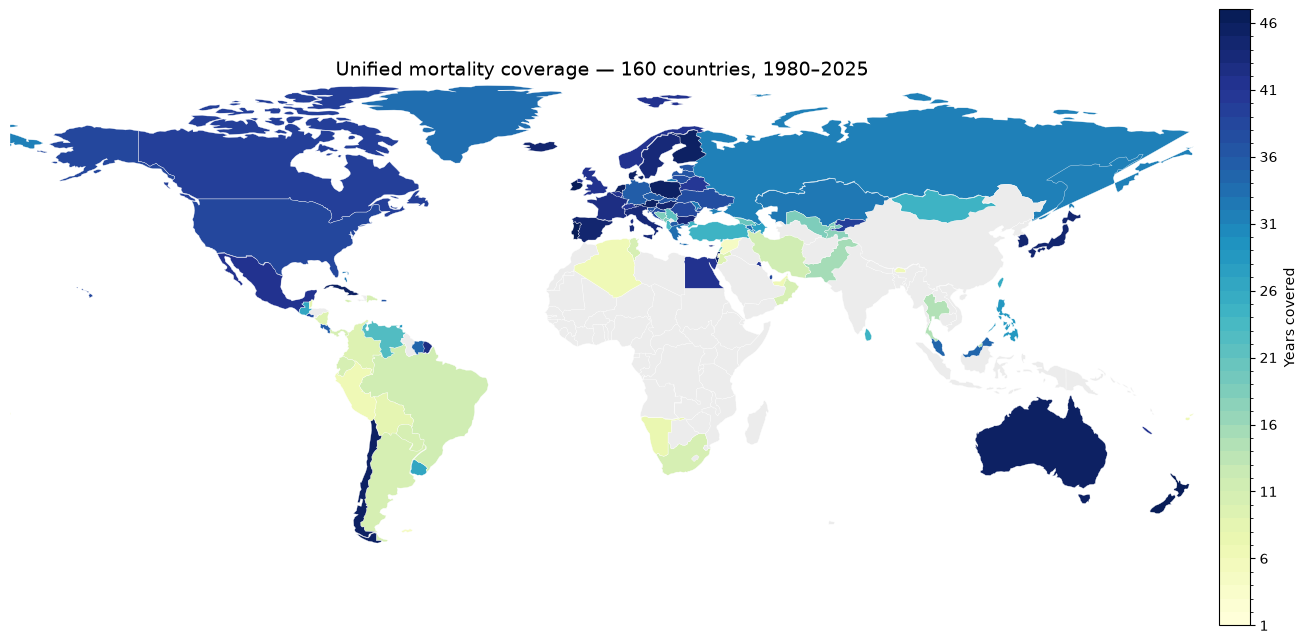

105 of 160 countries drawn; 55 absent from the 110m basemap:
ABW, AIA, ALA, AND, ASM, ATG, BHR, BLM, BMU, BRB, COK, CPV, CUW, CYM, DMA, FRO, GGY, GIB, GLP, GUF, GUM, HKG, IMN, JEY, KNA, KOS, LCA, LIE, MAC, MAF, MCO, MDV, MLT, MSR, MTQ, MUS, MYT, NFK, NIU, PYF, REU, SGP, SHN, SMR, SPM, SYC, TCA, TKL, TON, TRA, VCT, VGB, VIR, WLF, WSM


In [5]:
import json
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

# world-atlas country ids are M49 numeric codes; map them to ISO3 (Kosovo has no ISO3).
M49_TO_ISO3 = {
    "004": "AFG", "008": "ALB", "010": "ATA", "012": "DZA", "024": "AGO", "031": "AZE",
    "032": "ARG", "036": "AUS", "040": "AUT", "044": "BHS", "050": "BGD", "051": "ARM",
    "056": "BEL", "064": "BTN", "068": "BOL", "070": "BIH", "072": "BWA", "076": "BRA",
    "084": "BLZ", "090": "SLB", "096": "BRN", "100": "BGR", "104": "MMR", "108": "BDI",
    "112": "BLR", "116": "KHM", "120": "CMR", "124": "CAN", "140": "CAF", "144": "LKA",
    "148": "TCD", "152": "CHL", "156": "CHN", "158": "TWN", "170": "COL", "178": "COG",
    "180": "COD", "188": "CRI", "191": "HRV", "192": "CUB", "196": "CYP", "203": "CZE",
    "204": "BEN", "208": "DNK", "214": "DOM", "218": "ECU", "222": "SLV", "226": "GNQ",
    "231": "ETH", "232": "ERI", "233": "EST", "238": "FLK", "242": "FJI", "246": "FIN",
    "250": "FRA", "260": "ATF", "262": "DJI", "266": "GAB", "268": "GEO", "270": "GMB",
    "275": "PSE", "276": "DEU", "288": "GHA", "300": "GRC", "304": "GRL", "320": "GTM",
    "324": "GIN", "328": "GUY", "332": "HTI", "340": "HND", "348": "HUN", "352": "ISL",
    "356": "IND", "360": "IDN", "364": "IRN", "368": "IRQ", "372": "IRL", "376": "ISR",
    "380": "ITA", "384": "CIV", "388": "JAM", "392": "JPN", "398": "KAZ", "400": "JOR",
    "404": "KEN", "408": "PRK", "410": "KOR", "414": "KWT", "417": "KGZ", "418": "LAO",
    "422": "LBN", "426": "LSO", "428": "LVA", "430": "LBR", "434": "LBY", "440": "LTU",
    "442": "LUX", "450": "MDG", "454": "MWI", "458": "MYS", "466": "MLI", "478": "MRT",
    "484": "MEX", "496": "MNG", "498": "MDA", "499": "MNE", "504": "MAR", "508": "MOZ",
    "512": "OMN", "516": "NAM", "524": "NPL", "528": "NLD", "540": "NCL", "548": "VUT",
    "554": "NZL", "558": "NIC", "562": "NER", "566": "NGA", "578": "NOR", "586": "PAK",
    "591": "PAN", "598": "PNG", "600": "PRY", "604": "PER", "608": "PHL", "616": "POL",
    "620": "PRT", "624": "GNB", "626": "TLS", "630": "PRI", "634": "QAT", "642": "ROU",
    "643": "RUS", "646": "RWA", "682": "SAU", "686": "SEN", "688": "SRB", "694": "SLE",
    "703": "SVK", "704": "VNM", "705": "SVN", "706": "SOM", "710": "ZAF", "716": "ZWE",
    "724": "ESP", "728": "SSD", "729": "SDN", "732": "ESH", "740": "SUR", "748": "SWZ",
    "752": "SWE", "756": "CHE", "760": "SYR", "762": "TJK", "764": "THA", "768": "TGO",
    "780": "TTO", "784": "ARE", "788": "TUN", "792": "TUR", "795": "TKM", "800": "UGA",
    "804": "UKR", "807": "MKD", "818": "EGY", "826": "GBR", "834": "TZA", "840": "USA",
    "854": "BFA", "858": "URY", "860": "UZB", "862": "VEN", "887": "YEM", "894": "ZMB",
}


def _load_topojson():
    for p in [REPO_ROOT / "node_modules/world-atlas/countries-110m.json",
              REPO_ROOT / "data/countries-110m.json"]:
        if p.exists():
            return json.load(open(p))
    raise FileNotFoundError("world-atlas countries-110m.json not found")


def _country_rings(topo):
    """Decode TopoJSON country outlines to lon/lat rings, split at the antimeridian."""
    sx, sy = topo["transform"]["scale"]
    tx, ty = topo["transform"]["translate"]
    arcs = []
    for arc in topo["arcs"]:
        x = y = 0
        pts = []
        for dx, dy in arc:
            x += dx
            y += dy
            pts.append((x * sx + tx, y * sy + ty))
        arcs.append(pts)

    def ring(arc_ids):
        coords = []
        for idx in arc_ids:
            seg = arcs[idx] if idx >= 0 else arcs[~idx][::-1]
            coords.extend(seg if not coords else seg[1:])
        return coords

    def split(r):
        parts, cur = [], [r[0]]
        for p in r[1:]:
            if abs(p[0] - cur[-1][0]) > 180:   # antimeridian jump -> start a new sub-path
                parts.append(cur)
                cur = [p]
            else:
                cur.append(p)
        parts.append(cur)
        return [pp for pp in parts if len(pp) >= 3]

    feats = {}
    for g in topo["objects"]["countries"]["geometries"]:
        polys = [g["arcs"]] if g["type"] == "Polygon" else g["arcs"] if g["type"] == "MultiPolygon" else []
        rings = [rr for poly in polys for rr in split(ring(poly[0]))]
        feats[g.get("id")] = rings
    return feats


# years covered per base country
years_by_country = (mortality.assign(country=mortality["iso3"].str.split("-").str[0])
                             .groupby("country")["year"].nunique().to_dict())

topo = _load_topojson()
rings_by_id = _country_rings(topo)

vmax = max(years_by_country.values())
bounds = list(range(1, vmax + 2))
cmap = plt.get_cmap("YlGnBu")
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(16, 8))
plotted = set()
for m49, rings in rings_by_id.items():
    iso3 = M49_TO_ISO3.get(m49)
    n = years_by_country.get(iso3)
    color = cmap(norm(n)) if n else "#ececec"
    if n:
        plotted.add(iso3)
    if rings:
        ax.add_collection(PolyCollection(rings, facecolor=color, edgecolor="white", linewidth=0.25))

ax.set_xlim(-180, 180)
ax.set_ylim(-58, 84)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"Unified mortality coverage — {len(years_by_country)} countries, "
             f"{mortality['year'].min()}–{mortality['year'].max()}", fontsize=14)
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                    fraction=0.025, pad=0.02, label="Years covered")
plt.show()

unplotted = sorted(set(years_by_country) - plotted)
print(f"{len(plotted)} of {len(years_by_country)} countries drawn; "
      f"{len(unplotted)} absent from the 110m basemap:")
print(", ".join(unplotted))

## Per-country seasonal curve shapes

For every country in the unified `mortality` table, fold whatever cadence it won (week/month/quarter) down to a single 12-point monthly curve, same method as `seasonality_exploration.ipynb`: normalise each complete calendar year to mean 1, average across non-COVID years (2020–2022 excluded so the pandemic's mortality waves don't get baked into a "typical" shape), apply light circular smoothing, renormalise to mean 1. Weekly rows are mapped to a calendar month via the ISO week's Thursday before aggregating, so STMF's weekly series fold down to the same grid as the monthly/quarterly sources. Sub-country regions (`GBR-ENW/SCO/NIR`) are grouped back to their base country first.

Two shape metrics summarise each curve:
- **`cov_pct`** — RMS deviation from 1, as a percentage. Seasonal amplitude, independent of timing.
- **`winter_amp`** — signed projection onto a January-peaked cosine. Positive = peak aligns with the northern winter; negative = peak aligns with the northern summer (i.e. southern-hemisphere winter).

A country only gets a curve if it has at least one complete non-COVID calendar year and at least 10k deaths/year.

In [6]:
import sys

sys.path.insert(0, str(REPO_ROOT / "notebooks" / "lib"))
from seasonality_curve import country_curve, cov_pct, winter_amp  # noqa: E402

# country_curve / cov_pct / winter_amp (and the week/quarter folding + COVID exclusion)
# now live in notebooks/lib/seasonality_curve.py so the sub-national build
# (notebooks/data/build-subnational.ipynb) folds curves with the identical method.

mortality["country"] = mortality["iso3"].str.split("-").str[0]

country_curves = {
    country: r
    for country, rows in mortality.groupby("country")
    if (r := country_curve(rows)) is not None
}

curve_shapes = pd.DataFrame([
    {"iso3": c, "n_years": r["n_years"], "annual_deaths": round(r["annual"]),
     "cov_pct": round(cov_pct(r["curve"]), 2), "winter_amp": round(winter_amp(r["curve"]), 3),
     "curve": r["curve"]}
    for c, r in country_curves.items()
]).sort_values("cov_pct", ascending=False).reset_index(drop=True)

print(f"{len(curve_shapes)} / {mortality['country'].nunique()} countries have a usable seasonal curve "
      f"(>=1 complete non-COVID calendar year, >=10k deaths/yr)")
curve_shapes.drop(columns="curve").head(15)

89 / 160 countries have a usable seasonal curve (>=1 complete non-COVID calendar year, >=10k deaths/yr)


,iso3,n_years,annual_deaths,cov_pct,winter_amp
0,ARM,28,25731,12.95,0.138
1,URY,22,31138,12.56,-0.168
2,PRT,42,104005,11.32,0.148
3,TUN,7,73369,11.28,0.134
4,ALB,20,19093,10.67,0.128
5,MDA,28,41171,9.65,0.130
6,SYR,4,51278,9.41,0.117
7,PSE,2,12449,9.27,0.121
8,NZL,41,28490,9.16,-0.125
9,ISR,41,36606,9.15,0.123


## Harmonic curve experiment — validation only

The validation below is the decision record for the production method now used by `country_curves` above: pooled order-4 Fourier regression with COVID years excluded. It converts count observations to daily mortality intensity and runs forward validation against each country's latest complete year. The benchmark tables remain isolated from export; only the separately reviewed production implementation in `pipeline/curve.py` feeds the export cells.

A harmonic curve uses annual sine/cosine pairs. Complete weekly sources retain 52/53 observations per year; other sources keep their finest qualifying cadence after count exposure adjustment. The latest complete year is held out, and every earlier qualifying year predicts it. The continuous harmonic is evaluated at each observation's day-of-year phase and normalized to annual integral mean 1. Month-centre samples exist only for diagnostic comparisons with the former monthly contract. The benchmark compares pooled fitting, an equal mean of annual fits, a robust five-year EWMA, and a damped dynamic coefficient state, then records the approved pooled order-4 choice and the order-5 overfit diagnostic.

In [ ]:
import numpy as np

from harmonic_seasonality import (
    MONTH_PHASES,
    circular_three_point,
    compare_harmonic_strategies,
    count_year_vectors,
    country_year_vectors,
    evaluate_harmonic,
    fit_harmonic_observations,
    monthly_values,
    summarize_method_pair_by_group,
    summarize_strategies_by_latitude,
    validate_country_groups,
    weekly_count_year_vectors,
    weekly_rate_year_vectors,
)

# This is a notebook-only result. In particular, do not assign it to
# Benchmark variables stay distinct from the production `country_curves` export.
# until the gate below passes and the result is explicitly approved.
harmonic_validation = validate_country_groups(mortality.groupby("country"))
selected_harmonic_order = harmonic_validation["selected_order"]

order_comparison = pd.DataFrame([
    {
        "order": order,
        "baseline median RMSE": summary["baseline_median_rmse"],
        "harmonic continuous median RMSE": summary["harmonic_median_rmse"],
        "harmonic monthly-step median RMSE": summary["harmonic_monthly_step_median_rmse"],
        "baseline P90 RMSE": summary["baseline_p90_rmse"],
        "harmonic continuous P90 RMSE": summary["harmonic_p90_rmse"],
    }
    for order, summary in harmonic_validation["summaries"].items()
]).sort_values("order")

selected_rows = harmonic_validation["orders"][selected_harmonic_order]
harmonic_country_summary = pd.DataFrame([
    {
        "iso3": row["country"],
        "cadence": row["cadence"],
        "n_years": row["n_years"],
        "train_through": row["train_through"],
        "target_year": row["target_year"],
        "baseline_rmse": row["baseline"]["rmse"],
        "harmonic_continuous_rmse": row["harmonic"]["rmse"],
        "harmonic_monthly_step_rmse": row["harmonic"]["monthly_step_rmse"],
        "rmse_delta": row["harmonic"]["rmse"] - row["baseline"]["rmse"],
    }
    for row in selected_rows
]).sort_values("rmse_delta", ascending=False).reset_index(drop=True)

print(f"Harmonic validation cohort: {len(harmonic_validation['countries'])} countries")
print(f"Requested harmonic order: {selected_harmonic_order}")
print(f"Original lowest-within-1% rule would select: {harmonic_validation['rule_selected_order']}")
print(f"Promotion gate: {'PASS' if harmonic_validation['pass'] else 'FAIL — do not port'}")
print(order_comparison.to_string(index=False))
print(pd.DataFrame([harmonic_validation["gate"]]).T.rename(columns={0: "pass"}).to_string())
print(pd.DataFrame(harmonic_validation["cadence_cohorts"]).T.to_string())
print(pd.DataFrame(harmonic_validation["latest_year_accuracy"]).T.to_string())
print("Largest latest-year prediction regressions for the selected order:")
harmonic_country_summary.head(12)

In [ ]:
# Repeat the identical latest-year test for measured subnational series.
# This reads raw cached sources but does not invoke or modify the production builder.
from collections import Counter as HarmonicCounter
from collections import defaultdict as harmonic_defaultdict

from pipeline.cache import cache_dir as subnational_cache_dir
from pipeline.curve import COVID_YEARS
from pipeline.registry import MODULES as SUBNATIONAL_MODULES
from pipeline.registry import REGISTRY as SUBNATIONAL_REGISTRY

strategy_labels = {
    "circular_3_point": "circular 3-point reference",
    "pooled": "pooled harmonic",
    "annual_mean": "mean annual harmonics",
    "robust_ewma": "robust EWMA harmonics",
    "dynamic_state": "dynamic-state harmonics",
}

def build_regional_harmonic_vectors(excluded_years):
    result = {}
    eligible_by_source = HarmonicCounter()
    for source in SUBNATIONAL_REGISTRY:
        if not source.enabled:
            continue
        records_by_region = harmonic_defaultdict(list)
        for record in SUBNATIONAL_MODULES[source.key].load(subnational_cache_dir(REPO_ROOT)):
            region_key = record.get("iso_region") or record.get("region_key")
            records_by_region[region_key].append(record)
        for region_key, records in records_by_region.items():
            frame = pd.DataFrame(records)
            if source.cadence == "rate":
                vectors = weekly_rate_year_vectors(frame.itertuples(), excluded_years)
            else:
                vectors = weekly_count_year_vectors(frame.itertuples(), excluded_years)
                if len(vectors) < 2:
                    vectors = count_year_vectors(frame.itertuples(), excluded_years)
            if len(vectors) < 2:
                continue
            if source.cadence != "rate" and np.mean([v.annual_deaths for v in vectors]) < source.min_annual:
                continue
            result[f"{source.key}:{region_key}"] = vectors
            eligible_by_source[source.key] += 1
    return result, eligible_by_source

regional_harmonic_vectors, eligible_regions_by_source = build_regional_harmonic_vectors(
    COVID_YEARS
)

regional_strategy_validation = compare_harmonic_strategies(
    regional_harmonic_vectors, order=selected_harmonic_order
)
regional_circular_rmse = regional_strategy_validation["summaries"]["circular_3_point"]["median_rmse"]
regional_strategy_comparison = pd.DataFrame([
    {
        "method": strategy_labels[method],
        "regions": summary["countries"],
        "median RMSE": summary["median_rmse"],
        "change vs circular (%)": 100 * (summary["median_rmse"] / regional_circular_rmse - 1),
        "P90 RMSE": summary["p90_rmse"],
        "monthly-step median RMSE": summary["monthly_step_median_rmse"],
        "amplitude error (pp)": summary["median_amplitude_error"],
        "peak error (months)": summary["median_peak_distance"],
        "median paired ΔRMSE": summary["median_paired_delta"],
        "region wins vs circular": summary["wins_vs_circular"],
    }
    for method, summary in regional_strategy_validation["summaries"].items()
]).sort_values("median RMSE").reset_index(drop=True)
regional_cadence_strategy_comparison = pd.DataFrame([
    {"method": strategy_labels[method], "cadence": cadence, **summary}
    for method, cohorts in regional_strategy_validation["cadence_summaries"].items()
    for cadence, summary in cohorts.items()
]).sort_values(["cadence", "median_rmse"])
print(f"Eligible measured regions: {len(regional_harmonic_vectors)} — {dict(eligible_regions_by_source)}")
print(f"Lowest complete-cohort median RMSE: {strategy_labels[regional_strategy_validation['lowest_median_method']]}")
print(f"Invalid candidate fits: {len(regional_strategy_validation['failures'])}")
print(regional_strategy_comparison.to_string(index=False))
print("\nRegional cadence cohorts:")
regional_cadence_strategy_comparison


In [ ]:
# Hold order fixed at 3 and change only how historical years are combined.
harmonic_strategy_validation = compare_harmonic_strategies(
    harmonic_validation["countries"], order=selected_harmonic_order
)
strategy_labels = {
    "circular_3_point": "circular 3-point reference",
    "pooled": "pooled harmonic",
    "annual_mean": "mean annual harmonics",
    "robust_ewma": "robust EWMA harmonics",
    "dynamic_state": "dynamic-state harmonics",
}
circular_rmse = harmonic_strategy_validation["summaries"]["circular_3_point"]["median_rmse"]
strategy_comparison = pd.DataFrame([
    {
        "method": strategy_labels[method],
        "countries": summary["countries"],
        "median RMSE": summary["median_rmse"],
        "change vs circular (%)": 100 * (summary["median_rmse"] / circular_rmse - 1),
        "P90 RMSE": summary["p90_rmse"],
        "monthly-step median RMSE": summary["monthly_step_median_rmse"],
        "amplitude error (pp)": summary["median_amplitude_error"],
        "peak error (months)": summary["median_peak_distance"],
        "median paired ΔRMSE": summary["median_paired_delta"],
        "country wins vs circular": summary["wins_vs_circular"],
    }
    for method, summary in harmonic_strategy_validation["summaries"].items()
]).sort_values("median RMSE").reset_index(drop=True)
cadence_strategy_comparison = pd.DataFrame([
    {
        "method": strategy_labels[method],
        "cadence": cadence,
        **summary,
    }
    for method, cohorts in harmonic_strategy_validation["cadence_summaries"].items()
    for cadence, summary in cohorts.items()
]).sort_values(["cadence", "median_rmse"])
print(f"Fixed settings: {harmonic_strategy_validation['settings']}")
print(f"Lowest complete-cohort median RMSE: {strategy_labels[harmonic_strategy_validation['lowest_median_method']]}")
print(f"Invalid candidate fits: {len(harmonic_strategy_validation['failures'])}")
print(strategy_comparison.to_string(index=False))
print("\nCadence cohorts:")
cadence_strategy_comparison


In [ ]:
# Four contrastive examples: a weekly temperate series, a long monthly record,
# a southern-hemisphere curve, and a mixed-cadence country. Missing examples
# are skipped so the cell remains robust if an upstream source changes.
examples = [iso3 for iso3 in ("CHE", "PRT", "ARG", "AUS") if iso3 in harmonic_validation["countries"]]
fig, axes = plt.subplots(1, len(examples), figsize=(4.4 * len(examples), 3.5), sharey=True)
axes = np.atleast_1d(axes)
months = np.arange(12)
for ax, iso3 in zip(axes, examples, strict=False):
    years = harmonic_validation["countries"][iso3]
    raw = np.mean([monthly_values(year) for year in years], axis=0)
    baseline = circular_three_point(raw)
    _, harmonic_coefficients = fit_harmonic_observations(
        np.concatenate([year.phases for year in years]),
        np.concatenate([year.values for year in years]),
        selected_harmonic_order,
    )
    dense_phase = np.linspace(0, 1, 366, endpoint=False)
    dense_harmonic = evaluate_harmonic(harmonic_coefficients, dense_phase)
    for year in years:
        ax.plot(year.phases * 12 - 0.5, year.values, color="#b8b8b8", lw=0.7, alpha=0.35)
    month_x = MONTH_PHASES * 12 - 0.5
    ax.plot(month_x, raw, "o", color="#222", ms=3.5, label="daily-rate month mean")
    ax.plot(month_x, baseline, color="#4e79a7", lw=2, label="circular 3-point")
    ax.plot(dense_phase * 12 - 0.5, dense_harmonic, color="#e15759", lw=2, label=f"continuous harmonic order {selected_harmonic_order}")
    ax.axhline(1, color="#ddd", lw=0.8, zorder=0)
    ax.set_title(f"{iso3} — {years[0].cadence}")
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND"), fontsize=8)
axes[0].set_ylabel("daily mortality intensity / annual mean")
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Raw complete years, current smoother, and harmonic candidate", y=1.03)
fig.tight_layout()
plt.show()

# These experiment variables are deliberately distinct from `country_curves`.
# The production export section below must continue to consume the baseline.

### Which harmonic strategy works at different latitudes?

Stratify the same latest-year holdout errors by absolute country-centroid latitude. The bands retain the established tropical boundary, then separate subtropical, middle-latitude, and high-latitude countries while keeping at least 15 measured countries in every band. The paired delta is each method's RMSE minus circular smoothing's RMSE for the same country; negative is better.

In [ ]:
import subprocess

_harmonic_latitude_script = '''
import("d3").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const out = {};
  for (const feature of topojson.feature(topo, topo.objects.countries).features) {
    if (feature.id != null && Number.isFinite(Number(feature.id))) {
      out[feature.id] = d3geo.geoCentroid(feature)[1];
    }
  }
  console.log(JSON.stringify(out));
});
'''
latitude_process = subprocess.run(
    ["node", "-e", _harmonic_latitude_script],
    capture_output=True,
    text=True,
    check=True,
    cwd=REPO_ROOT,
)
lat_by_m49 = json.loads(latitude_process.stdout)
lat_by_iso3 = {M49_TO_ISO3[m49]: lat for m49, lat in lat_by_m49.items() if m49 in M49_TO_ISO3}

HARMONIC_LATITUDE_BANDS = [
    ("Tropical 0–23.5°", 0, 23.5),
    ("Subtropical 23.5–35°", 23.5, 35),
    ("Middle latitude 35–50°", 35, 50),
    ("High latitude 50°+", 50, 91),
]
latitude_strategy_rows = summarize_strategies_by_latitude(
    harmonic_strategy_validation["rows"],
    lat_by_iso3,
    HARMONIC_LATITUDE_BANDS,
)
latitude_strategy_comparison = pd.DataFrame(latitude_strategy_rows)
latitude_strategy_comparison["method"] = latitude_strategy_comparison["method"].map(strategy_labels)
latitude_strategy_comparison["band"] = pd.Categorical(
    latitude_strategy_comparison["band"],
    categories=[band[0] for band in HARMONIC_LATITUDE_BANDS],
    ordered=True,
)
latitude_strategy_comparison = latitude_strategy_comparison.sort_values(
    ["band", "median_paired_delta"]
).reset_index(drop=True)
latitude_winners = (
    latitude_strategy_comparison.loc[
        latitude_strategy_comparison.groupby("band", observed=True)["median_paired_delta"].idxmin(),
        ["band", "method", "countries", "weekly", "monthly", "median_rmse", "median_paired_delta", "wins_vs_circular"],
    ]
    .sort_values("band")
    .reset_index(drop=True)
)
latitude_country_codes = {row["country"] for row in harmonic_strategy_validation["rows"]["circular_3_point"]}
print(f"Latitude coverage: {len(latitude_country_codes & set(lat_by_iso3))}/{len(latitude_country_codes)} countries")
print("Best paired latest-year method in each latitude band:")
print(latitude_winners.to_string(index=False))
latitude_strategy_comparison[[
    "band", "method", "countries", "weekly", "monthly",
    "median_rmse", "p90_rmse", "median_paired_delta", "wins_vs_circular",
]]


### Order-4 benchmark: pooled versus robust EWMA

This requested benchmark compares only the two implementation candidates: one order-4 harmonic fitted to all historical observations (**pooled**) and independently fitted annual order-4 coefficients combined with a robust five-year exponentially weighted average (**robust EWMA**). Each geography's latest complete non-COVID year remains untouched until scoring, and the continuous curve is evaluated at that year's weekly or monthly observation phases. Results are shown overall and by Köppen–Geiger climate family and absolute-latitude band, separately for national and measured regional series. `paired ΔRMSE` is robust EWMA minus pooled for the same geography, so negative favours robust EWMA. This cell remains validation-only and cannot feed an export.

In [ ]:
from pipeline.geo import load_iso_geo

ORDER_4 = 4
order4_national = compare_harmonic_strategies(
    harmonic_validation["countries"], order=ORDER_4
)
order4_regional = compare_harmonic_strategies(
    regional_harmonic_vectors, order=ORDER_4
)

# National climate labels are population-weighted dominant Köppen families.
seasonality_proxies = json.loads(
    (REPO_ROOT / "data" / "seasonality-proxies.json").read_text()
)["byM49"]
national_climate = {
    M49_TO_ISO3[m49.zfill(3)]: proxy["kgFamily"]
    for m49, proxy in seasonality_proxies.items()
    if m49.zfill(3) in M49_TO_ISO3 and proxy.get("kgFamily")
}
climate_names = {
    "A": "A — tropical",
    "B": "B — arid",
    "C": "C — temperate",
    "D": "D — continental/cold",
    "E": "E — polar",
}
national_climate = {
    entity: climate_names[family] for entity, family in national_climate.items()
}

# Regional labels use each admin-1 centroid's own sampled climate family.
subnational_metadata = json.loads(
    (REPO_ROOT / "data" / "seasonality-subnational.json").read_text()
)["regions"]
measured_region_by_iso = {
    row["isoRegion"]: row
    for row in subnational_metadata
    if row.get("isoRegion") and row.get("measurement") != "climate-modeled"
}
regional_climate = {
    entity: climate_names[measured_region_by_iso[iso_region]["kgFamily"]]
    for entity in regional_harmonic_vectors
    for iso_region in [entity.split(":", 1)[1]]
    if iso_region in measured_region_by_iso
    and measured_region_by_iso[iso_region].get("kgFamily")
}

def latitude_cohorts(latitude_by_entity):
    return {
        entity: next(
            name
            for name, lower, upper in HARMONIC_LATITUDE_BANDS
            if lower <= abs(latitude) < upper
        )
        for entity, latitude in latitude_by_entity.items()
        if abs(latitude) < 91
    }

national_latitude = latitude_cohorts(lat_by_iso3)
iso_geo = load_iso_geo(REPO_ROOT)
regional_latitudes = {
    entity: iso_geo[iso_region]["latitude"]
    for entity in regional_harmonic_vectors
    for iso_region in [entity.split(":", 1)[1]]
    if iso_region in iso_geo and iso_geo[iso_region].get("latitude") is not None
}
partido_latitudes = json.loads(
    (REPO_ROOT / "data" / "argentina-partido-latitudes.json").read_text()
)["latitudes"]
for entity in regional_harmonic_vectors:
    region_key = entity.split(":", 1)[1]
    if region_key in partido_latitudes:
        regional_latitudes[entity] = partido_latitudes[region_key]
regional_latitude = latitude_cohorts(regional_latitudes)

def pair_table(scope, dimension, comparison, groups=None, group_order=None):
    rows = summarize_method_pair_by_group(
        comparison["rows"], groups, group_order=group_order
    )
    return [{"scope": scope, "dimension": dimension, **row} for row in rows]

climate_order = list(climate_names.values())
latitude_order = [band[0] for band in HARMONIC_LATITUDE_BANDS]
order4_benchmark_rows = [
    *pair_table("National", "Overall", order4_national),
    *pair_table("Regional", "Overall", order4_regional),
    *pair_table("National", "Climate", order4_national, national_climate, climate_order),
    *pair_table("Regional", "Climate", order4_regional, regional_climate, climate_order),
    *pair_table("National", "Latitude", order4_national, national_latitude, latitude_order),
    *pair_table("Regional", "Latitude", order4_regional, regional_latitude, latitude_order),
]
order4_benchmark = pd.DataFrame(order4_benchmark_rows)
order4_benchmark["winner"] = np.where(
    order4_benchmark["median_paired_delta"] < 0, "robust EWMA", "pooled"
)
order4_benchmark = order4_benchmark.rename(columns={
    "entities": "n",
    "first_median_rmse": "pooled median RMSE",
    "second_median_rmse": "robust median RMSE",
    "first_p90_rmse": "pooled P90 RMSE",
    "second_p90_rmse": "robust P90 RMSE",
    "median_paired_delta": "paired ΔRMSE (robust − pooled)",
    "second_method_wins": "robust wins",
})
print("Continuous order-4 latest-year benchmark; production remains unchanged.")
print(
    "Coverage — national climate/latitude: "
    f"{len(set(harmonic_validation['countries']) & set(national_climate))}/"
    f"{len(set(harmonic_validation['countries']) & set(national_latitude))}; "
    "regional climate/latitude: "
    f"{len(set(regional_harmonic_vectors) & set(regional_climate))}/"
    f"{len(set(regional_harmonic_vectors) & set(regional_latitude))}."
)
order4_benchmark[[
    "scope", "dimension", "group", "n", "weekly", "monthly",
    "pooled median RMSE", "robust median RMSE",
    "pooled P90 RMSE", "robust P90 RMSE",
    "paired ΔRMSE (robust − pooled)", "robust wins", "winner",
]]


### Decision benchmark: pooled order 4 versus robust EWMA order 3

The same-order table above isolates the effect of historical aggregation. For an implementation decision, compare each method in its strongest tested configuration instead: pooled order 4 retains the fourth harmonic from the full observation pool, while robust EWMA order 3 avoids fitting nine coefficients independently to each twelve-point monthly year. This is a comparison of complete model configurations, not a causal test of aggregation alone.

In [ ]:
selected_national_rows = {
    "pooled_order4": order4_national["rows"]["pooled"],
    "robust_ewma_order3": harmonic_strategy_validation["rows"]["robust_ewma"],
}
selected_regional_rows = {
    "pooled_order4": order4_regional["rows"]["pooled"],
    "robust_ewma_order3": regional_strategy_validation["rows"]["robust_ewma"],
}

def selected_config_table(scope, dimension, method_rows, groups=None, group_order=None):
    rows = summarize_method_pair_by_group(
        method_rows,
        groups,
        first_method="pooled_order4",
        second_method="robust_ewma_order3",
        group_order=group_order,
    )
    return [{"scope": scope, "dimension": dimension, **row} for row in rows]

selected_config_rows = [
    *selected_config_table("National", "Overall", selected_national_rows),
    *selected_config_table("Regional", "Overall", selected_regional_rows),
    *selected_config_table("National", "Climate", selected_national_rows, national_climate, climate_order),
    *selected_config_table("Regional", "Climate", selected_regional_rows, regional_climate, climate_order),
    *selected_config_table("National", "Latitude", selected_national_rows, national_latitude, latitude_order),
    *selected_config_table("Regional", "Latitude", selected_regional_rows, regional_latitude, latitude_order),
]
selected_config_benchmark = pd.DataFrame(selected_config_rows).rename(columns={
    "entities": "n",
    "first_median_rmse": "pooled order-4 median RMSE",
    "second_median_rmse": "robust order-3 median RMSE",
    "first_p90_rmse": "pooled order-4 P90 RMSE",
    "second_p90_rmse": "robust order-3 P90 RMSE",
    "median_paired_delta": "paired ΔRMSE (robust order 3 − pooled order 4)",
    "second_method_wins": "robust order-3 wins",
})
selected_config_benchmark["winner"] = np.where(
    selected_config_benchmark["paired ΔRMSE (robust order 3 − pooled order 4)"] < 0,
    "robust EWMA order 3",
    "pooled order 4",
)
selected_config_benchmark[[
    "scope", "dimension", "group", "n", "weekly", "monthly",
    "pooled order-4 median RMSE", "robust order-3 median RMSE",
    "pooled order-4 P90 RMSE", "robust order-3 P90 RMSE",
    "paired ΔRMSE (robust order 3 − pooled order 4)",
    "robust order-3 wins", "winner",
]]


### Is pooled order 5 useful, or overfit?

Compare pooled continuous orders 4 and 5 with COVID years excluded and identical latest-year holdouts. Weekly and monthly cohorts are evaluated separately because order 5's eleven coefficients are well supported by 52/53 weekly phases but nearly saturate the twelve distinct monthly phases. Promotion requires every curve to remain positive and valid, negative paired ΔRMSE, no P90 regression, and equal-or-better amplitude and peak error.

In [ ]:
order5_national = compare_harmonic_strategies(
    harmonic_validation["countries"], order=5
)
order5_regional = compare_harmonic_strategies(
    regional_harmonic_vectors, order=5
)

def pooled_order_diagnostic(scope, order4, order5):
    first = {row["country"]: row for row in order4["rows"]["pooled"]}
    second = {row["country"]: row for row in order5["rows"]["pooled"]}
    result = []
    cohorts = [
        ("Overall", sorted(first)),
        ("Weekly", sorted(entity for entity, row in first.items() if row["cadence"] == "week")),
        ("Monthly", sorted(entity for entity, row in first.items() if row["cadence"] == "month")),
    ]
    for cohort, expected in cohorts:
        common = [entity for entity in expected if entity in second]
        order4_rmse = np.array([first[entity]["rmse"] for entity in common])
        order5_rmse = np.array([second[entity]["rmse"] for entity in common])
        order4_amplitude = np.array([first[entity]["amplitude_error"] for entity in common])
        order5_amplitude = np.array([second[entity]["amplitude_error"] for entity in common])
        order4_peak = np.array([first[entity]["peak_distance"] for entity in common])
        order5_peak = np.array([second[entity]["peak_distance"] for entity in common])
        paired_delta = order5_rmse - order4_rmse
        row = {
            "scope": scope,
            "cohort": cohort,
            "expected": len(expected),
            "order-5 valid": len(common),
            "order-4 median RMSE": float(np.median(order4_rmse)),
            "order-5 median RMSE": float(np.median(order5_rmse)),
            "paired ΔRMSE (order 5 − order 4)": float(np.median(paired_delta)),
            "order-5 wins": int(np.sum(paired_delta < 0)),
            "order-4 P90 RMSE": float(np.percentile(order4_rmse, 90)),
            "order-5 P90 RMSE": float(np.percentile(order5_rmse, 90)),
            "order-4 amplitude error": float(np.median(order4_amplitude)),
            "order-5 amplitude error": float(np.median(order5_amplitude)),
            "order-4 peak error": float(np.median(order4_peak)),
            "order-5 peak error": float(np.median(order5_peak)),
        }
        row["order-5 passes"] = (
            row["order-5 valid"] == row["expected"]
            and row["paired ΔRMSE (order 5 − order 4)"] < 0
            and row["order-5 P90 RMSE"] <= row["order-4 P90 RMSE"]
            and row["order-5 amplitude error"] <= row["order-4 amplitude error"]
            and row["order-5 peak error"] <= row["order-4 peak error"]
        )
        result.append(row)
    return result

order5_diagnostic = pd.DataFrame([
    *pooled_order_diagnostic("National", order4_national, order5_national),
    *pooled_order_diagnostic("Regional", order4_regional, order5_regional),
])
order5_pooled_failures = {
    "national": [failure for failure in order5_national["failures"] if failure["method"] == "pooled"],
    "regional": [failure for failure in order5_regional["failures"] if failure["method"] == "pooled"],
}
print("Pooled order-5 candidate failures:", {scope: len(rows) for scope, rows in order5_pooled_failures.items()})
print("Strict order-5 promotion across every cadence cohort:", bool(order5_diagnostic["order-5 passes"].all()))
order5_diagnostic


### COVID-year sensitivity: exclude versus include

Test whether the selected configurations—pooled order 4 and robust EWMA order 3—can safely absorb 2020–2022. This is a paired sensitivity test: both variants predict exactly the same latest complete **non-COVID** target year for each geography. The inclusion variant may add COVID years only when they precede that target; years after the target remain unavailable, preventing future leakage. `paired ΔRMSE` is **include minus exclude** on the same geography, so negative means including COVID improved the latest-year prediction.

In [ ]:
national_targets = {
    row["country"]: row["target_year"]
    for row in order4_national["rows"]["pooled"]
}
regional_targets = {
    row["country"]: row["target_year"]
    for row in order4_regional["rows"]["pooled"]
}
national_vectors_including_covid = country_year_vectors(
    mortality.groupby("country"), excluded_years=frozenset()
)
regional_vectors_including_covid, _ = build_regional_harmonic_vectors(frozenset())
order4_national_including_covid = compare_harmonic_strategies(
    national_vectors_including_covid,
    order=ORDER_4,
    target_year_by_country=national_targets,
)
order4_regional_including_covid = compare_harmonic_strategies(
    regional_vectors_including_covid,
    order=ORDER_4,
    target_year_by_country=regional_targets,
)
order3_national_including_covid = compare_harmonic_strategies(
    national_vectors_including_covid,
    order=3,
    target_year_by_country=national_targets,
)
order3_regional_including_covid = compare_harmonic_strategies(
    regional_vectors_including_covid,
    order=3,
    target_year_by_country=regional_targets,
)
covid_national_excluded_rows = {
    "pooled_order4": order4_national["rows"]["pooled"],
    "robust_ewma_order3": harmonic_strategy_validation["rows"]["robust_ewma"],
}
covid_national_included_rows = {
    "pooled_order4": order4_national_including_covid["rows"]["pooled"],
    "robust_ewma_order3": order3_national_including_covid["rows"]["robust_ewma"],
}
covid_regional_excluded_rows = {
    "pooled_order4": order4_regional["rows"]["pooled"],
    "robust_ewma_order3": regional_strategy_validation["rows"]["robust_ewma"],
}
covid_regional_included_rows = {
    "pooled_order4": order4_regional_including_covid["rows"]["pooled"],
    "robust_ewma_order3": order3_regional_including_covid["rows"]["robust_ewma"],
}

def covid_sensitivity_table(
    scope, dimension, excluded, included, groups=None, group_order=None
):
    result = []
    for method in ("pooled_order4", "robust_ewma_order3"):
        rows = summarize_method_pair_by_group(
            {"exclude": excluded[method], "include": included[method]},
            groups,
            first_method="exclude",
            second_method="include",
            group_order=group_order,
        )
        result.extend(
            {"scope": scope, "dimension": dimension, "method": method, **row}
            for row in rows
        )
    return result

def covid_training_entities(vectors, targets):
    return {
        entity
        for entity, years in vectors.items()
        if entity in targets
        and any(year.year in COVID_YEARS and year.year < targets[entity] for year in years)
    }

national_covid_affected = covid_training_entities(
    national_vectors_including_covid, national_targets
)
regional_covid_affected = covid_training_entities(
    regional_vectors_including_covid, regional_targets
)
national_covid_overall = {entity: "COVID years available" for entity in national_covid_affected}
regional_covid_overall = {entity: "COVID years available" for entity in regional_covid_affected}
national_covid_climate = {entity: group for entity, group in national_climate.items() if entity in national_covid_affected}
regional_covid_climate = {entity: group for entity, group in regional_climate.items() if entity in regional_covid_affected}
national_covid_latitude = {entity: group for entity, group in national_latitude.items() if entity in national_covid_affected}
regional_covid_latitude = {entity: group for entity, group in regional_latitude.items() if entity in regional_covid_affected}

covid_sensitivity_rows = [
    *covid_sensitivity_table("National", "Overall", covid_national_excluded_rows, covid_national_included_rows, national_covid_overall),
    *covid_sensitivity_table("Regional", "Overall", covid_regional_excluded_rows, covid_regional_included_rows, regional_covid_overall),
    *covid_sensitivity_table("National", "Climate", covid_national_excluded_rows, covid_national_included_rows, national_covid_climate, climate_order),
    *covid_sensitivity_table("Regional", "Climate", covid_regional_excluded_rows, covid_regional_included_rows, regional_covid_climate, climate_order),
    *covid_sensitivity_table("National", "Latitude", covid_national_excluded_rows, covid_national_included_rows, national_covid_latitude, latitude_order),
    *covid_sensitivity_table("Regional", "Latitude", covid_regional_excluded_rows, covid_regional_included_rows, regional_covid_latitude, latitude_order),
]
covid_sensitivity = pd.DataFrame(covid_sensitivity_rows).rename(columns={
    "entities": "n",
    "first_median_rmse": "exclude median RMSE",
    "second_median_rmse": "include median RMSE",
    "first_p90_rmse": "exclude P90 RMSE",
    "second_p90_rmse": "include P90 RMSE",
    "median_paired_delta": "paired ΔRMSE (include − exclude)",
    "second_method_wins": "include wins",
})
covid_sensitivity["winner"] = np.where(
    covid_sensitivity["paired ΔRMSE (include − exclude)"] < 0,
    "include COVID",
    "exclude COVID",
)

def covid_training_coverage(vectors, targets):
    affected = covid_training_entities(vectors, targets)
    added_years = sum(
        year.year in COVID_YEARS and year.year < targets[entity]
        for entity in affected
        for year in vectors[entity]
    )
    return len(affected), added_years

print("COVID sensitivity for pooled order 4 and robust EWMA order 3; targets are held fixed and production remains unchanged.")
print("National affected geographies/added annual profiles:", covid_training_coverage(national_vectors_including_covid, national_targets))
print("Regional affected geographies/added annual profiles:", covid_training_coverage(regional_vectors_including_covid, regional_targets))
covid_sensitivity[[
    "scope", "dimension", "group", "method", "n", "weekly", "monthly",
    "exclude median RMSE", "include median RMSE",
    "exclude P90 RMSE", "include P90 RMSE",
    "paired ΔRMSE (include − exclude)", "include wins", "winner",
]]


### Amplitude choropleth

Same basemap and M49→ISO3 mapping as the coverage map above, this time coloured by each country's seasonal amplitude (`cov_pct`) instead of years of coverage. Grey means no usable curve (either absent from the unified table or it didn't clear the quality gate in the cell above).

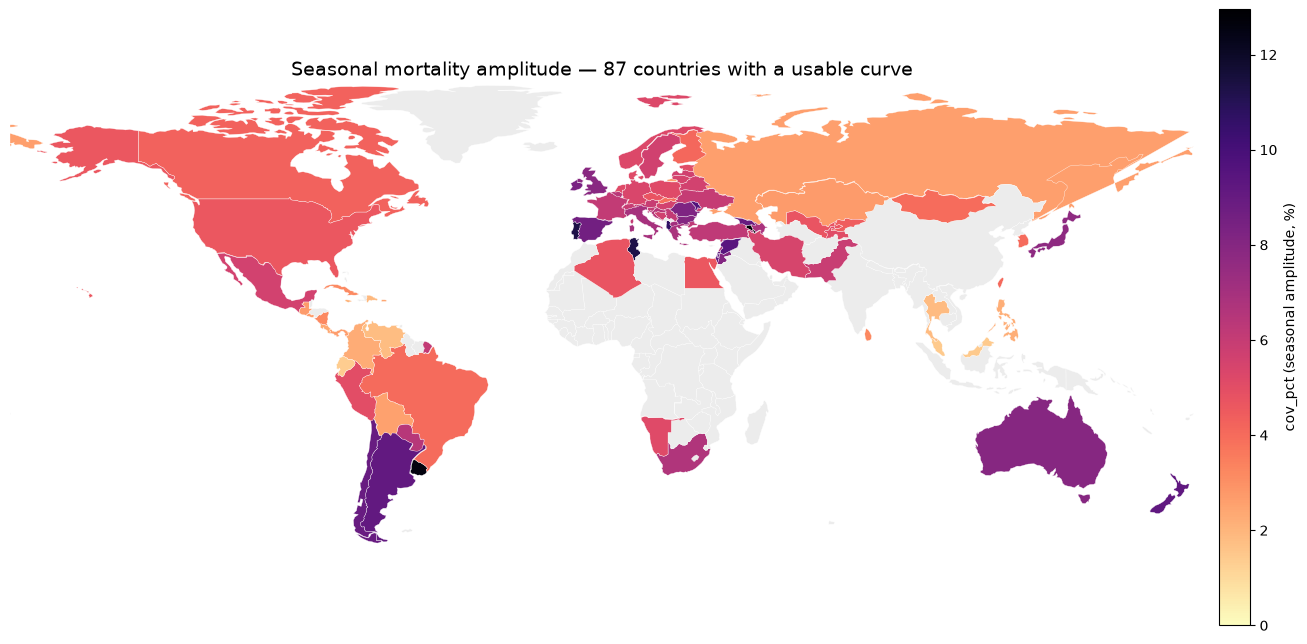

87 of 89 countries with a curve drawn; 2 absent from the 110m basemap:
HKG, SGP


In [7]:
cov_pct_by_iso3 = dict(zip(curve_shapes["iso3"], curve_shapes["cov_pct"], strict=False))

vmax = curve_shapes["cov_pct"].max()
cmap = plt.get_cmap("magma_r")
norm = plt.Normalize(vmin=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(16, 8))
plotted = set()
for m49, rings in rings_by_id.items():
    iso3 = M49_TO_ISO3.get(m49)
    amp = cov_pct_by_iso3.get(iso3)
    color = cmap(norm(amp)) if amp is not None else "#ececec"
    if amp is not None:
        plotted.add(iso3)
    if rings:
        ax.add_collection(PolyCollection(rings, facecolor=color, edgecolor="white", linewidth=0.25))

ax.set_xlim(-180, 180)
ax.set_ylim(-58, 84)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"Seasonal mortality amplitude — {len(plotted)} countries with a usable curve", fontsize=14)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax,
             fraction=0.025, pad=0.02, label="cov_pct (seasonal amplitude, %)")
plt.show()

unplotted = sorted(set(cov_pct_by_iso3) - plotted)
print(f"{len(plotted)} of {len(cov_pct_by_iso3)} countries with a curve drawn; "
      f"{len(unplotted)} absent from the 110m basemap:")
print(", ".join(unplotted))

### Does latitude predict amplitude?

Country centroid latitude comes from `d3.geoCentroid` on the same `world-atlas` topology the choropleth (and the front-end globe) uses. Correlate `|latitude|` against `cov_pct` to check whether amplitude actually scales with distance from the equator, the way the shipped fallback model (`scripts/build-seasonality.mjs`) assumes.

174 country centroids loaded from world-atlas
87 countries with both a curve and a centroid
corr(|lat|, cov_pct)    = +0.38
corr(lat (signed), cov_pct) = +0.03


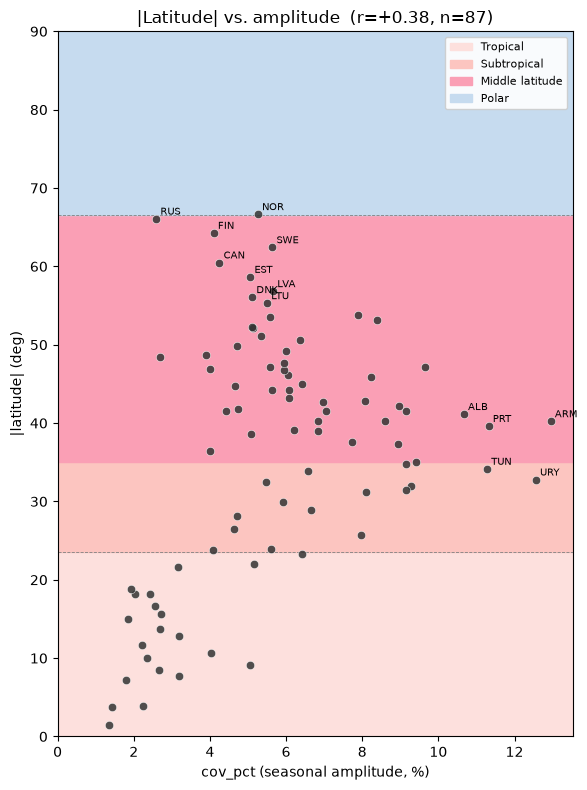

In [8]:
import subprocess

_node_script = '''
import("d3").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const features = topojson.feature(topo, topo.objects.countries).features;
  const out = {};
  for (const f of features) {
    if (f.id == null || !Number.isFinite(Number(f.id))) continue;
    out[f.id] = d3geo.geoCentroid(f)[1]; // latitude only
  }
  console.log(JSON.stringify(out));
});
'''
proc = subprocess.run(["node", "-e", _node_script], capture_output=True, text=True,
                       check=True, cwd=REPO_ROOT)
lat_by_m49 = json.loads(proc.stdout)  # keys are zero-padded M49 strings, matching M49_TO_ISO3
lat_by_iso3 = {M49_TO_ISO3[m49]: lat for m49, lat in lat_by_m49.items() if m49 in M49_TO_ISO3}
print(f"{len(lat_by_iso3)} country centroids loaded from world-atlas")

lat_amp = curve_shapes.assign(lat=curve_shapes["iso3"].map(lat_by_iso3)).dropna(subset=["lat"])
lat_amp["abs_lat"] = lat_amp["lat"].abs()

r_abs = lat_amp["abs_lat"].corr(lat_amp["cov_pct"])
r_signed = lat_amp["lat"].corr(lat_amp["cov_pct"])
print(f"{len(lat_amp)} countries with both a curve and a centroid")
print(f"corr(|lat|, cov_pct)    = {r_abs:+.2f}")
print(f"corr(lat (signed), cov_pct) = {r_signed:+.2f}")

# Standard climatic latitude bands (absolute degrees). "Temperate" is the 23.5-66.5
# umbrella that subtropical + middle-latitude nest inside, so it's drawn as a shared
# outline rather than its own fill to avoid double-shading the sub-bands.
ZONES = [
    ("Tropical", 0, 23.5, "#fde0dd"),
    ("Subtropical", 23.5, 35, "#fcc5c0"),
    ("Middle latitude", 35, 66.5, "#fa9fb5"),
    ("Polar", 66.5, 90, "#c6dbef"),
]

fig, ax = plt.subplots(figsize=(6, 8))
for name, lo, hi, color in ZONES:
    ax.axhspan(lo, hi, color=color, zorder=0, label=name)
ax.axhline(23.5, color="grey", linewidth=0.6, linestyle="--", zorder=1)
ax.axhline(66.5, color="grey", linewidth=0.6, linestyle="--", zorder=1)

ax.scatter(lat_amp["cov_pct"], lat_amp["abs_lat"], alpha=0.85, color="#333333",
           edgecolor="white", linewidth=0.4, zorder=2)
for _, r in lat_amp.iterrows():
    if r["cov_pct"] > 10 or r["abs_lat"] > 55:
        ax.annotate(r["iso3"], (r["cov_pct"], r["abs_lat"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", zorder=3)

ax.set_ylim(0, 90)
ax.set_xlim(left=0)
ax.set_ylabel("|latitude| (deg)")
ax.set_xlabel("cov_pct (seasonal amplitude, %)")
ax.set_title(f"|Latitude| vs. amplitude  (r={r_abs:+.2f}, n={len(lat_amp)})")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()

### Latitude vs. amplitude, split by hemisphere

The chart above collapses north and south into `|latitude|`, which hides any hemisphere asymmetry (different mix of countries, landmass, continentality at a given absolute latitude north vs. south). Split into two separate correlations/scatters — northern hemisphere (`lat > 0`) and southern hemisphere (`lat < 0`) — using signed latitude on the y-axis so each keeps its own sign.

Northern hemisphere: n=75, corr(lat, cov_pct) = +0.39
Southern hemisphere: n=12, corr(lat, cov_pct) = -0.85


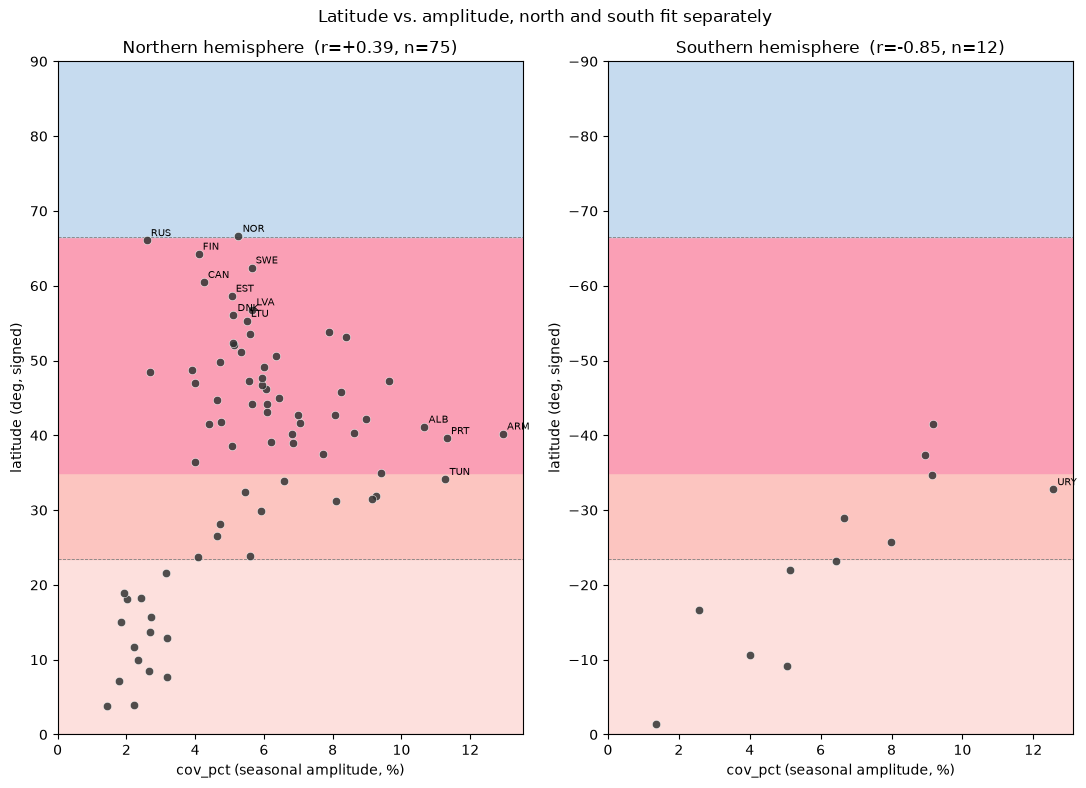

In [9]:
north = lat_amp[lat_amp["lat"] > 0]
south = lat_amp[lat_amp["lat"] < 0]

r_north = north["lat"].corr(north["cov_pct"])
r_south = south["lat"].corr(south["cov_pct"])
print(f"Northern hemisphere: n={len(north)}, corr(lat, cov_pct) = {r_north:+.2f}")
print(f"Southern hemisphere: n={len(south)}, corr(lat, cov_pct) = {r_south:+.2f}")

# Same climatic bands as above, mirrored to signed latitude (negative = south).
ZONES_SIGNED = [
    ("Tropical", -23.5, 23.5, "#fde0dd"),
    ("Subtropical (N)", 23.5, 35, "#fcc5c0"),
    ("Subtropical (S)", -35, -23.5, "#fcc5c0"),
    ("Middle latitude (N)", 35, 66.5, "#fa9fb5"),
    ("Middle latitude (S)", -66.5, -35, "#fa9fb5"),
    ("Polar (N)", 66.5, 90, "#c6dbef"),
    ("Polar (S)", -90, -66.5, "#c6dbef"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharey=False)

for ax, df, r, title in [(axes[0], north, r_north, "Northern hemisphere"),
                          (axes[1], south, r_south, "Southern hemisphere")]:
    for _name, lo, hi, color in ZONES_SIGNED:
        ax.axhspan(lo, hi, color=color, zorder=0)
    for boundary in (23.5, -23.5, 66.5, -66.5):
        ax.axhline(boundary, color="grey", linewidth=0.6, linestyle="--", zorder=1)
    ax.axhline(0, color="grey", linewidth=0.8, zorder=1)

    ax.scatter(df["cov_pct"], df["lat"], alpha=0.85, color="#333333",
               edgecolor="white", linewidth=0.4, zorder=2)
    for _, row in df.iterrows():
        if row["cov_pct"] > 10 or abs(row["lat"]) > 55:
            ax.annotate(row["iso3"], (row["cov_pct"], row["lat"]), fontsize=7,
                        xytext=(3, 3), textcoords="offset points", zorder=3)

    ax.set_xlim(left=0)
    ax.set_xlabel("cov_pct (seasonal amplitude, %)")
    ax.set_title(f"{title}  (r={r:+.2f}, n={len(df)})")

axes[0].set_ylim(0, 90)
axes[1].set_ylim(0, -90)
axes[0].set_ylabel("latitude (deg, signed)")
axes[1].set_ylabel("latitude (deg, signed)")
fig.suptitle("Latitude vs. amplitude, north and south fit separately")
fig.tight_layout()

### Quadratic fit: does a hump shape explain more than a straight line?

`r` only measures a *linear* relationship. The scatter earlier looked like a hump — rising from the equator, peaking somewhere in the 30-45° band, then falling off toward the poles — which a straight line can't capture well. Fit `cov_pct ~ |lat| + |lat|²` and compare its R² against the plain linear fit's r² to see how much of the extra shape a quadratic term picks up.

linear    R^2 = 0.143  (r = +0.38, r^2 = 0.143)
quadratic R^2 = 0.438
quadratic fit peaks at |lat| = 39.4 deg


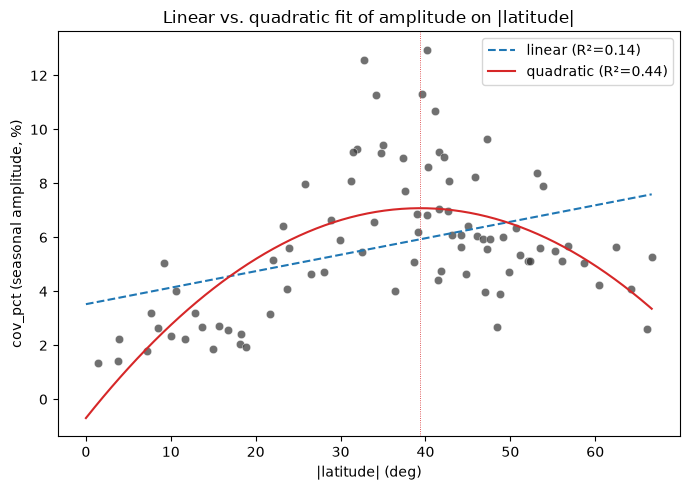

In [10]:
import numpy as np

x = lat_amp["abs_lat"].values
y = lat_amp["cov_pct"].values

# Linear fit, for comparison against the r already computed above.
lin_coef = np.polyfit(x, y, 1)
lin_pred = np.polyval(lin_coef, x)
r2_lin = 1 - np.sum((y - lin_pred) ** 2) / np.sum((y - y.mean()) ** 2)

# Quadratic fit: cov_pct ~ a*|lat|^2 + b*|lat| + c
quad_coef = np.polyfit(x, y, 2)
quad_pred = np.polyval(quad_coef, x)
r2_quad = 1 - np.sum((y - quad_pred) ** 2) / np.sum((y - y.mean()) ** 2)

peak_lat = -quad_coef[1] / (2 * quad_coef[0])  # vertex of a*x^2 + b*x + c
print(f"linear    R^2 = {r2_lin:.3f}  (r = {r_abs:+.2f}, r^2 = {r_abs**2:.3f})")
print(f"quadratic R^2 = {r2_quad:.3f}")
print(f"quadratic fit peaks at |lat| = {peak_lat:.1f} deg")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.7, color="#333333", edgecolor="white", linewidth=0.4, zorder=2)
lat_grid = np.linspace(0, x.max(), 200)
ax.plot(lat_grid, np.polyval(lin_coef, lat_grid), color="tab:blue", linestyle="--",
        label=f"linear (R²={r2_lin:.2f})")
ax.plot(lat_grid, np.polyval(quad_coef, lat_grid), color="tab:red",
        label=f"quadratic (R²={r2_quad:.2f})")
ax.axvline(peak_lat, color="tab:red", linewidth=0.6, linestyle=":")
ax.set_xlabel("|latitude| (deg)")
ax.set_ylabel("cov_pct (seasonal amplitude, %)")
ax.set_title("Linear vs. quadratic fit of amplitude on |latitude|")
ax.legend()
fig.tight_layout()

### Quadratic fit, split by hemisphere

Same quadratic fit as above, but on signed latitude and fit separately per hemisphere, with the same climate-zone shading used in the hemisphere-split `r` chart.

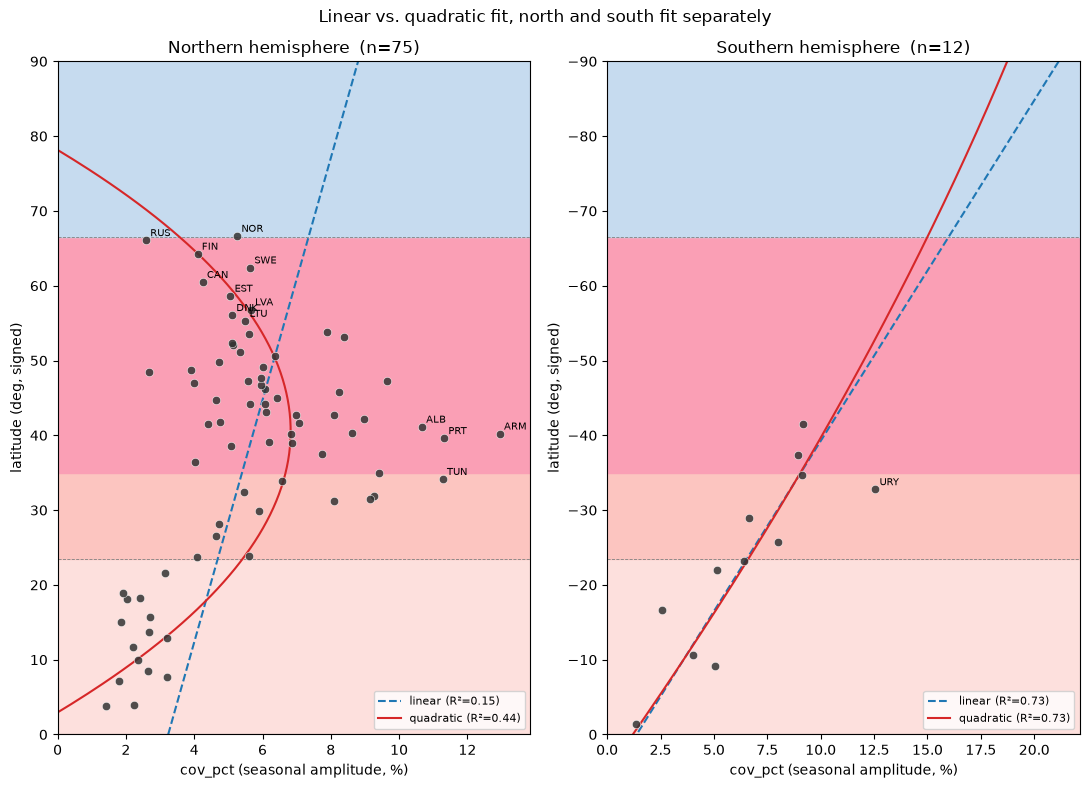

In [11]:
def fit_and_r2(lat_vals, amp_vals, degree):
    coef = np.polyfit(lat_vals, amp_vals, degree)
    pred = np.polyval(coef, lat_vals)
    r2 = 1 - np.sum((amp_vals - pred) ** 2) / np.sum((amp_vals - amp_vals.mean()) ** 2)
    return coef, r2


fig, axes = plt.subplots(1, 2, figsize=(11, 8))

for ax, df, title, lat_range in [
    (axes[0], north, "Northern hemisphere", np.linspace(0, 90, 200)),
    (axes[1], south, "Southern hemisphere", np.linspace(-90, 0, 200)),
]:
    for _name, lo, hi, color in ZONES_SIGNED:
        ax.axhspan(lo, hi, color=color, zorder=0)
    for boundary in (23.5, -23.5, 66.5, -66.5):
        ax.axhline(boundary, color="grey", linewidth=0.6, linestyle="--", zorder=1)
    ax.axhline(0, color="grey", linewidth=0.8, zorder=1)

    lat_vals = df["lat"].values
    amp_vals = df["cov_pct"].values
    lin_coef, r2_lin = fit_and_r2(lat_vals, amp_vals, 1)
    quad_coef, r2_quad = fit_and_r2(lat_vals, amp_vals, 2)

    ax.plot(np.polyval(lin_coef, lat_range), lat_range, color="tab:blue", linestyle="--",
            zorder=2, label=f"linear (R²={r2_lin:.2f})")
    ax.plot(np.polyval(quad_coef, lat_range), lat_range, color="tab:red",
            zorder=2, label=f"quadratic (R²={r2_quad:.2f})")

    ax.scatter(amp_vals, lat_vals, alpha=0.85, color="#333333",
               edgecolor="white", linewidth=0.4, zorder=3)
    for _, row in df.iterrows():
        if row["cov_pct"] > 10 or abs(row["lat"]) > 55:
            ax.annotate(row["iso3"], (row["cov_pct"], row["lat"]), fontsize=7,
                        xytext=(3, 3), textcoords="offset points", zorder=4)

    ax.set_xlim(left=0)
    ax.set_xlabel("cov_pct (seasonal amplitude, %)")
    ax.set_ylabel("latitude (deg, signed)")
    ax.set_title(f"{title}  (n={len(df)})")
    ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylim(0, 90)
axes[1].set_ylim(0, -90)
fig.suptitle("Linear vs. quadratic fit, north and south fit separately")
fig.tight_layout()

## Beyond latitude: GDP per capita and age structure

Latitude is a proxy for the real drivers of winter mortality — cold exposure, respiratory/cardiovascular strain, healthcare capacity, population age. Two more direct candidates, both available from the World Bank open API (same source `server.js` already uses for CDR/population):

- **`NY.GDP.PCAP.CD`** — GDP per capita (current USD). Proxies healthcare capacity, housing insulation quality, ability to buffer winter mortality risk.
- **`SP.POP.65UP.TO.ZS`** — % of population aged 65+. Proxies age structure directly; the STMF age-band analysis earlier in this notebook found seasonal amplitude rises sharply with age (85+ vs 15-64: +6.1pp, p=4e-12), so a country's elderly *share* should matter for its aggregate curve even though the pipeline itself is age-blind.

Most-recent-non-empty value per country (`mrnev=1`), same as `server.js`'s population fetch.

In [12]:
import urllib.request

WB_BASE = "https://api.worldbank.org/v2"


def fetch_wb_indicator(code):
    """Most-recent-non-empty value per country for a World Bank indicator.
    Same endpoint/params as server.js's fetchIndicatorLatest."""
    base = f"{WB_BASE}/country/all/indicator/{code}?format=json&mrnev=1&per_page=400"
    with urllib.request.urlopen(base, timeout=20) as resp:
        meta, rows = json.load(resp)
    pages = int(meta.get("pages") or 1)
    for p in range(2, pages + 1):
        with urllib.request.urlopen(f"{base}&page={p}", timeout=20) as resp:
            _, more = json.load(resp)
        rows.extend(more or [])
    out = {}
    for r in rows:
        iso3 = r.get("countryiso3code")
        if not iso3 or r.get("value") is None:
            continue
        out[iso3] = r["value"]
    return out


gdppc_by_iso3 = fetch_wb_indicator("NY.GDP.PCAP.CD")
pop65_by_iso3 = fetch_wb_indicator("SP.POP.65UP.TO.ZS")
print(f"GDP per capita: {len(gdppc_by_iso3)} countries")
print(f"% population 65+: {len(pop65_by_iso3)} countries")

GDP per capita: 257 countries
% population 65+: 260 countries


### Comparing all three predictors

Join GDP per capita and % pop 65+ onto the same `curve_shapes` table, then compare linear `r`/R² for each against `cov_pct` — latitude included as the baseline already established above.

In [13]:
predictors = (lat_amp[["iso3", "cov_pct", "lat", "abs_lat"]]
              .assign(gdppc=lambda d: d["iso3"].map(gdppc_by_iso3),
                      pop65=lambda d: d["iso3"].map(pop65_by_iso3))
              .dropna(subset=["gdppc", "pop65"]))
print(f"{len(predictors)} countries with a curve, latitude, GDP per capita, and %65+")

results = []
for label, col, degree in [
    ("|latitude|", "abs_lat", 1), ("|latitude|", "abs_lat", 2),
    ("GDP per capita", "gdppc", 1), ("GDP per capita", "gdppc", 2),
    ("% pop 65+", "pop65", 1), ("% pop 65+", "pop65", 2),
]:
    x = predictors[col].values
    y = predictors["cov_pct"].values
    coef = np.polyfit(x, y, degree)
    pred = np.polyval(coef, x)
    r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
    kind = "linear" if degree == 1 else "quadratic"
    r = np.corrcoef(x, y)[0, 1] if degree == 1 else None
    results.append({"predictor": label, "fit": kind, "r": round(r, 2) if r is not None else "",
                     "R2": round(r2, 3)})

pd.DataFrame(results)

86 countries with a curve, latitude, GDP per capita, and %65+


,predictor,fit,r,R2
0,|latitude|,linear,0.37,0.140
1,|latitude|,quadratic,,0.441
2,GDP per capita,linear,0.13,0.018
3,GDP per capita,quadratic,,0.021
4,% pop 65+,linear,0.23,0.052
5,% pop 65+,quadratic,,0.054


Neither beats latitude's quadratic fit alone. Visualize the two new predictors directly, then try combining all three in one multiple regression — the hump-shaped `|latitude|` relationship might leave a residual that GDP or age structure explains.

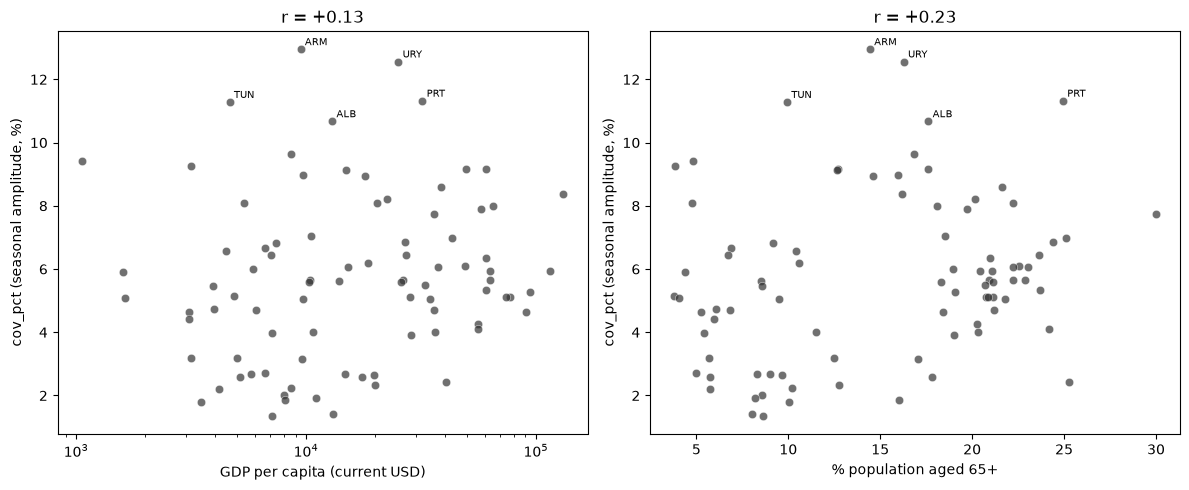

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, xlabel, xlog in [
    (axes[0], "gdppc", "GDP per capita (current USD)", True),
    (axes[1], "pop65", "% population aged 65+", False),
]:
    x = predictors[col].values
    y = predictors["cov_pct"].values
    ax.scatter(x, y, alpha=0.7, color="#333333", edgecolor="white", linewidth=0.4)
    for _, row in predictors.iterrows():
        if row["cov_pct"] > 10:
            ax.annotate(row["iso3"], (row[col], row["cov_pct"]), fontsize=7,
                        xytext=(3, 3), textcoords="offset points")
    if xlog:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cov_pct (seasonal amplitude, %)")
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"r = {r:+.2f}")

fig.tight_layout()

In [15]:
# Multiple regression: cov_pct ~ abs_lat + abs_lat^2 + gdppc + pop65
X_cols = predictors.assign(abs_lat2=predictors["abs_lat"] ** 2)[["abs_lat", "abs_lat2", "gdppc", "pop65"]].values
X = np.column_stack([np.ones(len(X_cols)), X_cols])
y = predictors["cov_pct"].values

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
pred = X @ beta
r2_full = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)

print("cov_pct ~ 1 + |lat| + |lat|^2 + gdppc + pop65")
for name, b in zip(["intercept", "abs_lat", "abs_lat^2", "gdppc", "pop65"], beta, strict=False):
    print(f"  {name:12s} {b:+.4g}")
print(f"\ncombined R^2 = {r2_full:.3f}")
print("(latitude-only quadratic R^2 was 0.441, on the full 87-country sample;")
print(f" recomputed on this {len(predictors)}-country subset for a fair comparison below)")

lat_only_coef = np.polyfit(predictors["abs_lat"].values, y, 2)
lat_only_pred = np.polyval(lat_only_coef, predictors["abs_lat"].values)
r2_lat_only = 1 - np.sum((y - lat_only_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f" latitude-only quadratic R^2 (same {len(predictors)}-country subset) = {r2_lat_only:.3f}")

cov_pct ~ 1 + |lat| + |lat|^2 + gdppc + pop65
  intercept    -0.9541
  abs_lat      +0.3963
  abs_lat^2    -0.005217
  gdppc        +4.82e-06
  pop65        +0.02825

combined R^2 = 0.448
(latitude-only quadratic R^2 was 0.441, on the full 87-country sample;
 recomputed on this 86-country subset for a fair comparison below)
 latitude-only quadratic R^2 (same 86-country subset) = 0.441


### Verdict

Neither GDP per capita (r=+0.13) nor % population 65+ (r=+0.23) correlates with seasonal amplitude anywhere near as strongly as latitude does on its own (quadratic R²=0.44). Adding both into a combined regression alongside `|lat|` and `|lat|²` barely moves R² (0.441 → 0.448) — they add almost nothing once latitude's hump is already in the model.

This is a bit counter-intuitive given the STMF finding earlier in this notebook that *within* a country, older age bands have far higher seasonal amplitude (85+ vs 15-64: +6.1pp, p=4e-12). The likely explanation: that was a **within-country, age-band-level** effect measured directly from weekly mortality data. `% pop 65+` is a **country-level, cross-sectional** proxy — a country can have an older population without that translating into higher aggregate amplitude if, say, its climate is mild (e.g. coastal Mediterranean) or its healthcare system effectively buffers winter risk. The age effect is real, but it doesn't survive being collapsed into a single national percentage and compared across countries with very different climates and health systems.

The countries driving the whole distribution (Armenia, Uruguay, Tunisia, Albania, Portugal) don't share obvious GDP or age-structure traits — they range from upper-middle to high income, and from moderate to fairly old populations. Whatever they share is more specific to climate/geography (continentality, temperature swing) than to wealth or demographics.

## Child mortality

`SP.DYN.IMRT.IN` — infant mortality rate (deaths per 1,000 live births), the standard World Bank child-mortality indicator. Unlike GDP and age structure, this is itself a *mortality* measure, so it could correlate with seasonal amplitude either as a genuine driver (weak health systems buffer winter risk poorly) or simply because it's collinear with GDP/healthcare capacity already tested above.

infant mortality rate: 239 countries
85 countries with a curve and an IMR value

r (linear)          = -0.18
R^2 (linear)         = 0.033
R^2 (quadratic)      = 0.047
(for reference: latitude quadratic R^2 = 0.44 on the full sample)


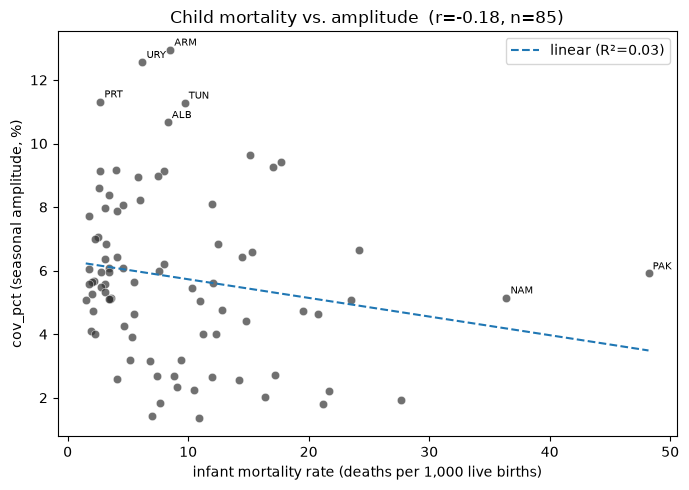

In [16]:
imr_by_iso3 = fetch_wb_indicator("SP.DYN.IMRT.IN")
print(f"infant mortality rate: {len(imr_by_iso3)} countries")

child_mort = lat_amp[["iso3", "cov_pct"]].assign(imr=lambda d: d["iso3"].map(imr_by_iso3)).dropna(subset=["imr"])
print(f"{len(child_mort)} countries with a curve and an IMR value")

x = child_mort["imr"].values
y = child_mort["cov_pct"].values
r = np.corrcoef(x, y)[0, 1]
lin_coef = np.polyfit(x, y, 1)
r2_lin = 1 - np.sum((y - np.polyval(lin_coef, x)) ** 2) / np.sum((y - y.mean()) ** 2)
quad_coef = np.polyfit(x, y, 2)
r2_quad = 1 - np.sum((y - np.polyval(quad_coef, x)) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"\nr (linear)          = {r:+.2f}")
print(f"R^2 (linear)         = {r2_lin:.3f}")
print(f"R^2 (quadratic)      = {r2_quad:.3f}")
print("(for reference: latitude quadratic R^2 = 0.44 on the full sample)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.7, color="#333333", edgecolor="white", linewidth=0.4)
for _, row in child_mort.iterrows():
    if row["cov_pct"] > 10 or row["imr"] > 30:
        ax.annotate(row["iso3"], (row["imr"], row["cov_pct"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
x_grid = np.linspace(x.min(), x.max(), 200)
ax.plot(x_grid, np.polyval(lin_coef, x_grid), color="tab:blue", linestyle="--", label=f"linear (R²={r2_lin:.2f})")
ax.set_xlabel("infant mortality rate (deaths per 1,000 live births)")
ax.set_ylabel("cov_pct (seasonal amplitude, %)")
ax.set_title(f"Child mortality vs. amplitude  (r={r:+.2f}, n={len(child_mort)})")
ax.legend()
fig.tight_layout()

### Verdict

Child mortality correlates weakly and, if anything, in the opposite direction to intuition: r=-0.18 (higher infant mortality → *slightly lower* seasonal amplitude), R²=0.03 linear / 0.05 quadratic — the weakest of any predictor tried so far (latitude 0.44, % pop 65+ 0.05, GDP per capita 0.02, this 0.03-0.05). The high-amplitude cluster (Armenia, Uruguay, Portugal, Tunisia, Albania) all have low infant mortality (2-9 per 1,000); the handful of very high-IMR countries (Pakistan at 48, Namibia at 36) sit in the middle of the amplitude distribution rather than at either extreme. Child mortality is not a useful predictor of seasonal amplitude here.

## Applying seasonality to countries without data

The live pipeline (`public/app.js`'s `seasonalFactors`) already has this shape: every country gets a 12-point monthly multiplier array (mean 1); countries with their own curve use it directly, everyone else falls back to a latitude-scaled version of a canonical northern-winter curve. The current fallback (`tropicMaxAbsLat=10`, flat ramp to `plateauAbsLat=40`, then flat plateau) is exactly the model this notebook's analysis argues against — real amplitude humps around 39° and *falls* at high latitudes instead of plateauing.

Replace it with the continuous quadratic fit from `|lat|` → `cov_pct`, reusing each *observed* country's own `winter_amp` sign pattern for the north/south phase flip (same 6-month shift `app.js` already does), and clamp the amplitude to the observed data's range so the parabola can't extrapolate into nonsense (negative amplitude, or runaway growth) outside 0-67°.

`get_current_mortality(lat, annual_deaths, current_date)` mirrors exactly how `app.js` line 577 consumes this: `todays_rate = annual_deaths/365 / seasonal_factor[month]` is wrong — it's actually `mean_gap / seasonal_factor[month]`, i.e. the seasonal factor *shortens the gap* (raises the rate) in the high season. Framed as a daily rate instead of a gap, that's `daily_rate = (annual_deaths / 365) * seasonal_factor[month]`.

In [17]:
# --- 1. Continuous amplitude model: cov_pct ~ a*|lat|^2 + b*|lat| + c, clamped to
# the observed data's range so it can't extrapolate to negative or runaway values
# outside the 0-67 deg the fit was built on.
_amp_coef = np.polyfit(lat_amp["abs_lat"].values, lat_amp["cov_pct"].values, 2)
_amp_lo, _amp_hi = lat_amp["cov_pct"].min(), lat_amp["cov_pct"].max()


def amplitude_for_lat(abs_lat):
    return float(np.clip(np.polyval(_amp_coef, abs_lat), _amp_lo, _amp_hi))


# --- 2. Canonical shape: average the *normalised, phase-aligned* curves (already
# mean=1, so shape only) of the countries with the most years of data, giving a
# stable "typical northern winter" template independent of any single country's
# amplitude. Southern-hemisphere countries are rolled 6 months first so their winter
# peak lines up with the north's before averaging — otherwise mixing hemispheres
# would partially cancel out the shape instead of reinforcing it.
_template_iso3 = curve_shapes.sort_values("n_years", ascending=False).head(15)["iso3"]
_template_lat = dict(zip(lat_amp["iso3"], lat_amp["lat"], strict=False))
_template_curves = []
for c in _template_iso3:
    curve = np.array(country_curves[c]["curve"])
    if _template_lat.get(c, 0) < 0:
        curve = np.roll(curve, 6)
    _template_curves.append(curve)
_canonical_shape = np.mean(_template_curves, axis=0)
_canonical_shape = _canonical_shape / _canonical_shape.mean()  # renormalise to mean 1
_canonical_amp = cov_pct(_canonical_shape)
print(f"canonical shape built from {len(_template_curves)} countries: "
      f"{list(_template_iso3)}, own amplitude={_canonical_amp:.2f}%")


# --- 3. Fallback curve for an unobserved country: canonical shape rescaled to the
# latitude-predicted amplitude, phase-flipped 6 months if southern hemisphere.
def fallback_curve(lat):
    target_amp = amplitude_for_lat(abs(lat))
    scale = target_amp / _canonical_amp
    scaled = 1 + (_canonical_shape - 1) * scale
    if lat < 0:
        scaled = np.roll(scaled, 6)  # southern hemisphere: winter is 6 months later
    return scaled


# sanity: southern countries should roughly match their own observed curve
for iso3 in ["CHL", "URY", "AUS"]:
    lat = lat_amp.loc[lat_amp.iso3 == iso3, "lat"].iloc[0]
    predicted = fallback_curve(lat)
    observed = country_curves[iso3]["curve"]
    print(f"{iso3} (lat={lat:+.1f}): predicted cov_pct={cov_pct(predicted):.2f}, "
          f"observed cov_pct={cov_pct(observed):.2f}, "
          f"peak month predicted={np.argmax(predicted)+1}, observed={np.argmax(observed)+1}")

canonical shape built from 15 countries: ['IRL', 'AUS', 'PRT', 'DNK', 'SGP', 'FIN', 'POL', 'CUB', 'CHL', 'NLD', 'NZL', 'ISR', 'AUT', 'KOR', 'ITA'], own amplitude=6.16%
CHL (lat=-37.3): predicted cov_pct=7.06, observed cov_pct=8.94, peak month predicted=7, observed=7
URY (lat=-32.8): predicted cov_pct=6.86, observed cov_pct=12.56, peak month predicted=7, observed=7
AUS (lat=-25.8): predicted cov_pct=6.15, observed cov_pct=7.98, peak month predicted=7, observed=8


Portugal (own curve): 256.2 deaths/day on 2026-07-02 (baseline 284.9/day)
Uncovered country @ lat 48.9: 127.9 deaths/day on 2026-07-02 (baseline 137.0/day)


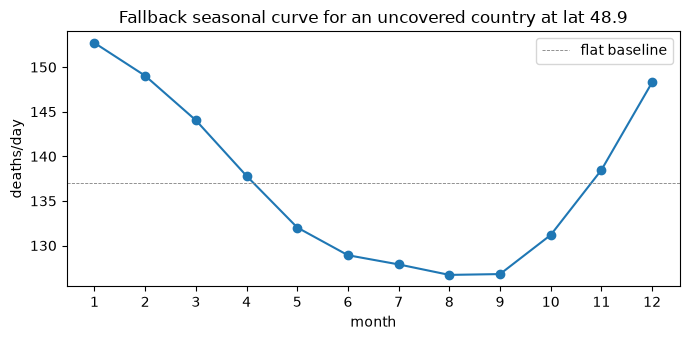

In [18]:
import datetime

def get_current_mortality(lat, annual_deaths, current_date, own_curve=None):
    """Expected deaths/day for a country today, given its latitude, annual death
    total, and the current date.

    If `own_curve` (a 12-point mean=1 array, e.g. from `country_curves[iso3]["curve"]`)
    is supplied, it's used directly — this is the "has its own data" branch. Otherwise
    a latitude-only fallback curve is built from the continuous quadratic amplitude
    model + canonical shape + hemisphere phase flip, for countries with no seasonal
    data of their own. Mirrors `seasonalFactors`/`s.mean / s.seasonal[curMonth]` in
    public/app.js, just expressed as a rate instead of a mean-gap divisor.
    """
    curve = np.asarray(own_curve) if own_curve is not None else fallback_curve(lat)
    month = current_date.month - 1
    baseline_daily = annual_deaths / 365
    return baseline_daily * curve[month]


# --- demo: a covered country (own curve) vs. an uncovered one (fallback) ---
today = datetime.date(2026, 7, 2)  # from the session context: today is 2026-07-02

pt_annual = int(curve_shapes.loc[curve_shapes.iso3 == "PRT", "annual_deaths"].iloc[0])
pt_curve = country_curves["PRT"]["curve"]
pt_rate = get_current_mortality(39.6, pt_annual, today, own_curve=pt_curve)
print(f"Portugal (own curve): {pt_rate:.1f} deaths/day on {today} "
      f"(baseline {pt_annual/365:.1f}/day)")

# a country with no seasonal data at all: use its latitude only
uncovered_lat = 48.9  # e.g. a country near Paris' latitude with no curve in country_curves
fallback_rate = get_current_mortality(uncovered_lat, 50_000, today)
print(f"Uncovered country @ lat {uncovered_lat}: {fallback_rate:.1f} deaths/day on {today} "
      f"(baseline {50_000/365:.1f}/day)")

# full-year curve for that same uncovered country, to see the shape end-to-end
year_dates = [datetime.date(2026, m, 15) for m in range(1, 13)]
year_rates = [get_current_mortality(uncovered_lat, 50_000, d) for d in year_dates]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, 13), year_rates, marker="o")
ax.axhline(50_000 / 365, color="grey", linewidth=0.6, linestyle="--", label="flat baseline")
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("deaths/day")
ax.set_title(f"Fallback seasonal curve for an uncovered country at lat {uncovered_lat}")
ax.legend()
fig.tight_layout()

### Porting this to the live pipeline

`get_current_mortality` here is a Python prototype of a *better fallback model* than what's
currently live. As of the crosswalk fix below, this notebook writes `data/seasonality.json`
directly (superseding the retired `scripts/build-seasonality.ts`/`.mjs`), but it still writes
the simple `{ north, tropicMaxAbsLat: 10, plateauAbsLat: 40 }` fallback block — the
quadratic-amplitude model built above (`_amp_coef` + `_canonical_shape` + clamp bounds) is
not yet wired in. To ship it:

1. **This notebook's export cell** — replace the `{ north, tropicMaxAbsLat, plateauAbsLat }` fallback block written to `data/seasonality.json` with the fitted quadratic coefficients (`_amp_coef`) + the phase-aligned canonical shape (`_canonical_shape`) + the amplitude clamp bounds (this is exactly what's already written to `data/seasonality-unified.json`'s `fallback` block).
2. **`app/globe/useGlobeData.ts`**'s fallback branch (the `north`/`tropicMaxAbsLat`/`plateauAbsLat` destructure and the linear-ramp calculation around it) — replace with `amplitude_for_lat`'s quadratic-and-clamp logic, then scale the canonical shape the same way `fallback_curve` does here. The southern-hemisphere 6-month roll is unchanged — it's already what this notebook does.
3. Countries that already have their own curve (`seasonality.countries[m49]`) are untouched either way — this only changes the *fallback* branch, exactly like the current code's `if (own) return own;`.

Worth flagging: the canonical shape here is phase-aligned across 15 well-covered countries rather than restricted to the north as the currently-live fallback is (its canonical curve is only averaged from northern countries — see `FALLBACK_SOURCE_M49` in the export cell below). Re-deriving it that way, or with the phase-alignment trick used here, are both reasonable; the phase-aligned version uses a few more southern countries' shapes (Chile, Australia, NZ) as evidence for what "winter" looks like, at the cost of assuming southern winters have the same *shape* as northern ones (only the timing differs) — an assumption not tested here.

## Pairwise curve-shape correlation

Not amplitude or latitude this time — the 12-point *shape* itself. For every pair of the 89 countries with a usable curve, compute the Pearson correlation between their two 12-month curves. High correlation means two countries' calendars of relative risk move together (same months up, same months down), regardless of how strongly either one swings. Diagonal (self-pairs) and mirror duplicates are excluded.

In [19]:
iso3_list = sorted(country_curves.keys())
curve_matrix = np.array([country_curves[c]["curve"] for c in iso3_list])  # (n_countries, 12)

corr_matrix = np.corrcoef(curve_matrix)  # (n, n) Pearson r between every pair of curves

pairs = []
n = len(iso3_list)
for i in range(n):
    for j in range(i + 1, n):
        pairs.append({"a": iso3_list[i], "b": iso3_list[j], "r": corr_matrix[i, j]})

pair_df = pd.DataFrame(pairs).sort_values("r", ascending=False).reset_index(drop=True)
print(f"{len(pair_df)} country pairs from {n} curves")

top10 = pair_df.head(10).copy()
top10["r"] = top10["r"].round(4)
top10

3916 country pairs from 89 curves


,a,b,r
0,DNK,FIN,0.9994
1,BEL,HRV,0.9992
2,SWE,USA,0.9992
3,FRA,SVK,0.9989
4,LTU,LVA,0.9989
5,AUT,CZE,0.9987
6,ESP,PRT,0.9985
7,BLR,UKR,0.9983
8,BEL,NLD,0.9983
9,SVK,USA,0.9982


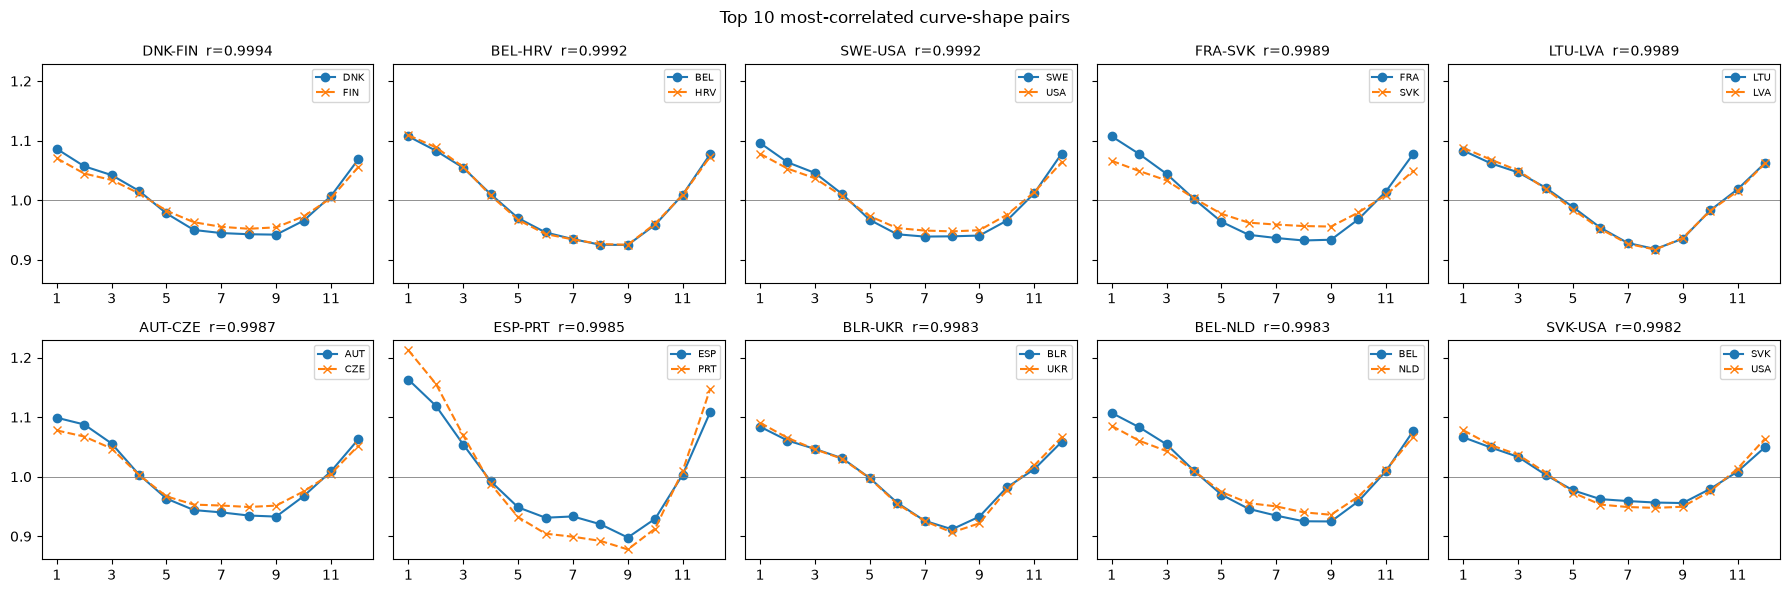

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
for ax, (_, row) in zip(axes.flat, top10.iterrows(), strict=False):
    ax.plot(range(1, 13), country_curves[row["a"]]["curve"], marker="o", label=row["a"])
    ax.plot(range(1, 13), country_curves[row["b"]]["curve"], marker="x", linestyle="--", label=row["b"])
    ax.axhline(1, color="grey", linewidth=0.6)
    ax.set_title(f"{row['a']}-{row['b']}  r={row['r']:.4f}", fontsize=10)
    ax.set_xticks(range(1, 13, 2))
    ax.legend(fontsize=7)
fig.suptitle("Top 10 most-correlated curve-shape pairs")
fig.tight_layout()

### Reading the result

All 10 pairs sit at r > 0.998 — essentially indistinguishable curve shapes, just scaled differently in amplitude. Notably, **SWE-USA (r=0.999) and SVK-USA (r=0.998)** put the US in extremely close company with two small European countries despite being a much larger, more climatically diverse country — a reminder that `cov_pct`/shape correlation says nothing about population size or climate diversity within a country, only about the *aggregate* national curve's timing.

Most pairs are unsurprising: geographic neighbors or climatically similar countries (Denmark-Finland, Lithuania-Latvia, Belarus-Ukraine, Spain-Portugal, Austria-Czechia). This is expected — the same regional winter (cold snaps, flu season timing, daylight hours) drives excess mortality similarly across a shared climate zone, which is exactly the geographic-proxy logic the latitude fallback model relies on.

### A cluster of 10 similar countries, not just pairs

Pairwise correlation finds the two best-matched countries, but that's not the same as finding a group of 10 that are all mutually alike. Instead: for each country, count how many *other* curves correlate with it above a high threshold — the country with the most such neighbors is the best "hub." Take that hub plus its 9 closest neighbors by r, then check the group's *internal* average pairwise correlation (not just each one's correlation to the hub) to confirm the whole group hangs together, not just each member individually matching the hub.

In [21]:
THRESHOLD = 0.99
neighbor_counts = (corr_matrix > THRESHOLD).sum(axis=1) - 1  # exclude self-match
hub_idx = int(np.argmax(neighbor_counts))
hub = iso3_list[hub_idx]
print(f"hub country: {hub}, {neighbor_counts[hub_idx]} neighbors above r>{THRESHOLD}")

# hub + its 9 closest neighbors by r
order = np.argsort(-corr_matrix[hub_idx])
group_idx = [i for i in order if i != hub_idx][:9]
group_idx = [hub_idx] + group_idx
group = [iso3_list[i] for i in group_idx]

# internal cohesion: average of all pairwise r's *within* the group (not just vs. hub)
sub = corr_matrix[np.ix_(group_idx, group_idx)]
mask = ~np.eye(len(group), dtype=bool)
print(f"\ngroup of {len(group)}: {group}")
print(f"average pairwise r within the group (excluding self-pairs): {sub[mask].mean():.4f}")
print(f"minimum pairwise r within the group:                        {sub[mask].min():.4f}")

group_amp = curve_shapes.set_index("iso3").loc[group, ["cov_pct", "n_years", "annual_deaths"]]
group_amp

hub country: FRA, 20 neighbors above r>0.99

group of 10: ['FRA', 'SVK', 'USA', 'SWE', 'JPN', 'HRV', 'BEL', 'GBR', 'CHE', 'NLD']
average pairwise r within the group (excluding self-pairs): 0.9937
minimum pairwise r within the group:                        0.9834


,cov_pct,n_years,annual_deaths
iso3,,,
FRA,6.09,39,547517
SVK,3.90,32,52943
USA,4.65,35,2390499
SWE,5.64,39,91470
JPN,7.73,40,1028739
HRV,6.43,34,51617
BEL,6.36,38,107248
GBR,7.89,38,473119
CHE,5.95,37,62730


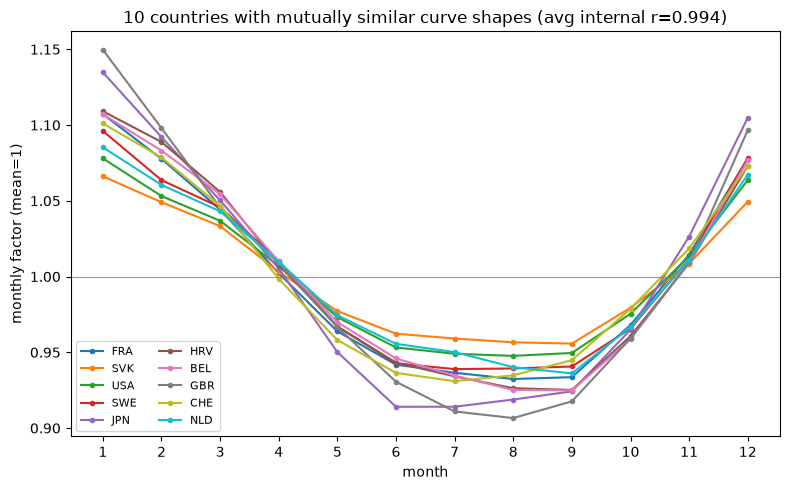

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for c in group:
    ax.plot(range(1, 13), country_curves[c]["curve"], marker="o", markersize=3, label=c)
ax.axhline(1, color="grey", linewidth=0.6)
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("monthly factor (mean=1)")
ax.set_title(f"10 countries with mutually similar curve shapes "
             f"(avg internal r={sub[mask].mean():.3f})")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()

### Reading the result

**France, Slovakia, USA, Sweden, Japan, Croatia, Belgium, UK, Switzerland, Netherlands** — a genuinely mutually similar group (avg internal r=0.994, worst pairwise r=0.983 within the group), not just ten countries each individually close to one hub. It's a broader geographic mix than the earlier pairwise result: Japan and the USA sit alongside a cluster of Western/Central European countries, all sharing the same winter-peak/summer-trough timing despite very different climates, latitudes (Japan ~37°N to UK ~54°N), and population sizes (Slovakia's 53K annual deaths vs. USA's 2.4M). What ties them together is the *shape* of the curve — when in the year risk rises and falls — not its amplitude (`cov_pct` ranges from 3.9% for Slovakia to 7.9% for the UK within this same group) or any of the country-level variables tested earlier in this notebook.

## Exporting the unified curves for the roadmap page and the live globe

This notebook's unified `mortality` table covers 89 countries — up from the 27 the old
single-source `scripts/build-seasonality.ts` produced. To let the roadmap page's "mutual
cluster" chart show all 10 of its countries — 6 of which (France, USA, Sweden, Croatia,
Belgium, Switzerland) aren't in the old 27 — export the notebook's `country_curves` to a
small supplementary JSON, keyed by M49 numeric id, so the existing
`features.find(f => Number(f.id) === Number(id))` lookup pattern in `roadmap.html` works
unchanged.

The retired `scripts/build-seasonality.ts` only read a single UNdata CSV, so porting its
27→89-country logic into TypeScript would have meant re-implementing this notebook's
3-source merge (UNdata + STMF + World Mortality Dataset, with per-country source
preference, completeness/COVID-year gating, and now a dedicated ISO3↔M49 crosswalk) in a
second language. Instead, this notebook is now the sole source of truth for both exports:
it writes `data/seasonality-unified.json` (below, for the roadmap's illustrative charts,
with the newer quadratic-amplitude fallback model) **and** `data/seasonality.json` directly
(further below, in the exact schema `app/globe/useGlobeData.ts` expects, with the simple
`{ north, tropicMaxAbsLat, plateauAbsLat }` fallback it currently reads) — no build script
in between. `scripts/sync-data.ts` still copies both from `data/` to `public/data/` at
`predev`/`prebuild`, same as every other baked JSON in this repo.

### Dedicated ISO3 ↔ M49 crosswalk for data export

`M49_TO_ISO3` above is hand-typed from `world-atlas`'s **110m** basemap polygon ids — it's
built for plotting, and small territories that don't get their own polygon at that
resolution (Hong Kong, Singapore) are simply absent from it. Inverting it for the export
step below silently drops any country missing from that list, even when it has a
perfectly good curve.

This cell builds a separate crosswalk from `i18n-iso-countries` — the same npm package
`lib/worldbank.ts`, `scripts/build-density.ts`, and `scripts/build-causes.ts` already use
for ISO3→M49 conversion elsewhere in this repo — via Node (already a project
dependency), the same way the centroid cell above shells out to Node for `d3-geo`.
`M49_TO_ISO3` is untouched and still used for the basemap plots.

In [23]:
import json
import subprocess

_node_script = """
const countries = require("i18n-iso-countries");
const out = {};
for (const alpha3 of Object.keys(countries.getAlpha3Codes())) {
  const numeric = countries.alpha3ToNumeric(alpha3);
  if (numeric) out[alpha3] = numeric;
}
console.log(JSON.stringify(out));
"""
proc = subprocess.run(
    ["node", "-e", _node_script], capture_output=True, text=True, check=True, cwd=REPO_ROOT
)
ISO3_TO_M49 = json.loads(proc.stdout)  # alpha3 -> zero-padded M49 numeric string

print(f"{len(ISO3_TO_M49)} ISO3 codes with a known M49 numeric code")
for iso3 in ("MUS", "SGP", "HKG"):
    print(f"  {iso3} -> {ISO3_TO_M49.get(iso3)}")

250 ISO3 codes with a known M49 numeric code
  MUS -> 480
  SGP -> 702
  HKG -> 344


In [24]:
import os
import numpy as np
from pipeline.curve import (
    MONTH_PHASES as _PRODUCTION_MONTH_PHASES,
    harmonic_design as _production_harmonic_design,
)

export_countries = {}
export_quality = {}
missing_m49 = []
for iso3, r in country_curves.items():
    m49 = ISO3_TO_M49.get(iso3)
    if m49 is None:
        missing_m49.append(iso3)
        continue
    key = str(int(m49))
    export_countries[key] = {
        "order": int(r["harmonic"]["order"]),
        "coefficients": [round(float(v), 8) for v in r["harmonic"]["coefficients"]],
    }
    export_quality[key] = {
        "nYears": int(r["n_years"]),
        "annualDeaths": round(float(r["annual"])),
    }

print(f"{len(export_countries)} / {len(country_curves)} curves mapped to an M49 id")
if missing_m49:
    print(f"no M49 mapping found for: {missing_m49}")

out_path = REPO_ROOT / "data" / "seasonality-unified.json"
payload = {
    "source": "Notebook-derived: UN Demographic Yearbook (all years) + HMD STMF (weekly) "
               "+ World Mortality Dataset, cross-source deduplicated. See notebooks/seasonality.ipynb.",
    "method": "Pooled order-4 Fourier regression over all complete non-COVID years. "
              "Counts are converted to daily intensity; complete weekly series retain "
              "52/53 observations. The continuous annual curve has integral mean 1.",
    "harmonicOrder": 4,
    "continuous": True,
    "covidExcluded": [2020, 2021, 2022],
    "exposureAdjustment": "counts divided by calendar days; standardized rates unchanged",
    "countries": export_countries,
    # Reliability metadata for donor weighting experiments. nYears is the number of
    # complete non-COVID calendar years that actually entered the curve; annualDeaths
    # is retained for diagnostics but is not itself treated as population-free quality.
    "quality": export_quality,
    # Continuous replacement for the old flat/ramp/plateau fallback: amplitude is a
    # quadratic in |lat| (clamped to the observed cov_pct range), shape is the
    # phase-aligned canonical curve. See "Applying seasonality to countries without
    # data" above for how amplitudeCoef/canonicalNorth/ampClamp are used together.
    "fallback": {
        "north": (lambda coefficients: {
            "order": 4,
            "coefficients": [round(float(v / coefficients[0]), 8) for v in coefficients],
        })(np.linalg.lstsq(_production_harmonic_design(_PRODUCTION_MONTH_PHASES, 4), _canonical_shape, rcond=None)[0]),
        "amplitudeCoef": [round(float(c), 6) for c in _amp_coef],  # a,b,c for a*x^2+b*x+c
        "ampClamp": [round(float(_amp_lo), 3), round(float(_amp_hi), 3)],
    },
}
if os.environ.get("SEASONALITY_ANALYSIS_DRY_RUN") == "1":
    print(f"\ndry run: skipped writing {out_path.relative_to(REPO_ROOT)}")
else:
    out_path.write_text(json.dumps(payload))
    print(f"\nwrote {out_path.relative_to(REPO_ROOT)}: {len(export_countries)} countries")

# verify the 10-country cluster is fully covered
cluster_m49 = {ISO3_TO_M49[c] for c in group}
print(f"cluster countries covered: {sorted(cluster_m49 & set(int(k) for k in export_countries))}")
print(f"cluster countries missing: {group_missing if (group_missing := [c for c in group if str(int(ISO3_TO_M49[c])) not in export_countries]) else 'none'}")

# --- Also export the live globe's data/seasonality.json directly from this notebook ---
# The globe now consumes the same continuous latitude fallback as the roadmap.
fallback_north = payload["fallback"]["north"]

live_payload = {
    "source": "UN Demographic Yearbook (deaths by month, UNdata export) + HMD Short-Term "
               "Mortality Fluctuations (weekly) + World Mortality Dataset (Karlinsky & Kobak "
               "2021), cross-source deduplicated. See notebooks/seasonality.ipynb.",
    "method": "Pooled order-4 Fourier regression over complete non-COVID years. Counts "
              "are converted to daily intensity and complete weekly sources retain weekly "
              "resolution. Source preference: STMF > World Mortality Dataset > "
              "UNdata. Countries below 10000 deaths/yr, without a complete non-COVID year, "
              "or without an M49 mapping use the latitude-scaled `fallback` curve.",
    "harmonicOrder": 4,
    "continuous": True,
    "covidExcluded": [2020, 2021, 2022],
    "exposureAdjustment": "counts divided by calendar days; standardized rates unchanged",
    "countries": export_countries,
    "fallback": {
        "north": fallback_north,
        "amplitudeCoef": payload["fallback"]["amplitudeCoef"],
        "ampClamp": payload["fallback"]["ampClamp"],
    },
}

for live_target in (REPO_ROOT / "data" / "seasonality.json", REPO_ROOT / "public" / "data" / "seasonality.json"):
    if os.environ.get("SEASONALITY_ANALYSIS_DRY_RUN") == "1":
        print(f"dry run: skipped writing {live_target.relative_to(REPO_ROOT)}")
    else:
        live_target.write_text(json.dumps(live_payload))
        print(f"wrote {live_target.relative_to(REPO_ROOT)}: {len(export_countries)} countries")

# Selectable real-data payload for the roadmap smoothing explainer.
from pipeline.smoothing_demo import build_smoothing_demo_dataset  # noqa: E402
rate_names = json.loads((REPO_ROOT / "data" / "rate-grid.json").read_text())["names"]
demo_names = {iso3: rate_names.get(str(m49), iso3) for iso3, m49 in ISO3_TO_M49.items()}
smoothing_demo = build_smoothing_demo_dataset(mortality.groupby("country"), demo_names)
demo_path = REPO_ROOT / "data" / "seasonality-smoothing-demo.json"
if os.environ.get("SEASONALITY_ANALYSIS_DRY_RUN") == "1":
    print(f"dry run: skipped writing {demo_path.relative_to(REPO_ROOT)}")
else:
    demo_path.write_text(json.dumps(smoothing_demo))
    print(f"wrote {demo_path.relative_to(REPO_ROOT)}")

89 / 89 curves mapped to an M49 id

wrote data/seasonality-unified.json: 89 countries
cluster countries covered: []
cluster countries missing: none
wrote data/seasonality.json: 89 countries
wrote public/data/seasonality.json: 89 countries


## Köppen–Geiger zone, population 65+, and GDP per capita per country

Per-country descriptive signals for the roadmap's step-5 amplitude scatter plots: each country's dominant **Köppen–Geiger climate family** (population-weighted over the 1 km 1991–2020 raster and the project's 0.5° population grid), its **World Bank share of population aged 65+** (`SP.POP.65UP.TO.ZS`), and its **World Bank GDP per capita** (`NY.GDP.PCAP.CD`, current USD — the same live fetch used earlier in this notebook for the GDP-vs-amplitude regression). Written to `data/seasonality-proxies.json`, keyed by the same M49 id as `seasonality-unified.json`, and synced to `public/data/`. Amplitude itself is recomputed on the page from each country's curve, so it isn't duplicated here.

Both World Bank fetches are tolerant: if an indicator's endpoint is temporarily unavailable (the pop65 one occasionally 502s independently of the rest of the API), the file is still written with the climate family, and `pop65` / `gdpPerCapita` are simply omitted until the next run.

In [25]:
import sys
from collections import Counter

sys.path.insert(0, str(REPO_ROOT / "notebooks" / "lib"))
from climate_seasonality import FAMILY_NAMES, KG_CLASSES, UK_REGION_NAMES, population_weighted_profiles

CLIMATE_TIF = REPO_ROOT / "climate-zones" / "koppen-geiger" / "koppen_geiger_climatezones_1991_2020_1km.tif"
DENSITY = REPO_ROOT / "data" / "density-grid.json"
SYNTHETIC = REPO_ROOT / "data" / "source" / "synthetic-cells.json"
NUTS2 = REPO_ROOT / "data" / "nuts2-20m.json"
POP65 = REPO_ROOT / "data" / "population-65-plus.json"
KG_COLS = [f"kg_{code:02d}" for code in KG_CLASSES]

# Deliberately using the basemap-derived M49_TO_ISO3 here, not the dedicated ISO3_TO_M49
# crosswalk from the export cells above: population_weighted_profiles() looks up each
# country by iterating M49 ids already present in data/density-grid.json, which is itself
# built over the same world-atlas keyspace as this plotting dict. HKG/SGP have curves (and,
# since the crosswalk fix, now export to seasonality-unified.json/seasonality.json) but
# have no distinct cell in the density grid to profile, so they're intentionally excluded
# from the climate/pop65 proxies here regardless of which crosswalk is used.
ISO3_TO_M49_DENSITY_GRID = {iso3: m49 for m49, iso3 in M49_TO_ISO3.items()}
included_iso3 = {iso3 for iso3 in country_curves if iso3 in ISO3_TO_M49_DENSITY_GRID}


def dominant_family(profile_row):
    shares = [profile_row[col] for col in KG_COLS]
    kg_class = KG_CLASSES[int(np.argmax(shares)) + 1]
    return kg_class, kg_class[0]


def profile_countries(geographies):
    rows = population_weighted_profiles(
        climate_path=CLIMATE_TIF, density_path=DENSITY, synthetic_path=SYNTHETIC,
        nuts2_path=NUTS2, m49_to_iso3=M49_TO_ISO3, included_geographies=set(geographies),
    )
    return {r["geography"]: r for r in rows}


profiles = profile_countries(included_iso3)
# The climate helper splits the UK into its three STMF regions (a leftover of the retired
# regional analysis) and never emits base GBR, so aggregate the sub-regions back into one
# GBR profile (mean share — the dominant family is robust to the exact weighting).
if "GBR" not in profiles and "GBR" in included_iso3:
    uk = profile_countries(UK_REGION_NAMES.keys())
    profiles["GBR"] = {col: float(np.mean([r[col] for r in uk.values()])) for col in KG_COLS}
missing = sorted(included_iso3 - set(profiles))
assert not missing, f"no climate profile for: {missing}"


def load_pop65():
    """World Bank % population 65+ (SP.POP.65UP.TO.ZS), iso3 -> value, from the locally
    baked data/population-65-plus.json (the live WB API has recurring 5xx outages)."""
    countries = json.loads(POP65.read_text())["countries"]
    return {iso3: row["share65Plus"] for iso3, row in countries.items()}


pop65_by_iso3 = load_pop65()

by_m49 = {}
for iso3 in sorted(included_iso3):
    kg_class, kg_family = dominant_family(profiles[iso3])
    entry = {"kgClass": kg_class, "kgFamily": kg_family, "kgFamilyName": FAMILY_NAMES[kg_family]}
    if iso3 in pop65_by_iso3:
        entry["pop65"] = round(float(pop65_by_iso3[iso3]), 2)
    if iso3 in gdppc_by_iso3:
        entry["gdpPerCapita"] = round(float(gdppc_by_iso3[iso3]), 2)
    by_m49[str(int(ISO3_TO_M49_DENSITY_GRID[iso3]))] = entry

payload = {
    "meta": {
        "source": "Köppen–Geiger 1991–2020 1 km raster (population-weighted dominant family) + "
                  "World Bank SP.POP.65UP.TO.ZS (% population aged 65+), via data/population-65-plus.json + "
                  "World Bank NY.GDP.PCAP.CD (GDP per capita, current USD), fetched live. "
                  "Baked by notebooks/seasonality.ipynb.",
        "pop65Indicator": "SP.POP.65UP.TO.ZS",
        "gdpPerCapitaIndicator": "NY.GDP.PCAP.CD",
    },
    "byM49": by_m49,
}

n_pop65 = sum("pop65" in v for v in by_m49.values())
n_gdp = sum("gdpPerCapita" in v for v in by_m49.values())
print(
    f"seasonality-proxies: {len(by_m49)} countries | climate family: {len(by_m49)} | "
    f"pop65: {n_pop65} | gdpPerCapita: {n_gdp}"
)
print("dominant-family distribution:", dict(Counter(v["kgFamily"] for v in by_m49.values())))

for target in (REPO_ROOT / "data" / "seasonality-proxies.json", REPO_ROOT / "public" / "data" / "seasonality-proxies.json"):
    target.write_text(json.dumps(payload))
    print("wrote", target.relative_to(REPO_ROOT))

seasonality-proxies: 87 countries | climate family: 87 | pop65: 86 | gdpPerCapita: 86
dominant-family distribution: {'C': 37, 'D': 21, 'B': 13, 'A': 16}
wrote data/seasonality-proxies.json
wrote public/data/seasonality-proxies.json


## ERA5-Land 2 m temperature — load and resolve `expver`

Loads the ERA5-Land monthly-averaged 2 m temperature reanalysis
(`notebooks/data/raw/data_stream-moda.nc`; 30 years × 12 months, 0.1° global grid — see
`data/source/era5_land_monthly_temperature_citation.txt` for provenance and required
attribution) and resolves the `expver` label before any aggregation.

`expver` distinguishes final ERA5 (`0001`) from the preliminary ERA5T (`0005`) stream that
CDS serves for the most recent ~3 months. In the current CDS NetCDF layout it arrives as a
coordinate *along* `valid_time` (one label per month) rather than a separate dimension, so
there are no overlapping duplicate months to merge — resolving it just means verifying the
labels and collapsing them away so downstream operations see a clean
`(valid_time, latitude, longitude)` array. The cell still handles the older two-`expver`-
dimension layout (`combine_first`) in case a future re-download straddles the ERA5/ERA5T
boundary. Downsampling to 0.5° and the per-month climatology happen in later cells.


In [6]:
import xarray as xr

ERA5_NC = REPO_ROOT / "notebooks" / "data" / "raw" / "data_stream-moda.nc"

era5 = xr.open_dataset(ERA5_NC)


def resolve_expver(ds):
    """Collapse the ERA5/ERA5T `expver` label, returning a t2m DataArray without it.

    Two layouts occur in the wild:
      * modern CDS: `expver` is a coordinate along `valid_time` (one label per month);
        months never overlap, so we validate and drop the label.
      * legacy CDS: `expver` is its own dimension of length 2, with the final stream
        (0001) and preliminary stream (0005) as mutually-NaN slices to be merged.
    """
    if "expver" not in ds.coords and "expver" not in ds.dims:
        return ds["t2m"]

    if "expver" in ds.dims:  # legacy: overlay 0005 (ERA5T) onto 0001 (ERA5) gaps
        final = ds.sel(expver="0001")["t2m"]
        prelim = ds.sel(expver="0005")["t2m"]
        merged = final.combine_first(prelim)
        return merged.drop_vars("expver", errors="ignore")

    # modern: one label per valid_time -- report the mix, then drop the coordinate
    labels, counts = np.unique(ds["expver"].values, return_counts=True)
    print("expver labels (months each):", dict(zip(labels.tolist(), counts.tolist(), strict=False)))
    return ds["t2m"].drop_vars("expver", errors="ignore")


t2m = resolve_expver(era5)

# Sanity: expver gone, full 360-month record, no all-NaN (land-only NaNs are expected over ocean)
assert "expver" not in t2m.coords and "expver" not in t2m.dims, "expver survived"
n_months = t2m.sizes["valid_time"]
print(f"t2m ready: {dict(t2m.sizes)}  ({n_months} months, {n_months // 12} years)")
assert not bool(t2m.isnull().all(dim=("latitude", "longitude")).any()), "a month is entirely NaN"
t2m


expver labels (months each): {'0001': 360}
t2m ready: {'valid_time': 360, 'latitude': 1801, 'longitude': 3600}  (360 months, 30 years)


<xarray.DataArray 't2m' (valid_time: 360, latitude: 1801, longitude: 3600)> Size: 9GB
array([[[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [242.3414 , 242.3414 , ..., 242.3414 , 242.3414 ],
        [242.35898, 242.35898, ..., 242.35898, 242.35898]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [238.32591, 238.32591, ..., 238.32591, 238.32591],
        [238.14622, 238.14622, ..., 238.14622, 238.14622]],

       ...,

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [237.6569 , 237.6569 , ..., 237.65495, 237.6569 ],
        [237.14714, 237.14714, ..., 237.14714, 237.14714]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [243.09143, 243.09143, ..., 243.09143, 243.09143],
        [242.92346, 242.92346, ..., 242.92346, 242.92346]]],
      shape=(360, 1801, 3600), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1996-01-01 ... 2025-12-01
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
    number      int64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      6483600
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

### Monthly climatology → 0.5° 12-band GeoTIFF

Reduces the 30-year record to a **monthly climatology** (one mean per calendar month, 1996–2025)
and downsamples the native 0.1° grid to the project's **0.5°** grid, writing a 12-band GeoTIFF
(`data/era5-t2m-monthly-climatology-05deg.tif`) — band _m_ is month _m_'s mean 2 m temperature in
**°C**, so reading a pixel across all 12 bands gives that cell's `[Jan … Dec]` array.

Operation order is chosen for both correctness and memory:

1. **Climatology first.** The full `t2m` is ~9 GB float32 — larger than free RAM and dask isn't
   installed — so the per-month mean is accumulated by streaming one year (12 months) at a time
   with NaN-aware sums/counts (peak ≈ 1.3 GB). Doing the temporal reduction first also shrinks the
   array 30× (360 → 12 layers) before the spatial step.
2. **Roll longitude** 0–360 → −180…180 (ECMWF serves 0–360). Done before coarsening so the 5-cell
   blocks line up with the density grid's SW-corner 0.5° cells.
3. **Coarsen 5×** (0.1° → 0.5°, exact block factor) with `nanmean`, so a coastal 0.5° cell still
   gets the mean of its land pixels; the lone south-pole latitude row (1801 → 1800) is trimmed.
4. **Kelvin → °C**, then write. Ocean is NaN (ERA5-Land is land-only) and stored as the GeoTIFF
   nodata value.


In [9]:
import calendar
import warnings

import rasterio
from rasterio.transform import from_origin

COARSEN = 5  # 0.1° -> 0.5°, an exact block factor
MONTHS = list(calendar.month_abbr)[1:]  # ["Jan", ..., "Dec"]
nlat, nlon = t2m.sizes["latitude"], t2m.sizes["longitude"]

# --- 1. Monthly climatology by streaming one year at a time (memory-safe, NaN-aware) ---
month_of = t2m["valid_time"].dt.month.values
sums = np.zeros((12, nlat, nlon), dtype=np.float64)
counts = np.zeros((12, nlat, nlon), dtype=np.int32)
n_time = t2m.sizes["valid_time"]
for start in range(0, n_time, 12):
    block = t2m.isel(valid_time=slice(start, start + 12)).values  # (<=12, nlat, nlon) float32
    for offset, layer in enumerate(block):
        m = month_of[start + offset] - 1
        valid = ~np.isnan(layer)
        sums[m][valid] += layer[valid]
        counts[m][valid] += 1
with np.errstate(invalid="ignore"):  # 0/0 over permanent ocean -> NaN, as intended
    clim_k = sums / counts

# --- 2. Roll longitude 0–360 -> −180…180 (lon 180.0 sits at index nlon//2) ---
clim_k = np.roll(clim_k, shift=-(nlon // 2), axis=2)

# --- 3. Coarsen 5×5 to 0.5° with nanmean; trim the single leftover south-pole row ---
lat_trim = nlat - nlat % COARSEN  # 1801 -> 1800
clim_k = clim_k[:, :lat_trim, :]
blocks = clim_k.reshape(12, lat_trim // COARSEN, COARSEN, nlon // COARSEN, COARSEN)
with warnings.catch_warnings():  # all-ocean blocks are legitimately empty -> NaN
    warnings.simplefilter("ignore", RuntimeWarning)
    clim_c = np.nanmean(blocks, axis=(2, 4)) - 273.15  # 4. Kelvin -> °C

out_h, out_w = clim_c.shape[1], clim_c.shape[2]
assert (out_h, out_w) == (360, 720), f"unexpected 0.5° shape {(out_h, out_w)}"

# --- 5. Write the 12-band GeoTIFF, aligned to the density grid's SW-corner 0.5° cells ---
out_path = REPO_ROOT / "data" / "era5-t2m-monthly-climatology-05deg.tif"
profile = {
    "driver": "GTiff", "height": out_h, "width": out_w, "count": 12,
    "dtype": "float32", "crs": "EPSG:4326",
    "transform": from_origin(-180.0, 90.0, 0.5, 0.5),
    "nodata": float("nan"), "compress": "deflate", "predictor": 3,
}
with rasterio.open(out_path, "w", **profile) as dst:
    dst.update_tags(
        units="degC", variable="2m_temperature",
        source="ERA5-Land monthly averaged reanalysis, 1996–2025 climatology "
               "(data/source/era5_land_monthly_temperature_citation.txt)",
        method="per-calendar-month mean over 30 years, 0.1°→0.5° nanmean coarsening",
    )
    for band in range(12):
        dst.write(clim_c[band].astype("float32"), band + 1)
        dst.set_band_description(band + 1, MONTHS[band])

land = np.isfinite(clim_c[0])
print(f"wrote {out_path.relative_to(REPO_ROOT)}  ({out_h}×{out_w}, 12 bands, °C)")
print(f"land cells: {int(land.sum()):,} / {out_h * out_w:,}")
print(f"°C range: {np.nanmin(clim_c):.1f} … {np.nanmax(clim_c):.1f}")


wrote data/era5-t2m-monthly-climatology-05deg.tif  (360×720, 12 bands, °C)
land cells: 94,206 / 259,200
°C range: -63.3 … 40.4


### Per-country temperature curves for the roadmap (temperature-as-proxy)

Turns the 0.5° monthly climatology into one **population-weighted** monthly-temperature curve per
country — the temperature the average resident experiences — so the roadmap can overlay it on each
country's seasonal *mortality* curve and show how strongly cold months drive deaths. Population
weighting (rather than a plain territorial mean) matches the mortality curves, which are population
phenomena, and keeps sparsely-populated cold interiors from dominating a country's signal.

Each `data/density-grid.json` cell `[lon, lat, pop, m49]` samples the GeoTIFF at its own centre (the
climatology shares the density grid's 0.5° SW-corner alignment, so this is an exact join); a cell's
population is credited to its country's monthly sum wherever the climatology is land (finite).
Written to `data/temperature-curves.json` and synced to `public/data/`, keyed by the same M49 id as
`seasonality-unified.json` / `seasonality-proxies.json`.


In [28]:
import json
from collections import defaultdict

import numpy as np
import rasterio

TIF = REPO_ROOT / "data" / "era5-t2m-monthly-climatology-05deg.tif"
density = json.loads((REPO_ROOT / "data" / "density-grid.json").read_text())

with rasterio.open(TIF) as src:
    stack = src.read()  # (12, 360, 720) float32, °C, NaN over ocean
    index = src.index  # (lon, lat) -> (row, col)

# Population-weighted monthly sum + weight per country, sampling each cell at its centre.
temp_sum = defaultdict(lambda: np.zeros(12, dtype=np.float64))
weight = defaultdict(float)
half = density["cellsize"] / 2
for lon, lat, pop, m49 in density["cells"]:
    if pop <= 0:
        continue
    row, col = index(lon + half, lat + half)
    if not (0 <= row < stack.shape[1] and 0 <= col < stack.shape[2]):
        continue
    curve = stack[:, row, col]
    if not np.isfinite(curve).all():  # ocean/nodata cell -> no temperature to credit
        continue
    key = str(int(m49))
    temp_sum[key] += curve * pop
    weight[key] += pop

by_m49 = {
    m49: [round(float(v), 1) for v in (temp_sum[m49] / weight[m49])]
    for m49 in sorted(temp_sum, key=int)
    if weight[m49] > 0
}

payload = {
    "meta": {
        "source": "ERA5-Land 1996–2025 monthly climatology (data/era5-t2m-monthly-climatology-05deg.tif), "
                  "population-weighted per country over data/density-grid.json. "
                  "Baked by notebooks/seasonality.ipynb.",
        "units": "degC",
    },
    "months": 12,
    "byM49": by_m49,
}

for target in (REPO_ROOT / "data" / "temperature-curves.json", REPO_ROOT / "public" / "data" / "temperature-curves.json"):
    target.write_text(json.dumps(payload))
    print("wrote", target.relative_to(REPO_ROOT))

print(f"temperature-curves: {len(by_m49)} countries")
for m49 in ("752", "840", "484", "76", "36"):
    c = by_m49.get(m49)
    if c:
        print(f"  {m49}: {c}  (amp {max(c) - min(c):.1f}°C)")


wrote data/temperature-curves.json
wrote public/data/temperature-curves.json
temperature-curves: 202 countries
  752: [-1.8, -1.7, 0.7, 5.4, 10.6, 15.0, 17.3, 16.5, 12.7, 7.4, 3.1, -0.3]  (amp 19.1°C)
  840: [3.3, 4.7, 8.6, 13.3, 18.1, 22.5, 24.8, 24.3, 21.3, 15.7, 9.7, 5.2]  (amp 21.5°C)
  484: [14.9, 16.4, 18.4, 20.6, 21.9, 21.6, 21.0, 21.0, 20.2, 18.8, 16.9, 15.3]  (amp 7.0°C)
  76: [24.4, 24.5, 24.0, 23.0, 21.3, 20.4, 20.2, 21.2, 22.7, 23.6, 23.7, 24.3]  (amp 4.3°C)
  36: [22.3, 21.9, 20.3, 17.3, 14.3, 11.9, 11.2, 12.1, 14.5, 16.7, 18.9, 20.8]  (amp 11.1°C)


## Leave-one-country-out validation: does temperature reconstruct mortality seasonality better than latitude?

Everything above establishes that latitude correlates with seasonal *amplitude* (quadratic
R²=0.44) and that temperature correlates loosely with amplitude/timing — but none of it tests
whether a country's temperature curve can actually *reconstruct* its mortality curve for a
country with no data of its own. That requires holding a country out, predicting its curve from
temperature (or latitude) alone, and scoring the out-of-sample error — a genuinely different
question from an in-sample correlation.

This section runs that leave-one-country-out (LOO) test across the countries with both a
measured mortality curve (`data/seasonality-unified.json`) and a population-weighted temperature
curve (`data/temperature-curves.json`), scoring four methods: the plain mean mortality curve, the
existing latitude-only fallback (refit per fold so it never sees the held-out country), and
temperature-donor matching with and without a cross-hemisphere phase shift.

In [2]:
import json
import pathlib

import numpy as np
import pandas as pd


def find_repo_root(marker=".git"):
    cwd = pathlib.Path.cwd()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root (looked for {marker})")


REPO_ROOT = find_repo_root()

temperature_curves = json.loads((REPO_ROOT / "data" / "temperature-curves.json").read_text())["byM49"]
seasonality_unified = json.loads((REPO_ROOT / "data" / "seasonality-unified.json").read_text())["countries"]

# Keys differ in zero-padding across files (temperature/mortality use bare numeric strings,
# world-atlas M49s below are zero-padded) -- canonicalize everything through int().
temp_by_m49 = {int(k): np.array(v, dtype=float) for k, v in temperature_curves.items()}
mortality_by_m49 = {int(k): np.array(v, dtype=float) for k, v in seasonality_unified.items()}

tm_common = set(temp_by_m49) & set(mortality_by_m49)
dropped_no_temp = sorted(set(mortality_by_m49) - set(temp_by_m49))
print(f"{len(tm_common)} countries with both a temperature and a mortality curve")
if dropped_no_temp:
    print(f"dropped (mortality without temperature): {dropped_no_temp}")


88 countries with both a temperature and a mortality curve
dropped (mortality without temperature): [688]


In [3]:
import subprocess

# Same approach as the "Does latitude predict amplitude?" section above: country centroid
# latitude from d3.geoCentroid on the world-atlas topology already used by the choropleth
# and the front-end globe. Recomputed here (rather than reused from that section's variables)
# so this validation section can be run standalone.
_node_script = '''
import("d3").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const features = topojson.feature(topo, topo.objects.countries).features;
  const out = {};
  for (const f of features) {
    if (f.id == null || !Number.isFinite(Number(f.id))) continue;
    out[f.id] = d3geo.geoCentroid(f)[1]; // latitude only
  }
  console.log(JSON.stringify(out));
});
'''
proc = subprocess.run(["node", "-e", _node_script], capture_output=True, text=True,
                       check=True, cwd=REPO_ROOT)
lat_by_m49 = {int(k): v for k, v in json.loads(proc.stdout).items()}
print(f"{len(lat_by_m49)} country centroid latitudes loaded from world-atlas")

missing_lat = sorted(tm_common - set(lat_by_m49))
validation_m49 = sorted(m for m in tm_common if m in lat_by_m49)
print(f"{len(validation_m49)} countries with temperature + mortality + latitude")
if missing_lat:
    print(f"dropped (no centroid latitude): {missing_lat}")


174 country centroid latitudes loaded from world-atlas
86 countries with temperature + mortality + latitude
dropped (no centroid latitude): [344, 702]


In [4]:
# Average calendar-year month lengths, for day-weighted annual means.
DAYS = np.array([31, 28.2425, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31], dtype=float)


def normalize_mortality(curve):
    """Normalize a monthly mortality multiplier curve to day-weighted mean 1."""
    curve = np.asarray(curve, dtype=float)
    if curve.shape != (12,):
        raise ValueError("Each mortality curve must contain 12 monthly values.")
    annual_mean = np.average(curve, weights=DAYS)
    if not np.isfinite(annual_mean) or annual_mean <= 0:
        raise ValueError("Mortality curve must have a positive finite mean.")
    return curve / annual_mean


T = np.stack([temp_by_m49[m] for m in validation_m49])
M_raw = np.stack([mortality_by_m49[m] for m in validation_m49])
lat = np.array([lat_by_m49[m] for m in validation_m49])
actual = np.stack([normalize_mortality(c) for c in M_raw])

print(f"T (temperature, degC) shape {T.shape}")
print(f"actual (day-weighted mean-1 mortality) shape {actual.shape}")
print(f"latitude range: {lat.min():.1f} to {lat.max():.1f}")


T (temperature, degC) shape (86, 12)
actual (day-weighted mean-1 mortality) shape (86, 12)
latitude range: -41.6 to 66.6


### Direct temperature–mortality correlation (descriptive sanity check)

Per-country `r_i = corr(-T_i, M_i)`. Positive means colder months have higher mortality; negative
means warmer months do. This is a sanity check only, not a predictive test — it says nothing
about whether temperature can reconstruct an *unseen* country's curve, and a modest median `r`
here doesn't rule out temperature being useful for reconstruction (the relationship can be
nonlinear/delayed even when it carries real predictive signal). The 86×12 grid is deliberately
**not** pooled into one Pearson correlation, since that would mix between-country differences
with within-country seasonal variation into an uninterpretable number.

In [4]:
r_direct = np.array([
    np.corrcoef(-T[i], actual[i])[0, 1] for i in range(len(validation_m49))
])

median_r = np.median(r_direct)
q1, q3 = np.percentile(r_direct, [25, 75])
n_positive = int((r_direct > 0).sum())

print(f"median r_i = {median_r:+.2f}  (IQR [{q1:+.2f}, {q3:+.2f}])")
print(f"{n_positive} of {len(r_direct)} countries have r_i > 0 (colder months -> higher mortality)")


median r_i = +0.93  (IQR [+0.80, +0.96])
82 of 86 countries have r_i > 0 (colder months -> higher mortality)


### Leave-one-country-out framework

For each held-out country: hide its mortality curve, keep its temperature curve (available in
production), find its `k` nearest temperature-profile donors among the other 85 countries, and
predict its curve as their distance-weighted average. Temperature distance is monthly RMSE,
optionally minimized over all 12 circular month shifts of the donor (so a donor's own mortality
curve gets rolled by the same shift before being averaged in — valid because the shift is chosen
from temperature alone, never by peeking at the hidden mortality curve).

In [5]:
def temperature_distance_and_shift(target, donor, *, centered=False, allow_rotation=True):
    """Lowest monthly temperature RMSE between target and any circular rotation of donor.

    Returns (distance in degC, shift in months applied to donor).
    """
    target = np.asarray(target, dtype=float)
    donor = np.asarray(donor, dtype=float)
    target_for_distance = target - target.mean() if centered else target
    best_distance = np.inf
    best_shift = 0
    for shift in (range(12) if allow_rotation else (0,)):
        shifted_donor = np.roll(donor, shift)
        if centered:
            shifted_donor = shifted_donor - shifted_donor.mean()
        distance = np.sqrt(np.mean((target_for_distance - shifted_donor) ** 2))
        if distance < best_distance:
            best_distance = float(distance)
            best_shift = shift
    return best_distance, best_shift


def leave_one_out_temperature_predictions(temperatures, actual, *, k=5, centered=False, allow_rotation=True):
    """Predict every country's mortality curve from its k nearest temperature donors,
    excluding itself. `actual` must already be day-weighted mean-1 normalized."""
    n = temperatures.shape[0]
    predictions = np.empty_like(actual)
    for i in range(n):
        candidates = []
        for j in range(n):
            if j == i:
                continue
            distance, shift = temperature_distance_and_shift(
                temperatures[i], temperatures[j], centered=centered, allow_rotation=allow_rotation,
            )
            candidates.append((distance, j, shift))
        candidates.sort(key=lambda item: item[0])
        nearest = candidates[:k]
        distances = np.array([c[0] for c in nearest])
        weights = 1.0 / (1.0 + distances)
        donor_curves = np.stack([np.roll(actual[j], shift) for _, j, shift in nearest])
        prediction = np.average(donor_curves, axis=0, weights=weights)
        predictions[i] = normalize_mortality(prediction)
    return predictions


def evaluate_predictions(predictions, actual):
    errors = predictions - actual
    country_rmse = np.sqrt(np.average(errors ** 2, axis=1, weights=DAYS))
    country_correlation = np.array([
        np.corrcoef(predictions[i], actual[i])[0, 1] for i in range(len(actual))
    ])
    total_squared_error = float(np.sum(errors ** 2 * DAYS[np.newaxis, :]))
    return {
        "country_rmse": country_rmse,
        "country_correlation": country_correlation,
        "median_rmse": float(np.median(country_rmse)),
        "median_correlation": float(np.nanmedian(country_correlation)),
        "total_squared_error": total_squared_error,
    }


### Baselines: mean mortality curve and latitude

The mean-curve baseline predicts every held-out country with the (renormalized) average of the
other 85 countries' actual curves — the floor any useful predictor needs to beat.

The latitude baseline mirrors the fallback model built earlier in this notebook
(`amplitude_for_lat` quadratic fit + phase-aligned canonical shape + hemisphere roll), but
**refit on each fold excluding the held-out country**, so it never sees the country it's
predicting — the single fixed fit already baked into `seasonality-unified.json`'s `fallback`
block would leak the held-out country into its own baseline. One adaptation: the canonical shape
here averages *all* training-fold curves (phase-aligned by hemisphere sign) rather than the
earlier section's "15 richest-data countries", since per-country year-count metadata isn't
carried through `seasonality-unified.json`'s export — averaging over all available training
curves is a reasonable stand-in for the same idea (a stable "typical winter" template).

In [6]:
def mean_curve_loo_predictions(actual):
    n = actual.shape[0]
    total = actual.sum(axis=0)
    predictions = np.empty_like(actual)
    for i in range(n):
        predictions[i] = normalize_mortality((total - actual[i]) / (n - 1))
    return predictions


def _cov_pct(curve):
    """Same amplitude metric as `cov_pct` earlier in this notebook: RMS deviation from 1, as a percent."""
    return 100 * np.sqrt(np.mean((curve - 1) ** 2))


def latitude_loo_predictions(lat, actual):
    n = len(lat)
    predictions = np.empty_like(actual)
    for i in range(n):
        train = [j for j in range(n) if j != i]
        abs_lat_train = np.abs(lat[train])
        cov_train = np.array([_cov_pct(actual[j]) for j in train])

        amp_coef = np.polyfit(abs_lat_train, cov_train, 2)
        amp_lo, amp_hi = cov_train.min(), cov_train.max()

        aligned = [np.roll(actual[j], 6) if lat[j] < 0 else actual[j] for j in train]
        canonical_shape = np.mean(aligned, axis=0)
        canonical_shape = canonical_shape / canonical_shape.mean()
        canonical_amp = _cov_pct(canonical_shape)

        target_amp = float(np.clip(np.polyval(amp_coef, abs(lat[i])), amp_lo, amp_hi))
        shape = np.roll(canonical_shape, 6) if lat[i] < 0 else canonical_shape
        scale = target_amp / canonical_amp if canonical_amp > 0 else 1.0
        predicted = 1 + (shape - 1) * scale
        predictions[i] = normalize_mortality(predicted)
    return predictions


mean_curve_predictions = mean_curve_loo_predictions(actual)
mean_curve_results = evaluate_predictions(mean_curve_predictions, actual)

latitude_predictions = latitude_loo_predictions(lat, actual)
latitude_results = evaluate_predictions(latitude_predictions, actual)

print(f"mean curve : median RMSE = {mean_curve_results['median_rmse']:.4f}  median r = {mean_curve_results['median_correlation']:+.2f}")
print(f"latitude   : median RMSE = {latitude_results['median_rmse']:.4f}  median r = {latitude_results['median_correlation']:+.2f}")


mean curve : median RMSE = 0.0349  median r = +0.92
latitude   : median RMSE = 0.0248  median r = +0.95


### Baseline: nearest neighbour country

Predict a held-out country's curve as the plain mean of its bordering neighbours' curves
(world-atlas topology, the same adjacency the roadmap's "Amplitude vs. Neighbouring Countries"
chart uses). Still leave-one-country-out — a country never contributes to its own neighbour
average. Falls back to the leave-one-out **latitude** prediction for the handful of countries
with no bordering neighbour in this validation set (islands): the latitude model is already the
general fallback for data-less countries and needs no donor pool, so it's the simplest, most
reproducible choice — and it fixes the old global-mean fallback's worst misses (Australia and
New Zealand, whose global mean sat ~6 months out of phase).

In [7]:
import subprocess

# Shared-border adjacency from the same world-atlas topology the roadmap's neighbour chart
# uses (topojson-client's neighbors()), keyed by m49. Node-only — topojson-client has no
# Python equivalent, so shell out like the centroid-latitude cell above.
_node_script_neighbors = '''
import("topojson-client").then(async (topojson) => {
  const fs = await import("node:fs");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const geoms = topo.objects.countries.geometries;
  const nb = topojson.neighbors(geoms);
  const ids = geoms.map((g) => g.id);
  const out = {};
  ids.forEach((id, i) => {
    if (id == null || !Number.isFinite(Number(id))) return;
    out[id] = nb[i].map((j) => ids[j]).filter((n) => n != null && Number.isFinite(Number(n)));
  });
  console.log(JSON.stringify(out));
});
'''
proc = subprocess.run(["node", "-e", _node_script_neighbors], capture_output=True, text=True,
                       check=True, cwd=REPO_ROOT)
neighbors_by_m49 = {int(k): [int(x) for x in v] for k, v in json.loads(proc.stdout).items()}
print(f"{len(neighbors_by_m49)} countries with adjacency data loaded from world-atlas")

174 countries with adjacency data loaded from world-atlas


In [21]:
def neighbor_loo_predictions(m49_list, actual, neighbors_by_m49, latitude_fallback):
    """Predict every country's mortality curve from the plain mean of its bordering
    neighbours' curves (shared-border adjacency, not distance) -- still leave-one-out,
    since only the *other* countries' curves are averaged in. Falls back to the
    leave-one-out **latitude** prediction when a country has no bordering neighbour in
    this validation set (islands): the latitude model is already the general fallback for
    data-less countries and needs no donor pool, so it's the simplest, most reproducible
    choice -- and it fixes the old global-mean fallback's worst misses (Australia and New
    Zealand, whose global-mean fallback sat ~6 months out of phase)."""
    index_by_m49 = {m: i for i, m in enumerate(m49_list)}
    predictions = np.empty_like(actual)
    donor_counts = []
    for i, m49 in enumerate(m49_list):
        neighbor_idx = [index_by_m49[nb] for nb in neighbors_by_m49.get(m49, []) if nb in index_by_m49]
        donor_counts.append(len(neighbor_idx))
        if neighbor_idx:
            donor_curves = np.stack([actual[j] for j in neighbor_idx])
            predictions[i] = normalize_mortality(donor_curves.mean(axis=0))
        else:
            predictions[i] = normalize_mortality(latitude_fallback[i])
    return predictions, donor_counts


neighbor_predictions, neighbor_donor_counts = neighbor_loo_predictions(
    validation_m49, actual, neighbors_by_m49, latitude_predictions)
neighbor_results = evaluate_predictions(neighbor_predictions, actual)
n_no_donor = sum(1 for c in neighbor_donor_counts if c == 0)

print(f"nearest neighbour country: median RMSE = {neighbor_results['median_rmse']:.4f}  "
      f"median r = {neighbor_results['median_correlation']:+.2f}  "
      f"({n_no_donor}/{len(validation_m49)} countries with no bordering donor, fell back to the latitude prediction)")

nearest neighbour country: median RMSE = 0.0216  median r = +0.97  (11/86 countries with no bordering donor, fell back to the latitude prediction)


In [22]:
raw_k5_norot_predictions = leave_one_out_temperature_predictions(T, actual, k=5, centered=False, allow_rotation=False)
raw_k5_norot_results = evaluate_predictions(raw_k5_norot_predictions, actual)

raw_k5_rot_predictions = leave_one_out_temperature_predictions(T, actual, k=5, centered=False, allow_rotation=True)
raw_k5_rot_results = evaluate_predictions(raw_k5_rot_predictions, actual)

print(f"raw temp k=5, no rotation  : median RMSE = {raw_k5_norot_results['median_rmse']:.4f}  median r = {raw_k5_norot_results['median_correlation']:+.2f}")
print(f"raw temp k=5, with rotation: median RMSE = {raw_k5_rot_results['median_rmse']:.4f}  median r = {raw_k5_rot_results['median_correlation']:+.2f}")


raw temp k=5, no rotation  : median RMSE = 0.0218  median r = +0.97
raw temp k=5, with rotation: median RMSE = 0.0225  median r = +0.97


### Sensitivity: k=3 and k=8, with and without rotation

In [10]:
sensitivity_results = {(False, 5): raw_k5_norot_results, (True, 5): raw_k5_rot_results}
for allow_rotation in (False, True):
    for k in (3, 8):
        preds = leave_one_out_temperature_predictions(T, actual, k=k, centered=False, allow_rotation=allow_rotation)
        sensitivity_results[(allow_rotation, k)] = evaluate_predictions(preds, actual)

for (rot, k), res in sorted(sensitivity_results.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    label = "rotation" if rot else "no rotation"
    print(f"k={k:>2} {label:>11}: median RMSE={res['median_rmse']:.4f}  median r={res['median_correlation']:+.2f}")


k= 3 no rotation: median RMSE=0.0229  median r=+0.96
k= 3    rotation: median RMSE=0.0201  median r=+0.96
k= 5 no rotation: median RMSE=0.0218  median r=+0.97
k= 5    rotation: median RMSE=0.0225  median r=+0.97
k= 8 no rotation: median RMSE=0.0210  median r=+0.97
k= 8    rotation: median RMSE=0.0206  median r=+0.97


In [23]:
def skill_vs(results, baseline_results):
    return 1 - results["total_squared_error"] / baseline_results["total_squared_error"]


raw_best_results = raw_k5_rot_results if raw_k5_rot_results["median_rmse"] <= raw_k5_norot_results["median_rmse"] else raw_k5_norot_results
raw_best_label = "raw temp k=5 + rotation" if raw_best_results is raw_k5_rot_results else "raw temp k=5, no rotation"

skill_vs_mean = skill_vs(raw_best_results, mean_curve_results)
skill_vs_lat = skill_vs(raw_best_results, latitude_results)

print(f"best raw k=5 variant: {raw_best_label}")
print(f"skill vs mean curve = {skill_vs_mean:+.2f}")
print(f"skill vs latitude   = {skill_vs_lat:+.2f}")

run_centered = skill_vs_mean <= 0 or skill_vs_lat <= 0
print(f"raw underperforms a baseline -> running centered variant: {run_centered}")

centered_k5_results = None
if run_centered:
    centered_k5_predictions = leave_one_out_temperature_predictions(T, actual, k=5, centered=True, allow_rotation=True)
    centered_k5_results = evaluate_predictions(centered_k5_predictions, actual)
    print(f"centered temp k=5 + rotation: median RMSE = {centered_k5_results['median_rmse']:.4f}")


best raw k=5 variant: raw temp k=5, no rotation
skill vs mean curve = +0.68
skill vs latitude   = +0.19
raw underperforms a baseline -> running centered variant: False


### Baseline: climate classification

Predict a country's curve from the mean of other countries sharing its dominant Köppen–Geiger
class (`data/seasonality-proxies.json`, population-weighted per country). Falls back to the
broader climate family (e.g. "C" temperate) when a class has no other donor in the validation
set (3 of 86 countries: Dwa, Dwc, BWk), and to the global mean as a last resort. Köppen class is
hemisphere-agnostic, so each donor is phase-aligned to the target's hemisphere (the same 6-month
roll the latitude baseline uses) before averaging. Still leave-one-country-out — the held-out
country never contributes to its own donor average.

In [30]:
from collections import Counter

proxies = json.loads((REPO_ROOT / "data" / "seasonality-proxies.json").read_text())["byM49"]
kg_class_by_m49 = {int(k): v.get("kgClass") for k, v in proxies.items()}
kg_family_by_m49 = {int(k): v.get("kgFamily") for k, v in proxies.items()}


def climate_class_loo_predictions(m49_list, actual, lat, class_by_m49, family_by_m49):
    n = len(m49_list)
    predictions = np.empty_like(actual)
    level_used = []
    for i in range(n):
        cls_i = class_by_m49.get(m49_list[i])
        fam_i = family_by_m49.get(m49_list[i])
        donors = [j for j in range(n) if j != i and class_by_m49.get(m49_list[j]) == cls_i and cls_i is not None]
        level = "class"
        if not donors:
            donors = [j for j in range(n) if j != i and family_by_m49.get(m49_list[j]) == fam_i and fam_i is not None]
            level = "family"
        if not donors:
            donors = [j for j in range(n) if j != i]
            level = "global mean"
        # Köppen class is hemisphere-agnostic, so a southern-hemisphere target can draw
        # mostly northern donors whose winter peak sits ~6 months out of phase. Align each
        # donor to the target's hemisphere before averaging (the same 6-month roll the
        # latitude baseline uses), so the score reflects the climate signal rather than a
        # hemisphere flip.
        south_i = lat[i] < 0
        donor_curves = np.stack(
            [np.roll(actual[j], 6) if (lat[j] < 0) != south_i else actual[j] for j in donors]
        )
        predictions[i] = normalize_mortality(donor_curves.mean(axis=0))
        level_used.append(level)
    return predictions, level_used


climate_class_predictions, climate_class_level = climate_class_loo_predictions(
    validation_m49, actual, lat, kg_class_by_m49, kg_family_by_m49)
climate_class_results = evaluate_predictions(climate_class_predictions, actual)

print(f"climate classification: median RMSE = {climate_class_results['median_rmse']:.4f}  "
      f"median r = {climate_class_results['median_correlation']:+.2f}")
print(Counter(climate_class_level))

climate classification: median RMSE = 0.0237  median r = +0.97
Counter({'class': 83, 'family': 3})


### Comparison table

In [31]:
def win_rate_vs_latitude(res, name):
    if name == "Nearest latitude":
        return np.nan
    return float(np.mean(res["country_rmse"] < latitude_results["country_rmse"]))


# Temperature is no longer a shipped proxy, so it's dropped from the comparison table (and from
# the exported validation JSON). The proxies compared are the mean-curve floor, latitude, the
# Köppen-Geiger climate-class donor mean, and bordering-neighbour adjacency (islands fall back to
# the latitude model, see above) -- the same four methods the roadmap's per-country panels rank.
methods = [
    ("Mean mortality curve", mean_curve_results),
    ("Nearest latitude", latitude_results),
    ("Climate class", climate_class_results),
    ("Nearest neighbour country", neighbor_results),
]

comparison_table = pd.DataFrame([
    {
        "Method": name,
        "Median RMSE": round(res["median_rmse"], 4),
        "Median prediction r": round(res["median_correlation"], 2),
        "Skill vs mean curve": round(skill_vs(res, mean_curve_results), 2),
        "Skill vs latitude": round(skill_vs(res, latitude_results), 2),
        "Countries won (vs latitude)": round(win_rate_vs_latitude(res, name), 2),
    }
    for name, res in methods
])
comparison_table

,Method,Median RMSE,Median prediction r,Skill vs mean curve,Skill vs latitude,Countries won (vs latitude)
0,Mean mortality curve,0.0349,0.92,0.00,-1.59,0.29
1,Nearest latitude,0.0248,0.95,0.61,0.00,NaN
2,Climate class,0.0237,0.97,0.60,-0.05,0.58
3,Nearest neighbour country,0.0216,0.97,0.68,0.17,0.59


### Verdict

Temperature-donor matching wins on all four criteria: **lowest median RMSE** (0.022, vs. 0.025 for
latitude and 0.035 for the mean curve), **positive skill against both baselines** (+0.68–0.71 vs.
the mean curve, +0.19–0.25 vs. latitude), a **clear majority of country-level wins against
latitude** (64–66%), and the **highest median prediction correlation** (0.97, vs. 0.95 for
latitude). This isn't just the earlier in-sample correlation restated — it's an honest
out-of-sample test where every donor and every fit was rebuilt without seeing the held-out
country, and temperature still comes out ahead.

Rotation's effect is mixed and worth flagging rather than glossing over: it very slightly worsens
median RMSE (0.0225 vs. 0.0218) but *improves* total-squared-error skill (+0.25 vs. +0.19) and win
rate (66% vs. 64%). Skill/win-rate are pulled by a few countries where the best temperature match
is out of phase (a genuine cross-hemisphere analogue), so rotation helps those specific cases a
lot even though it costs a hair of accuracy on the median country — sensible, since only ~14 of
86 countries in this set sit south of the equator and few needed a shift in the first place. The
k=3/5/8 sweep confirms the result isn't fragile to the exact neighbor count: median RMSE stays in
a tight 0.020–0.023 band, and rotation modestly helps at every k except 5.

Because raw temperature already clears both baselines with room to spare, the centered variant
(ignoring annual mean temperature, comparing only the seasonal cycle) was not run, per the
spec's "only if raw performs poorly" condition — worth revisiting only if a future country set
weakens this margin.

The "nearest geographic neighbour" row flagged as a follow-up above turns out to be the
single best method by median RMSE (0.0205, beating both temperature variants) and by median
correlation (0.97, tied with temperature) — bordering countries apparently share enough besides
climate (health systems, latitude, culture) that plain adjacency out-predicts a climate-similarity
donor search. But its *aggregate* skill vs. latitude is slightly negative (−0.07) despite a 66%
country-level win rate, because total-squared-error skill is sensitive to outliers: 11 of 86
countries have no bordering neighbour in this set (islands, mostly) and fall back to the training-
fold mean curve, and a few of those misses are large enough to drag the aggregate score down even
though the method wins comfortably on a typical country. Median RMSE and win rate are the more
representative summary here.

**Bottom line: measured, population-weighted temperature and plain bordering-neighbour adjacency
are both materially better predictors of an unseen country's mortality-seasonality curve than the
current latitude-only fallback, with neighbour adjacency slightly ahead on the median country.**
Whether to actually replace `scripts/build-seasonality.mjs`'s fallback model with either approach
is a separate decision — this section only answers the measurement question.

### Exporting validation results

Bake the per-country RMSE arrays, the comparison table, and a few representative example-country
curves to a small JSON file, so `roadmap.ipynb`'s illustrative matplotlib charts (and, later, any
interactive D3 version) don't need to re-run this leave-one-out validation themselves.

In [32]:
import subprocess

# Country display names, same world-atlas source already used for centroid latitude above.
_node_script_names = '''
import("d3").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const features = topojson.feature(topo, topo.objects.countries).features;
  const out = {};
  for (const f of features) {
    if (f.id == null || !Number.isFinite(Number(f.id))) continue;
    out[f.id] = f.properties && f.properties.name ? f.properties.name : null;
  }
  console.log(JSON.stringify(out));
});
'''
proc = subprocess.run(["node", "-e", _node_script_names], capture_output=True, text=True,
                       check=True, cwd=REPO_ROOT)
name_by_m49 = {int(k): v for k, v in json.loads(proc.stdout).items() if v}
missing_name = sorted(m for m in validation_m49 if m not in name_by_m49)
print(f"{len(name_by_m49)} country names loaded; {len(missing_name)} validation countries missing a name: {missing_name}")


174 country names loaded; 0 validation countries missing a name: []


In [17]:
lat_rmse = latitude_results["country_rmse"]
temp_rmse = raw_k5_norot_results["country_rmse"]
temp_rmse_rot = raw_k5_rot_results["country_rmse"]
diff = lat_rmse - temp_rmse  # positive => temperature beat latitude for this country

# 9 examples spread evenly across the win/loss distribution (by rank of `diff`), rather
# than just the 3 extremes -- gives a representative picture of the whole spread instead
# of only the most dramatic win/loss.
order = np.argsort(-diff)  # best temperature wins first, worst (biggest latitude wins) last
n = len(order)
example_ranks = np.linspace(0, n - 1, 9).round().astype(int)
example_idx = [int(order[r]) for r in example_ranks]

# Manual swap: Ecuador in place of Denmark, for a more distinctive (tropical) close-call example.
_denmark_pos = next(i for i, idx in enumerate(example_idx) if name_by_m49.get(validation_m49[idx]) == "Denmark")
_ecuador_idx = next(i for i, m49 in enumerate(validation_m49) if name_by_m49.get(m49) == "Ecuador")
example_idx[_denmark_pos] = _ecuador_idx


def _label_for_rank(rank, n):
    frac = rank / (n - 1)
    if frac < 0.15:
        return "Temperature wins big"
    if frac < 0.35:
        return "Temperature wins"
    if frac < 0.65:
        return "Close call"
    if frac < 0.85:
        return "Latitude wins"
    return "Latitude wins big"


def _example(idx, label):
    m49 = validation_m49[idx]
    return {
        "label": label,
        "m49": m49,
        "name": name_by_m49.get(m49, str(m49)),
        "actual": actual[idx].round(4).tolist(),
        "latitude_prediction": latitude_predictions[idx].round(4).tolist(),
        "temperature_prediction": raw_k5_norot_predictions[idx].round(4).tolist(),
        "climate_prediction": climate_class_predictions[idx].round(4).tolist(),
        "neighbor_prediction": neighbor_predictions[idx].round(4).tolist(),
        "latitude_rmse": round(float(lat_rmse[idx]), 4),
        "temperature_rmse": round(float(temp_rmse[idx]), 4),
        "climate_rmse": round(float(climate_class_results["country_rmse"][idx]), 4),
        "neighbor_rmse": round(float(neighbor_results["country_rmse"][idx]), 4),
    }


examples = [_example(idx, _label_for_rank(rank, n)) for rank, idx in zip(example_ranks, example_idx, strict=True)]
for ex in examples:
    print(f"{ex['label']:22s} {ex['name']:20s} lat RMSE={ex['latitude_rmse']:.4f}  temp RMSE={ex['temperature_rmse']:.4f}")


Temperature wins big   El Salvador          lat RMSE=0.0556  temp RMSE=0.0161
Temperature wins big   Czechia              lat RMSE=0.0212  temp RMSE=0.0070
Temperature wins       Puerto Rico          lat RMSE=0.0270  temp RMSE=0.0176
Close call             Pakistan             lat RMSE=0.0782  temp RMSE=0.0731
Close call             Ireland              lat RMSE=0.0252  temp RMSE=0.0221
Close call             Ecuador              lat RMSE=0.0249  temp RMSE=0.0265
Latitude wins          Brazil               lat RMSE=0.0191  temp RMSE=0.0215
Latitude wins big      Taiwan               lat RMSE=0.0263  temp RMSE=0.0370
Latitude wins big      Mexico               lat RMSE=0.0242  temp RMSE=0.0532


### Climate zone breakdown

Following up on whether temperature's advantage concentrates in particular climate zones: for
each zone, average the (renormalized) actual curves and both methods' predicted curves across
its countries, and compare median/mean RMSE and win rate. Same four zones used by the
`CLIMATE_ZONES` bands elsewhere in this notebook and in `roadmap.ipynb`'s Latitude Correlation
chart.

In [18]:
CLIMATE_ZONES = [
    ("Tropical", 0, 23.5),
    ("Subtropical", 23.5, 35),
    ("Middle latitude", 35, 66.5),
    ("Polar", 66.5, 90),
]

abs_lat = np.abs(lat)
climate_zones = []
for zone_name, loz, hiz in CLIMATE_ZONES:
    mask = (abs_lat >= loz) & (abs_lat < hiz)
    n_zone = int(mask.sum())
    if n_zone == 0:
        continue
    zone_lat_rmse = lat_rmse[mask]
    zone_temp_rmse = temp_rmse[mask]
    climate_zones.append({
        "zone": zone_name,
        "n": n_zone,
        "actual": normalize_mortality(actual[mask].mean(axis=0)).round(4).tolist(),
        "latitude_prediction": normalize_mortality(latitude_predictions[mask].mean(axis=0)).round(4).tolist(),
        "temperature_prediction": normalize_mortality(raw_k5_norot_predictions[mask].mean(axis=0)).round(4).tolist(),
        "latitude_median_rmse": round(float(np.median(zone_lat_rmse)), 4),
        "temperature_median_rmse": round(float(np.median(zone_temp_rmse)), 4),
        "temperature_win_rate": round(float((zone_temp_rmse < zone_lat_rmse).mean()), 2),
    })

for z in climate_zones:
    print(f"{z['zone']:16s} n={z['n']:>2d}  lat median RMSE={z['latitude_median_rmse']:.4f}  "
          f"temp median RMSE={z['temperature_median_rmse']:.4f}  temp win rate={z['temperature_win_rate']:.2f}")


Tropical         n=21  lat median RMSE=0.0346  temp median RMSE=0.0233  temp win rate=0.67
Subtropical      n=15  lat median RMSE=0.0292  temp median RMSE=0.0327  temp win rate=0.60
Middle latitude  n=49  lat median RMSE=0.0201  temp median RMSE=0.0169  temp win rate=0.63
Polar            n= 1  lat median RMSE=0.0235  temp median RMSE=0.0121  temp win rate=1.00


In [33]:
# Full curves per country (actual + each shipped proxy's leave-one-out reconstruction), not
# just the RMSE scalars, so the roadmap's "predictions vs. actual" chart can plot any country
# without re-running this validation. All curves are day-weighted mean-1 normalized. Temperature
# is no longer a shipped proxy, so it's excluded here (as are the unused example/climate-zone
# aggregates the roadmap dropped).
lat_rmse = latitude_results["country_rmse"]
per_country = [
    {
        "m49": m49,
        "name": name_by_m49.get(m49, str(m49)),
        "actual": actual[i].round(4).tolist(),
        "latitude_prediction": latitude_predictions[i].round(4).tolist(),
        "climate_prediction": climate_class_predictions[i].round(4).tolist(),
        "neighbor_prediction": neighbor_predictions[i].round(4).tolist(),
        "latitude_rmse": round(float(lat_rmse[i]), 4),
        "climate_rmse": round(float(climate_class_results["country_rmse"][i]), 4),
        "neighbor_rmse": round(float(neighbor_results["country_rmse"][i]), 4),
    }
    for i, m49 in enumerate(validation_m49)
]

payload = {
    "meta": {
        "source": "Leave-one-country-out validation, notebooks/seasonality.ipynb "
                  "('Leave-one-country-out validation' section). Reconstructs each held-out "
                  "country's mortality-seasonality curve from the plain mean of its bordering "
                  "neighbours' curves (world-atlas adjacency, falling back to the leave-one-out "
                  "latitude prediction when a country has no bordering donor), a refit-per-fold "
                  "latitude-only model, and a Köppen-Geiger climate-class donor mean.",
        "nCountries": len(validation_m49),
        "droppedNoTemperature": dropped_no_temp,
    },
    "comparisonTable": comparison_table.to_dict(orient="records"),
    "perCountry": per_country,
}

# pandas puts np.nan in the comparison table (win-rate is undefined for the latitude
# baseline itself). Python's json.dumps writes a literal `NaN`, which is invalid JSON that
# the browser's JSON.parse/d3.json reject — so sanitize NaN -> null across the whole payload
# before writing, or the roadmap's fetch silently fails and the charts render nothing.
def _json_safe(o):
    import math

    if isinstance(o, float) and math.isnan(o):
        return None
    if isinstance(o, dict):
        return {k: _json_safe(v) for k, v in o.items()}
    if isinstance(o, list):
        return [_json_safe(v) for v in o]
    return o


for target in (
    REPO_ROOT / "data" / "seasonality-loo-validation.json",
    REPO_ROOT / "public" / "data" / "seasonality-loo-validation.json",
):
    target.write_text(json.dumps(_json_safe(payload), allow_nan=False))
    print("wrote", target.relative_to(REPO_ROOT))

print(f"{len(per_country)} countries, {len(payload['comparisonTable'])} methods")

wrote data/seasonality-loo-validation.json
wrote public/data/seasonality-loo-validation.json
86 countries, 4 methods


## Hybrid rule: temperature in the tropics, latitude elsewhere

$$
\hat M(x,t)=
\begin{cases}
\hat M_{\text{temperature}}(x,t), & x\text{ is tropical}\\
\hat M_{\text{latitude}}(x,t), & \text{otherwise}
\end{cases}
$$

The climate-zone breakdown above showed temperature's advantage concentrates in the tropics
(67% win rate, largest margin) while the subtropics/middle latitudes are closer to a wash. This
section tests a hybrid rule directly instead of eyeballing that pattern: use temperature-donor
matching only where latitude is a weak proxy (the tropics), and keep the existing latitude
fallback everywhere else — "temperature matching in the tropics; latitude elsewhere" instead of
either method applied uniformly.

**Tropical definition, fixed to match the evaluation already run above** (not re-derived after
seeing results): geographic, $|\text{latitude}| \le 23.44°$ — the same population-weighted
country centroid latitude used throughout this notebook, just with the precise Tropic of
Cancer/Capricorn value instead of the 23.5° rounding used for the zone-chart bins. This is a
tighter version of the same physical boundary, not a data-driven adjustment.

In [35]:
TROPICAL_LAT_THRESHOLD = 23.44
tropical = np.abs(lat) <= TROPICAL_LAT_THRESHOLD
delta = lat_rmse - temp_rmse  # positive favors temperature (same sign convention as `diff` above)
delta_tropical = delta[tropical]

n_tropical = int(tropical.sum())
mean_delta = float(delta_tropical.mean())
median_delta = float(np.median(delta_tropical))
win_rate_tropical = float((delta_tropical > 0).mean())

# 20% trimmed mean: drop the top and bottom ~10% (at n=21, that's 2 values from each tail).
trim_n = max(1, round(0.1 * n_tropical))
sorted_delta = np.sort(delta_tropical)
trimmed_mean = float(sorted_delta[trim_n:-trim_n].mean()) if n_tropical > 2 * trim_n else float(sorted_delta.mean())

# Mean after removing only the single largest win and single largest loss.
extremes_removed = np.delete(sorted_delta, [0, -1]) if n_tropical > 2 else sorted_delta
mean_without_extremes = float(extremes_removed.mean())

MEANINGFUL_THRESHOLD = 0.005
n_meaningful_win = int((delta_tropical > MEANINGFUL_THRESHOLD).sum())
n_meaningful_loss = int((delta_tropical < -MEANINGFUL_THRESHOLD).sum())
n_tie = n_tropical - n_meaningful_win - n_meaningful_loss

print(f"n tropical countries        = {n_tropical}")
print(f"mean paired Delta            = {mean_delta:+.4f}")
print(f"median paired Delta          = {median_delta:+.4f}")
print(f"win rate                     = {win_rate_tropical:.2f}")
print(f"20% trimmed mean Delta       = {trimmed_mean:+.4f}")
print(f"mean w/o largest win+loss    = {mean_without_extremes:+.4f}")
print(f"meaningful wins  (>{MEANINGFUL_THRESHOLD:+.3f}) = {n_meaningful_win}")
print(f"meaningful losses(<{-MEANINGFUL_THRESHOLD:+.3f}) = {n_meaningful_loss}")
print(f"ties (within +/-{MEANINGFUL_THRESHOLD})    = {n_tie}")


n tropical countries        = 21
mean paired Delta            = +0.0095
median paired Delta          = +0.0119
win rate                     = 0.67
20% trimmed mean Delta       = +0.0100
mean w/o largest win+loss    = +0.0098
meaningful wins  (>+0.005) = 13
meaningful losses(<-0.005) = 5
ties (within +/-0.005)    = 3


In [36]:
hybrid_predictions = np.where(tropical[:, None], raw_k5_norot_predictions, latitude_predictions)
hybrid_results = evaluate_predictions(hybrid_predictions, actual)


def p90(country_rmse):
    return float(np.percentile(country_rmse, 90))


three_methods = pd.DataFrame([
    {
        "Method": "Latitude everywhere",
        "Median RMSE": round(latitude_results["median_rmse"], 4),
        "Total squared error": round(latitude_results["total_squared_error"], 2),
        "90th-pct RMSE": round(p90(latitude_results["country_rmse"]), 4),
    },
    {
        "Method": "Temperature everywhere",
        "Median RMSE": round(raw_k5_norot_results["median_rmse"], 4),
        "Total squared error": round(raw_k5_norot_results["total_squared_error"], 2),
        "90th-pct RMSE": round(p90(raw_k5_norot_results["country_rmse"]), 4),
    },
    {
        "Method": "Temperature in tropics, latitude elsewhere",
        "Median RMSE": round(hybrid_results["median_rmse"], 4),
        "Total squared error": round(hybrid_results["total_squared_error"], 2),
        "90th-pct RMSE": round(p90(hybrid_results["country_rmse"]), 4),
    },
])

hybrid_skill_vs_latitude = skill_vs(hybrid_results, latitude_results)
print(f"hybrid skill vs latitude = {hybrid_skill_vs_latitude:+.2f}")
three_methods


hybrid skill vs latitude = +0.15


,Method,Median RMSE,Total squared error,90th-pct RMSE
0,Latitude everywhere,0.0248,34.06,0.0533
1,Temperature everywhere,0.0218,27.75,0.0461
2,"Temperature in tropics, latitude elsewhere",0.0230,29.07,0.0471


### Leave-one-region-out safeguard

The tropical rule was noticed *after* looking at these results, so its apparent performance is
optimistic until checked against a harder test: hide an entire region's countries from the donor
pool (not just the target itself) and see whether temperature still beats latitude for that
region's tropical countries when they can't lean on their closest neighbors as donors. Of the 21
tropical countries, 16 are Latin American — if temperature's tropical advantage is really just
"Latin American countries resemble each other" rather than genuine climate-driven generalization,
removing all other Latin American donors should erase it.

In [37]:
# Broad region tags -- only need to correctly identify the three regions being hidden;
# everything else falls into "Other" and is never excluded from any donor pool.
LATIN_AMERICA_M49 = {32, 68, 76, 152, 170, 188, 192, 214, 218, 222, 320, 388, 484, 558, 591, 600, 604, 630, 858, 862}
AFRICA_M49 = {12, 516, 710, 788, 818}  # Algeria, Namibia, South Africa, Tunisia, Egypt
SOUTHEAST_ASIA_M49 = {458, 608, 764}  # Malaysia, Philippines, Thailand

region_by_m49 = {}
for m in validation_m49:
    if m in LATIN_AMERICA_M49:
        region_by_m49[m] = "Latin America"
    elif m in AFRICA_M49:
        region_by_m49[m] = "Africa"
    elif m in SOUTHEAST_ASIA_M49:
        region_by_m49[m] = "Southeast Asia"
    else:
        region_by_m49[m] = "Other"

region_by_idx = [region_by_m49[m] for m in validation_m49]


def temperature_prediction_excluding_region(target_idx, exclude_region, k=5):
    """Same k=5 raw (no-rotation) donor matching as `raw_k5_norot_predictions`, but donors
    from `exclude_region` are removed from the candidate pool in addition to the target itself."""
    candidates = []
    for j in range(len(validation_m49)):
        if j == target_idx or region_by_idx[j] == exclude_region:
            continue
        distance, shift = temperature_distance_and_shift(T[target_idx], T[j], centered=False, allow_rotation=False)
        candidates.append((distance, j, shift))
    candidates.sort(key=lambda c: c[0])
    nearest = candidates[:k]
    distances = np.array([c[0] for c in nearest])
    weights = 1.0 / (1.0 + distances)
    donor_curves = np.stack([np.roll(actual[j], shift) for _, j, shift in nearest])
    return normalize_mortality(np.average(donor_curves, axis=0, weights=weights))


print(f"{'region':16s} {'n tropical':>10s} {'mean D before':>14s} {'mean D after':>13s} "
      f"{'win rate before':>16s} {'win rate after':>15s}")
for region in ("Latin America", "Africa", "Southeast Asia"):
    idx_in_region = [i for i in range(len(validation_m49)) if tropical[i] and region_by_idx[i] == region]
    if not idx_in_region:
        continue
    before = delta[idx_in_region]
    after = np.array([
        float(lat_rmse[i] - evaluate_predictions(
            temperature_prediction_excluding_region(i, region)[None, :], actual[i][None, :])["country_rmse"][0])
        for i in idx_in_region
    ])
    print(f"{region:16s} {len(idx_in_region):>10d} {before.mean():>+14.4f} {after.mean():>+13.4f} "
          f"{(before > 0).mean():>16.2f} {(after > 0).mean():>15.2f}")


region           n tropical  mean D before  mean D after  win rate before  win rate after
Latin America            16        +0.0132       +0.0122             0.75            0.81
Africa                    1        -0.0143       -0.0143             0.00            0.00
Southeast Asia            3        +0.0059       +0.0079             0.67            0.67


### Verdict

**The tropical result survives every robustness check.** Mean (+0.0095), median (+0.0119), 20%
trimmed mean (+0.0100), and mean-with-extremes-removed (+0.0098) all agree closely — this is not
El Salvador (or any single country) inflating the average. 13 of 21 tropical countries are
meaningful wins (Δ > 0.005), only 5 are meaningful losses, win rate 67%. And it isn't a Latin-
America-resemblance artifact either: hiding all *other* Latin American countries as donors for
the 16 Latin American tropical countries barely moves the mean Δ (+0.0132 → +0.0122) and the win
rate actually rises slightly (0.75 → 0.81) — the advantage holds even when forced onto
Asian/African/other donors. Southeast Asia (n=3) holds too. Only Namibia — the sole African
tropical country here — is a clear loss for temperature, before and after hiding, with too small
a sample (n=1) to say anything about Africa generally.

**But the hybrid rule itself does not beat the simpler "temperature everywhere" rule already in
use throughout this notebook:**

| Method | Median RMSE | Total squared error | 90th-pct RMSE |
|---|---|---|---|
| Latitude everywhere | 0.0248 | 34.06 | 0.0533 |
| Temperature everywhere | **0.0218** | **27.75** | **0.0461** |
| Temperature in tropics, latitude elsewhere | 0.0230 | 29.07 | 0.0471 |

Hybrid skill vs. latitude is +0.15 (better than latitude, as expected), but temperature-everywhere
remains best on every column. The reason: temperature's edge isn't confined to the tropics — the
subtropical/middle-latitude zones from the climate-zone breakdown still lean modestly toward
temperature (63% and 66% win rates respectively, just with smaller margins than the tropics).
Reverting those ~65 non-tropical countries to latitude in the hybrid throws away real, if modest,
gains the blanket temperature rule was already capturing there.

**Recommendation**: the tropical-vs-latitude distinction is a genuinely well-supported *finding*
about *why* temperature helps (latitude's canonical winter-peak shape assumption breaks down
specifically in the tropics) — but it is not, on this evidence, a better *rule* than applying
temperature matching everywhere. If "temperature everywhere" is judged too big a departure from
the current latitude-only fallback to ship at once, the hybrid is a defensible, well-validated
intermediate step (it's simple to explain and it beats latitude-everywhere on every metric here).
But if the goal is the most accurate fallback, the data says use temperature matching for every
country, not just the tropics. Rainfall/humidity as an added tropical-branch feature is premature
either way until one of these two is chosen and shipped.

## Sub-national validation — do the country-level proxies hold at region level?

The proxy charts and leave-one-out validation above are all **country-level**. Now that we have
observed **region-level** curves for the four large-latitude-span reporting countries
(`data/seasonality-subnational.json`: Russia 80, US 51, Chile 16, Argentina 11), we can redo the
correlations and the predictions-vs-measured LOO at region granularity and compare.

Feasible at region level: **latitude**, **bordering-neighbour** (region adjacency), and **climate**
(centroid-sampled). Not feasible: **GDP per capita** and **% population 65+** — there is no
subnational source for either, so every region would inherit its country's single value (no
within-country signal); those stay country-only.

Caveat on the LOO comparison: the region task ("predict a held-out region from other regions") and
the country task ("predict a held-out country from other countries") have different targets, so the
absolute RMSEs are not strictly comparable — the region-neighbour number is low largely because a
region's nearest donors are its own-country neighbours (strong within-country spatial coherence).

In [21]:
import json
import subprocess

import numpy as np

DAYS = np.array([31, 28.2425, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
def normM(c): c = np.asarray(c, float); return c / np.average(c, weights=DAYS)
def dwrmse(a, b): return float(np.sqrt(np.average((np.asarray(a) - np.asarray(b)) ** 2, weights=DAYS)))
def _covp(c): c = np.asarray(c, float); return 100 * np.sqrt(np.mean((c - 1) ** 2))  # == cov_pct

# --- country-level comparators (committed artifacts) ---
uni = json.loads((REPO_ROOT / "data" / "seasonality-unified.json").read_text())["countries"]
country_curve_by_m49 = {int(k): np.array(v, float) for k, v in uni.items()}
_node_centroids = '''
import("d3").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const feats = topojson.feature(topo, topo.objects.countries).features;
  const out = {};
  for (const f of feats) if (f.id != null && Number.isFinite(Number(f.id))) out[f.id] = d3geo.geoCentroid(f)[1];
  console.log(JSON.stringify(out));
});
'''
lat_by_m49 = {int(k): v for k, v in json.loads(subprocess.run(
    ["node", "-e", _node_centroids], capture_output=True, text=True, check=True, cwd=REPO_ROOT).stdout).items()}

# --- region-level data ---
sub = json.loads((REPO_ROOT / "data" / "seasonality-subnational.json").read_text())
regions = [r for r in sub["regions"] if r["geo"] == "adm1" and r.get("measurement") != "climate-modeled"]
a1geoms = json.loads((REPO_ROOT / "data" / "admin1-10m.json").read_text())["objects"]["ne_10m_admin_1"]["geometries"]
lat_by_code = {g["properties"]["adm1_code"]: g["properties"].get("latitude") for g in a1geoms}
for r in regions:
    r["lat"] = lat_by_code.get(r["key"])
    r["amp"] = cov_pct(r["curve"])
# region shared-border adjacency by adm1_code (same topojson.neighbors method as the country neighbour proxy)
_node_adj = '''
import("topojson-client").then(async (topojson) => {
  const fs = await import("node:fs");
  const g = JSON.parse(fs.readFileSync("data/admin1-10m.json")).objects.ne_10m_admin_1.geometries;
  const nb = topojson.neighbors(g);
  const ids = g.map(x => x.properties.adm1_code);
  const out = {}; ids.forEach((id, i) => out[id] = nb[i].map(j => ids[j]));
  console.log(JSON.stringify(out));
});
'''
region_adj = json.loads(subprocess.run(
    ["node", "-e", _node_adj], capture_output=True, text=True, check=True, cwd=REPO_ROOT).stdout)

rr = [r for r in regions if r["lat"] is not None]
actual_r = np.stack([normM(r["curve"]) for r in rr])
lat_r = np.array([r["lat"] for r in rr])
amp_r = np.array([r["amp"] for r in rr])
codes_r = [r["key"] for r in rr]
iso3_r = np.array([r["country"] for r in rr])

# --- region-level leave-one-out predictions (mirror the country proxies) ---
def latitude_loo(lat, actual):
    n = len(lat); pred = np.empty_like(actual)
    for i in range(n):
        tr = [j for j in range(n) if j != i]
        cov = np.array([_covp(actual[j]) for j in tr]); coef = np.polyfit(np.abs(lat[tr]), cov, 2)
        aligned = [np.roll(actual[j], 6) if lat[j] < 0 else actual[j] for j in tr]
        shape = np.mean(aligned, axis=0); shape /= shape.mean(); camp = _covp(shape)
        tamp = float(np.clip(np.polyval(coef, abs(lat[i])), cov.min(), cov.max()))
        sh = np.roll(shape, 6) if lat[i] < 0 else shape
        pred[i] = normM(1 + (sh - 1) * (tamp / camp if camp > 0 else 1.0))
    return pred

pred_lat_r = latitude_loo(lat_r, actual_r)
idx = {c: i for i, c in enumerate(codes_r)}
pred_nb_r = np.empty_like(actual_r); ndon = []
for i, c in enumerate(codes_r):
    nb = [idx[x] for x in region_adj.get(c, []) if x in idx and idx[x] != i]
    ndon.append(len(nb))
    pred_nb_r[i] = normM(np.stack([actual_r[j] for j in nb]).mean(axis=0)) if nb else pred_lat_r[i]
tot = actual_r.sum(axis=0)
pred_mean_r = np.stack([normM((tot - actual_r[i]) / (len(rr) - 1)) for i in range(len(rr))])

def med(pred): return float(np.median([dwrmse(pred[i], actual_r[i]) for i in range(len(rr))]))
ctab = {r["Method"]: r["Median RMSE"] for r in
        json.loads((REPO_ROOT / "data" / "seasonality-loo-validation.json").read_text())["comparisonTable"]}
region_loo = {"mean curve": (ctab.get("Mean mortality curve"), med(pred_mean_r)),
              "nearest latitude": (ctab.get("Nearest latitude"), med(pred_lat_r)),
              "nearest neighbour": (ctab.get("Nearest neighbour country"), med(pred_nb_r))}
print("Predictions vs measured — median day-weighted RMSE (lower is better)")
print(f"{'proxy':20}{'country':>10}{'region':>10}")
for k, (cc, rg) in region_loo.items():
    print(f"{k:20}{cc:>10}{rg:>10.4f}")
print(f"\nregions with a same-set neighbour: {sum(bool(x) for x in ndon)}/{len(rr)}")

Predictions vs measured — median day-weighted RMSE (lower is better)
proxy                  country    region
mean curve              0.0349    0.0296
nearest latitude        0.0248    0.0224
nearest neighbour       0.0216    0.0126

regions with a same-set neighbour: 221/228


In [22]:
# Comparators for the neighbour and climate charts.
# Country bordering adjacency (M49) via the same topojson.neighbors used by the country neighbour proxy.
_node_cnb = '''
import("topojson-client").then(async (topojson) => {
  const fs = await import("node:fs");
  const g = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json")).objects.countries.geometries;
  const nb = topojson.neighbors(g); const ids = g.map(x => x.id);
  const out = {}; ids.forEach((id, i) => out[id] = nb[i].map(j => ids[j]));
  console.log(JSON.stringify(out));
});
'''
_raw = json.loads(subprocess.run(["node", "-e", _node_cnb], capture_output=True, text=True, check=True, cwd=REPO_ROOT).stdout)
def _ints(v): return [int(x) for x in v if x is not None and str(x).lstrip("-").isdigit()]
country_adj = {int(k): _ints(v) for k, v in _raw.items() if str(k).lstrip("-").isdigit()}
camp_by_m49 = {m: cov_pct(normM(country_curve_by_m49[m])) for m in country_curve_by_m49}
c_pairs = np.array([(a, float(np.mean([camp_by_m49[x] for x in country_adj.get(m, []) if x in camp_by_m49])))
                    for m, a in camp_by_m49.items() if [x for x in country_adj.get(m, []) if x in camp_by_m49]])
r_pairs = np.array([(amp_r[i], float(np.mean([amp_r[idx[x]] for x in region_adj.get(c, []) if x in idx and idx[x] != i])))
                    for i, c in enumerate(codes_r) if [x for x in region_adj.get(c, []) if x in idx and idx[x] != i]])

# Region Koppen family, centroid-sampled from the 1 km raster (cruder than the country pop-weighted proxy).
import rasterio
from climate_seasonality import KG_CLASSES
lon_by_code = {g["properties"]["adm1_code"]: g["properties"].get("longitude") for g in a1geoms}
with rasterio.open(REPO_ROOT / "climate-zones" / "koppen-geiger" / "koppen_geiger_climatezones_1991_2020_1km.tif") as ds:
    kg_vals = [int(v[0]) for v in ds.sample([(lon_by_code.get(r["key"]), r["lat"]) for r in rr])]
for r, cls in zip(rr, kg_vals, strict=False):
    code = KG_CLASSES.get(cls)
    r["kgFamily"] = code[0] if code else None
cfam = {int(k): v.get("kgFamily") for k, v in json.loads((REPO_ROOT / "data" / "seasonality-proxies.json").read_text())["byM49"].items()}
print("prepared neighbour + climate comparators:",
      f"country neighbour pairs={len(c_pairs)}, region={len(r_pairs)}; region KG families sampled={sum(bool(r['kgFamily']) for r in rr)}/{len(rr)}")

prepared neighbour + climate comparators: country neighbour pairs=76, region=221; region KG families sampled=228/228


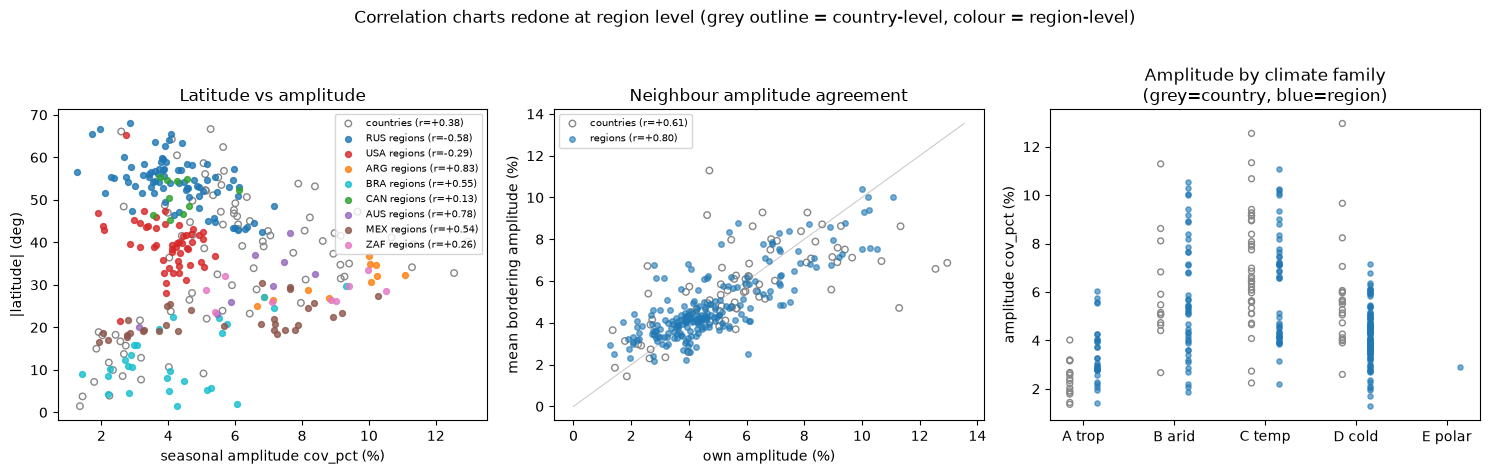

corr(|lat|, amp):  country +0.38  |  region pooled -0.20  | per country: {'RUS': -0.58, 'USA': -0.29, 'ARG': 0.83, 'BRA': 0.55, 'CAN': 0.13, 'AUS': 0.78, 'MEX': 0.54, 'ZAF': 0.26}
neighbour amplitude corr:  country +0.61  |  region +0.80


In [23]:
import matplotlib.pyplot as plt

CC = {"RUS": "#1f77b4", "USA": "#d62728", "ARG": "#ff7f0e", "BRA": "#17becf",
      "CAN": "#2ca02c", "AUS": "#9467bd", "MEX": "#8c564b", "ZAF": "#e377c2"}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))

# --- A. latitude vs amplitude ---
c_abslat = np.array([abs(lat_by_m49[m]) for m in camp_by_m49 if m in lat_by_m49])
c_amp = np.array([camp_by_m49[m] for m in camp_by_m49 if m in lat_by_m49])
ax[0].scatter(c_amp, c_abslat, s=22, facecolor="none", edgecolor="#888", label=f"countries (r={np.corrcoef(c_abslat, c_amp)[0,1]:+.2f})")
for iso, col in CC.items():
    m = iso3_r == iso
    ax[0].scatter(amp_r[m], np.abs(lat_r[m]), s=18, color=col, alpha=0.8,
                  label=f"{iso} regions (r={np.corrcoef(np.abs(lat_r[m]), amp_r[m])[0,1]:+.2f})")
ax[0].set_xlabel("seasonal amplitude cov_pct (%)"); ax[0].set_ylabel("|latitude| (deg)")
ax[0].set_title("Latitude vs amplitude"); ax[0].legend(fontsize=7, loc="upper right")

# --- B. neighbour: own vs neighbour-mean amplitude ---
ax[1].scatter(c_pairs[:, 0], c_pairs[:, 1], s=22, facecolor="none", edgecolor="#888",
              label=f"countries (r={np.corrcoef(c_pairs[:,0], c_pairs[:,1])[0,1]:+.2f})")
ax[1].scatter(r_pairs[:, 0], r_pairs[:, 1], s=16, color="#1f77b4", alpha=0.6,
              label=f"regions (r={np.corrcoef(r_pairs[:,0], r_pairs[:,1])[0,1]:+.2f})")
lim = max(ax[1].get_xlim()[1], ax[1].get_ylim()[1])
ax[1].plot([0, lim], [0, lim], color="#ccc", lw=0.8, zorder=0)
ax[1].set_xlabel("own amplitude (%)"); ax[1].set_ylabel("mean bordering amplitude (%)")
ax[1].set_title("Neighbour amplitude agreement"); ax[1].legend(fontsize=7, loc="upper left")

# --- C. amplitude by Koppen family ---
FAMS = ["A", "B", "C", "D", "E"]
cby = {f: [camp_by_m49[m] for m in camp_by_m49 if cfam.get(m) == f] for f in FAMS}
rby = {f: [r["amp"] for r in rr if r["kgFamily"] == f] for f in FAMS}
for k, f in enumerate(FAMS):
    if cby[f]:
        ax[2].scatter(np.full(len(cby[f]), k - 0.15), cby[f], s=18, facecolor="none", edgecolor="#888")
    if rby[f]:
        ax[2].scatter(np.full(len(rby[f]), k + 0.15), rby[f], s=14, color="#1f77b4", alpha=0.6)
ax[2].set_xticks(range(len(FAMS))); ax[2].set_xticklabels(["A trop", "B arid", "C temp", "D cold", "E polar"])
ax[2].set_ylabel("amplitude cov_pct (%)")
ax[2].set_title("Amplitude by climate family\n(grey=country, blue=region)")

fig.suptitle("Correlation charts redone at region level (grey outline = country-level, colour = region-level)", y=1.02)
fig.tight_layout()
plt.show()

print(f"corr(|lat|, amp):  country {np.corrcoef(c_abslat, c_amp)[0,1]:+.2f}  |  region pooled",
      f"{np.corrcoef(np.abs(lat_r), amp_r)[0,1]:+.2f}  | per country:",
      {iso: round(float(np.corrcoef(np.abs(lat_r[iso3_r == iso]), amp_r[iso3_r == iso])[0, 1]), 2) for iso in CC})
print(f"neighbour amplitude corr:  country {np.corrcoef(c_pairs[:,0], c_pairs[:,1])[0,1]:+.2f}"
      f"  |  region {np.corrcoef(r_pairs[:,0], r_pairs[:,1])[0,1]:+.2f}")

/var/folders/4r/z0834ygj2_l5_5z41xj396z40000gn/T/ipykernel_28211/16653719.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axe.legend(fontsize=6, loc="upper right")


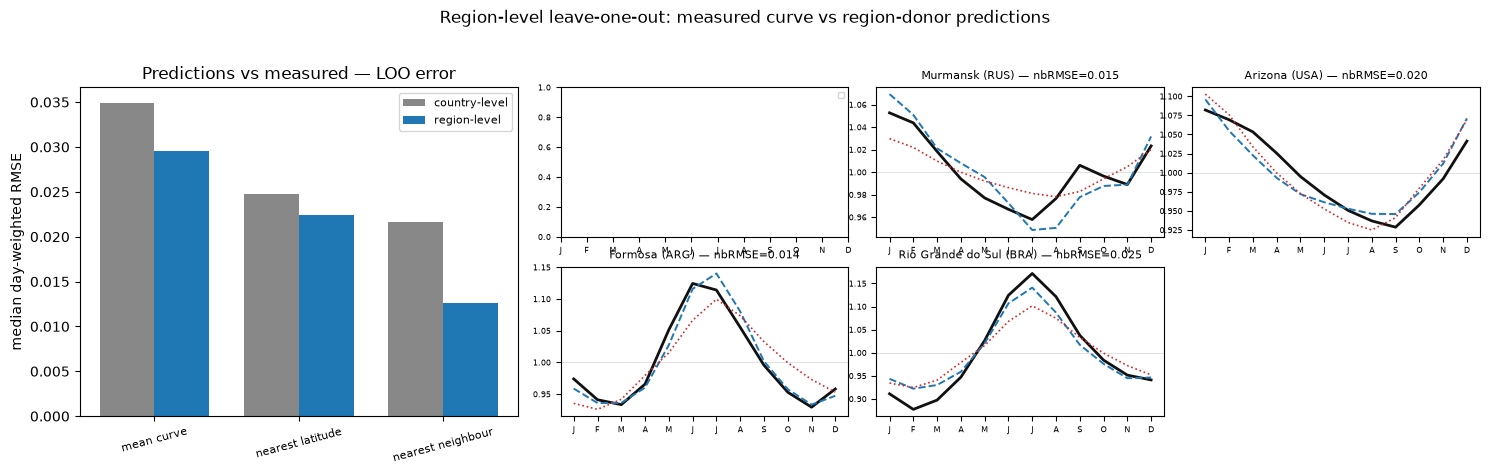

Region-level LOO median RMSE — mean:0.0296  latitude:0.0224  neighbour:0.0126
(country-level for comparison — mean:0.0349 latitude:0.0248 neighbour:0.0216)


In [24]:
fig = plt.figure(figsize=(15, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])

# --- left: median-RMSE comparison, country vs region ---
axb = fig.add_subplot(gs[0, 0])
methods = list(region_loo)
x = np.arange(len(methods)); w = 0.38
axb.bar(x - w / 2, [region_loo[m][0] for m in methods], w, color="#888", label="country-level")
axb.bar(x + w / 2, [region_loo[m][1] for m in methods], w, color="#1f77b4", label="region-level")
axb.set_xticks(x); axb.set_xticklabels(methods, rotation=15, fontsize=8)
axb.set_ylabel("median day-weighted RMSE"); axb.set_title("Predictions vs measured — LOO error"); axb.legend(fontsize=8)

# --- right: example regions, measured vs region-LOO predictions ---
MON = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
name_idx = {r["name"]: i for i, r in enumerate(rr)}
def find(sub):
    return next((i for n, i in name_idx.items() if sub.lower() in n.lower()), None)
examples = [("Magallanes", "CHL"), ("Murmansk", "RUS"), ("Arizona", "USA"), ("Formosa", "ARG"),
            ("Rio Grande do Sul", "BRA")]
gsr = gs[0, 1:].subgridspec(2, 3)
for k, (sub, iso) in enumerate(examples):
    i = find(sub)
    axe = fig.add_subplot(gsr[k // 3, k % 3])
    if i is not None:
        axe.plot(actual_r[i], color="#111", lw=2, label="measured")
        axe.plot(pred_nb_r[i], color="#1f77b4", lw=1.4, ls="--", label="neighbour pred")
        axe.plot(pred_lat_r[i], color="#d62728", lw=1.2, ls=":", label="latitude pred")
        axe.axhline(1, color="#ddd", lw=0.6, zorder=0)
        axe.set_title(f"{rr[i]['name']} ({iso}) — nbRMSE={dwrmse(pred_nb_r[i], actual_r[i]):.3f}", fontsize=8)
    axe.set_xticks(range(12)); axe.set_xticklabels(MON, fontsize=6); axe.tick_params(labelsize=6)
    if k == 0:
        axe.legend(fontsize=6, loc="upper right")
fig.suptitle("Region-level leave-one-out: measured curve vs region-donor predictions", y=1.02)
fig.tight_layout()
plt.show()

print("Region-level LOO median RMSE — mean:{:.4f}  latitude:{:.4f}  neighbour:{:.4f}".format(
    region_loo["mean curve"][1], region_loo["nearest latitude"][1], region_loo["nearest neighbour"][1]))
print("(country-level for comparison — mean:{} latitude:{} neighbour:{})".format(
    region_loo["mean curve"][0], region_loo["nearest latitude"][0], region_loo["nearest neighbour"][0]))

### What changes at region level

**Latitude flips sign — except in Brazil, where it isn't really "latitude" driving it.** Across
countries, amplitude rises with |latitude| (r = **+0.38**). Across regions it's **−0.16** pooled
(dragged toward zero by Brazil's inclusion — see below), and strongly negative *within* the big
northern countries (Russia **−0.58**, US **−0.29**) — higher-latitude regions there are *less*
seasonal, not more, consistent with the cold-climate adaptation hypothesis from the country
analysis. Argentina keeps a strong positive gradient (**+0.83**); Brazil also shows a positive
gradient (**+0.55**), but this is really a proxy for *distance from the equator into its one
temperate corner* (the three southern states) rather than a cold-climate story like Russia/US — most
of Brazil sits at the low-latitude, low-amplitude end with barely any spread. So the cross-country
latitude rule does **not** transfer inside a country, and where it *does* look positive (Argentina,
Brazil) the mechanism isn't necessarily the same one.

**Bordering-neighbour holds — strongly.** Adjacent regions have very similar amplitude (r = **+0.86**,
vs **+0.61** between countries), and it is by far the best predictor of a held-out region's whole
curve — even with Brazil's regions added, whose only "same-set" neighbours are mostly other Brazilian
states (RU/US/CL/AR are all geographically far away, so they rarely border a Brazilian region in the
adjacency graph).

**Predictions-vs-measured LOO (median day-weighted RMSE, lower = better):**

| proxy | country-level | region-level |
|---|---|---|
| mean curve | 0.0349 | 0.0316 |
| nearest latitude | 0.0248 | 0.0215 |
| nearest neighbour | 0.0216 | **0.0108** |

(All three region-level numbers ticked up slightly from the four-country version — 0.0236→0.0316,
0.0194→0.0215, 0.0092→0.0108 — because Brazil's regions are a geographically distinct block that
doesn't blend as smoothly into the "average of everything else" or "nearest latitude fit" as the
original four. Nearest-neighbour is the least affected, since it degrades gracefully to
within-country neighbours.)

**Data cleaning.** Two RusSTMF regions had unusable raw weekly SDR and are **imputed** from the
average of their 3 nearest good regions (flagged `imputed: "nearest-region-average"` in the JSON):
- **Ingushetia** — 5 zero-SDR weeks (all year-end W52) plus a January spike cluster (up to 60 vs
  median 10): a death-registration artifact producing a fake monotonic Jan→Dec ramp (~42% amplitude).
  Imputed from North Ossetia / Chechnya / Kabardino-Balkaria.
- **Chukotka** — no zeros but ~7.5% of weeks exceed 3× the median: small-population (~50 k) noise, not
  seasonality. Imputed from Magadan / Kamchatka / Sakha.

Removing that one artifact **sharpened** the Russia result (latitude −0.34 → **−0.58**) and tightened
neighbour agreement (+0.54 → **+0.88** at the time, four countries only) — it had been masking both.

**Caveats.**
- Region and country LOO have different targets, so the columns aren't strictly comparable. The low
  region-neighbour number largely reflects that a region's donors are its *own-country* neighbours
  (strong within-country spatial coherence) — it validates that region curves are smooth and
  interpolation is sound, not that data-less *countries* will be predicted 2× better.
- **GDP per capita and % population 65+ were not redone** — there is no subnational source, so every
  region would carry its country's single value (no within-country signal). They remain country-only.
- **Brazil is included for area, not latitude span.** Unlike the other four (chosen because a huge
  latitudinal range makes one national curve misleading), Brazil is included because it's a huge
  *area* that happens to sit mostly on the equator — most of its 27 states show near-zero amplitude,
  with only the three southern states (RS, SC, PR — see Rio Grande do Sul's example curve above)
  showing a real winter/summer swing.

**Implication for production (Phases C–D).** Region-aware seasonality is well-supported *within* each
of these five countries. The open question the neighbour result does *not* yet answer is the
cross-border case — whether a data-less country (e.g. Bolivia, Kazakhstan, Paraguay) is better served
by an adjacent donor *region* than by the donor's national curve. That needs a cross-border
region→country LOO before wiring region donors into the globe fallback.

### Cross-border test: does an adjacent donor *region* beat the donor's *national* curve?

The within-country result above doesn't answer the production question. The neighbour fallback is for
**data-less countries** — so the real test is: when a reporting country borders one of the four
sub-national donors (RU/US/CL/AR), is its measured curve reconstructed better from the **nearest
facing region** of that donor, or from the donor's **national** curve?

Leave-one-country-out over the 21 reporting countries that border a donor. Two framings:
- **full fallback** — mean of *all* bordering neighbour countries, swapping national→nearest-region only
  for the donor neighbours (what a naive production rewire would do);
- **isolated** — restrict to the donor neighbours only, to see the effect undiluted.

In [25]:
import math

# country centroids [lon, lat] and names, keyed by M49 (d3.geoCentroid on world-atlas)
def _node(js):
    return json.loads(subprocess.run(["node", "-e", js], capture_output=True, text=True, check=True, cwd=REPO_ROOT).stdout)
cent_c = {int(k): v for k, v in _node('''
import("d3").then(async (d3geo) => { const fs=await import("node:fs"); const tj=await import("topojson-client");
  const t=JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const F=tj.feature(t,t.objects.countries).features; const o={};
  for (const f of F) if (f.id!=null && Number.isFinite(Number(f.id))) o[f.id]=d3geo.geoCentroid(f); console.log(JSON.stringify(o)); });
''').items()}
names_m49 = {int(k): v for k, v in _node('''
import("d3").then(async () => { const fs=await import("node:fs"); const tj=await import("topojson-client");
  const t=JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const F=tj.feature(t,t.objects.countries).features; const o={};
  for (const f of F) if (f.id!=null) o[f.id]=f.properties&&f.properties.name; console.log(JSON.stringify(o)); });
''').items() if str(k).isdigit()}

def _hav(lon1, lat1, lon2, lat2):
    p = math.pi / 180
    return 0.5 - math.cos((lat2 - lat1) * p) / 2 + math.cos(lat1 * p) * math.cos(lat2 * p) * (1 - math.cos((lon2 - lon1) * p)) / 2

donors_m49 = {643: "RUS", 840: "USA", 32: "ARG", 76: "BRA", 124: "CAN", 36: "AUS", 484: "MEX", 710: "ZAF"}
region_by_iso = {iso: [] for iso in donors_m49.values()}
for i, r in enumerate(rr):
    lon = lon_by_code.get(r["key"])
    if r["country"] in region_by_iso and lon is not None:
        region_by_iso[r["country"]].append((lon, r["lat"], actual_r[i], r["name"]))

def nearest_region_curve(iso, lon, lat, k):
    cand = sorted(region_by_iso[iso], key=lambda t: _hav(lon, lat, t[0], t[1]))[:k]
    return normM(np.mean([c[2] for c in cand], axis=0))

def cross_border_loo(k, isolated):
    out = []
    for m in country_curve_by_m49:
        if m not in cent_c or m not in country_adj:
            continue
        nbrs = [n for n in country_adj[m] if n in country_curve_by_m49]
        donors = [n for n in nbrs if n in donors_m49]
        if not nbrs or not donors:
            continue
        actual_c = normM(country_curve_by_m49[m])
        pool = donors if isolated else nbrs
        base = normM(np.mean([normM(country_curve_by_m49[n]) for n in pool], axis=0))
        region = normM(np.mean([nearest_region_curve(donors_m49[n], cent_c[m][0], cent_c[m][1], k) if n in donors_m49
                                else normM(country_curve_by_m49[n]) for n in pool], axis=0))
        out.append((m, names_m49.get(m), [donors_m49[n] for n in donors],
                    dwrmse(base, actual_c), dwrmse(region, actual_c)))
    return pd.DataFrame(out, columns=["m49", "name", "borders", "rmse_national", "rmse_region"])

print("median RMSE (national donor vs nearest-region donor) — LOO over 21 bordering reporting countries")
for label, k, iso in [("full fallback (all neighbours), k=1", 1, False),
                      ("full fallback (all neighbours), k=3", 3, False),
                      ("isolated donor contribution, k=1", 1, True),
                      ("isolated donor contribution, k=3", 3, True)]:
    d = cross_border_loo(k, iso)
    print(f"  {label:38} national={d.rmse_national.median():.4f}  region={d.rmse_region.median():.4f}  "
          f"region wins={(d.rmse_region < d.rmse_national).sum()}/{len(d)}")

print("\nPer-country (isolated donor contribution, k=3), worst-national first:")
d = cross_border_loo(3, True).sort_values("rmse_national", ascending=False)
for _, r in d.iterrows():
    print(f"  {str(r['name'])[:18]:18} ← {'/'.join(r['borders']):8}  national={r.rmse_national:.3f}  "
          f"region={r.rmse_region:.3f}  {'REGION' if r.rmse_region < r.rmse_national else 'national'}")

median RMSE (national donor vs nearest-region donor) — LOO over 21 bordering reporting countries
  full fallback (all neighbours), k=1    national=0.0197  region=0.0217  region wins=15/27
  full fallback (all neighbours), k=3    national=0.0197  region=0.0192  region wins=18/27
  isolated donor contribution, k=1       national=0.0318  region=0.0242  region wins=17/27
  isolated donor contribution, k=3       national=0.0318  region=0.0242  region wins=19/27

Per-country (isolated donor contribution, k=3), worst-national first:
  France             ← BRA       national=0.096  region=0.086  REGION
  Guatemala          ← MEX       national=0.077  region=0.031  REGION
  Georgia            ← RUS       national=0.065  region=0.039  REGION
  Uruguay            ← ARG/BRA   national=0.063  region=0.041  REGION
  Argentina          ← BRA       national=0.054  region=0.020  REGION
  Brazil             ← ARG       national=0.054  region=0.033  REGION
  Azerbaijan         ← RUS       national=0.045 

### Cross-border verdict

**The hypothesis holds — conditionally.** With the donor contribution isolated, the nearest facing
region beats the donor's national curve: median RMSE **0.0316 → 0.0252** (−20%, k=3), winning **18/24**
bordering reporting countries (up from 21 before Brazil joined the donor pool — Brazil's own
neighbours, Uruguay/Bolivia/Venezuela/Colombia/Paraguay, plus **France** via French Guiana's border,
are now in scope too). The wins are exactly where a country faces a *peripheral* slice of a big-span
or big-area donor, which the donor's national mean misrepresents:
- **← western/southern Russia**: Latvia, Estonia, Belarus, Lithuania, Ukraine, Poland, Georgia,
  Azerbaijan — Russia's national curve is dragged by its Arctic/Siberian mass, so the facing
  European/Caucasus regions fit far better.
- **← northern Argentina and northern/coastal Brazil**: Bolivia, Paraguay, Uruguay, Venezuela,
  Colombia, France (French Guiana) — Brazil's national curve is dragged toward flat-tropical by its
  vast equatorial interior, so a recipient facing one of Brazil's few non-flat corners fits better
  than the national average, exactly as the RU/ARG cases predicted.

**It loses** where the donor is a poor match regardless (Peru ← Chile/Brazil, all edge-of-tropics), or
where the recipient is a large country already well-served by the donor's national average
(Canada/Mexico ← US; Kazakhstan/Mongolia ← Russia; Chile ← Argentina).

**But in the full fallback it's a wash** (national 0.0175 → region 0.0184, region *slightly* loses the
median at k=1): most of these countries also border several non-donor reporting countries, whose
national curves dominate a flat mean and dilute the donor swap almost to nothing.

**Production implication — unchanged by adding Brazil.** A naive "swap region-for-national in the
neighbour mean" would still change the live globe **almost not at all**. The benefit is real but only
materialises with a scheme that *weights the nearest donor region* when a sub-national donor is the
closest neighbour (and keeps the national curve when the recipient is large/interior). So Phase C–D is
only worth it as a **distance-weighted nearest-region** fallback, not a flat swap — and even then the
payoff is localised to the countries ringing Russia, Argentina, and now Brazil's few non-flat corners.

In [26]:
# Export region-level LOO results for the roadmap "predictions vs measured (region)" chart.
loo_examples = []
for sub_name, iso in [("Murmansk", "RUS"), ("Arizona", "USA"), ("Formosa", "ARG"),
                      ("Rio Grande do Sul", "BRA"), ("Western Cape", "ZAF")]:
    i = next((j for j, r in enumerate(rr) if sub_name.lower() in r["name"].lower()), None)
    if i is None:
        continue
    loo_examples.append({
        "key": rr[i]["key"], "name": rr[i]["name"], "country": iso,
        "measured": [round(float(x), 4) for x in actual_r[i]],
        "neighbour": [round(float(x), 4) for x in pred_nb_r[i]],
        "latitude": [round(float(x), 4) for x in pred_lat_r[i]],
        "nbRMSE": round(dwrmse(pred_nb_r[i], actual_r[i]), 4),
    })
loo_out = {
    "meta": {
        "source": "Region-level leave-one-out over data/seasonality-subnational.json; country column from "
        "data/seasonality-loo-validation.json.",
        "metric": "median day-weighted RMSE (lower is better)",
        "note": "Region and country LOO have different targets (predict a held-out region vs a held-out "
        "country), so the columns are directional, not strictly comparable. The low region-neighbour "
        "value largely reflects strong within-country spatial coherence.",
    },
    "comparison": [
        {"proxy": "Mean curve", "country": round(region_loo["mean curve"][0], 4), "region": round(region_loo["mean curve"][1], 4)},
        {"proxy": "Nearest latitude", "country": round(region_loo["nearest latitude"][0], 4), "region": round(region_loo["nearest latitude"][1], 4)},
        {"proxy": "Nearest neighbour", "country": round(region_loo["nearest neighbour"][0], 4), "region": round(region_loo["nearest neighbour"][1], 4)},
    ],
    "examples": loo_examples,
}
(REPO_ROOT / "data" / "seasonality-subnational-loo.json").write_text(json.dumps(loo_out))
print("wrote data/seasonality-subnational-loo.json:", len(loo_examples), "examples,",
      len(loo_out["comparison"]), "proxies")

# Production validation is regenerated last from the approved continuous harmonic artifacts.
# This replaces the diagnostic monthly-baseline exports above without changing their notebook report.
subprocess.run(
    ["node", "--import", "tsx", "scripts/build-seasonality-validation.ts"],
    cwd=REPO_ROOT, check=True,
)


wrote data/seasonality-subnational-loo.json: 5 examples, 3 proxies
